<a href="https://colab.research.google.com/github/mardocheeogecime-gif/Rede_Colabora-o_Acad-mica_ECI_UFMG/blob/main/JASIST_Journal_of_the_association_for_informationST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [12]:
import pandas as pd
from pathlib import Path

ROOT = Path("/content/gdrive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003")

files = {
    "PAIR_FRAME": ROOT / "05C_target_specific_reference_benchmark/tables/Table_05C_01_pair_benchmark_frame.csv",
    "TARGET_SPLIT": ROOT / "05C_target_specific_reference_benchmark/tables/Table_05C_02_target_split.csv",
    "FEATURE_FRAME": ROOT / "06D_incumbent_aware_multievidence/tables/Table_06D_01_feature_frame.csv",
    "MLP_TEST": ROOT / "09B_learned_baseline_heterogeneity/tables/Table_09B_01_learned_baseline_test.csv",
    "MLP_MODEL": ROOT / "09B_learned_baseline_heterogeneity/tables/Table_09B_04_selected_learned_model.csv",
}

for name, path in files.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("Existe:", path.exists())
    print("Path:", path)

    if path.exists():
        df = pd.read_csv(path)
        print("Shape:", df.shape)
        print("\nColunas:")
        for i, c in enumerate(df.columns, 1):
            print(f"{i:02d}. {c}")

        print("\nPrimeiras 3 linhas:")
        print(df.head(3).to_string(index=False))


PAIR_FRAME
Existe: True
Path: /content/gdrive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/05C_target_specific_reference_benchmark/tables/Table_05C_01_pair_benchmark_frame.csv
Shape: (1295, 48)

Colunas:
01. target_key
02. candidate_openalex_id
03. target_name
04. target_name_normalized
05. source_institutions
06. incumbent_openalex_ids
07. search_rank
08. candidate_display_name
09. candidate_alt_names
10. candidate_orcid
11. candidate_works_count
12. candidate_cited_by_count
13. candidate_institutions
14. candidate_raw_api_updated_date
15. candidate_origin
16. _origin_rank
17. candidate_origins
18. best_search_rank
19. best_sequence_similarity
20. best_token_jaccard
21. surname_match_any
22. first_initial_match_any
23. initials_match_any
24. affiliation_token_overlap
25. is_incumbent_candidate
26. n_candidates_augmented
27. candidates_seq_ge_080
28. candidates_seq_ge_090
29. candidates_seq_eq_100
30. candidates_same_surname
31. candidate_sampling_stratum
32. candidate_id

In [13]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J1
Identity Uncertainty, Probability Calibration, and Selective Abstention

Input is read-only from the frozen JOI run.
All outputs are written to an independent JASIST run directory.

This script:
1) loads the frozen 825-pair feature frame;
2) verifies the frozen 106/35/35 target-disjoint split;
3) reproduces the selected 14-feature MLP configuration;
4) selects probability calibration on VALIDATION ONLY;
5) evaluates calibration on the untouched TEST set;
6) quantifies pair- and target-level identity uncertainty;
7) estimates coverage-risk tradeoffs under selective abstention;
8) exports manuscript-ready tables and figures.

IMPORTANT:
- No new split is created.
- No threshold or calibration method is selected on the test set.
- JOI files are never modified.
"""

from pathlib import Path
import json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss, log_loss,
    roc_auc_score, average_precision_score
)

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION
# ============================================================
SEED = 20261005

JOI_ROOT = Path(
    "/content/gdrive/MyDrive/tese_doutoral/runs/"
    "joi_entity_resolution_20261003"
)

INPUT = (
    JOI_ROOT /
    "06D_incumbent_aware_multievidence/tables/"
    "Table_06D_01_feature_frame.csv"
)

MODEL_SPEC = (
    JOI_ROOT /
    "09B_learned_baseline_heterogeneity/tables/"
    "Table_09B_04_selected_learned_model.csv"
)

JOI_TEST_METRICS = (
    JOI_ROOT /
    "09B_learned_baseline_heterogeneity/tables/"
    "Table_09B_01_learned_baseline_test.csv"
)

OUT = Path(
    "/content/gdrive/MyDrive/tese_doutoral/runs/"
    "jasist_identity_uncertainty_20261005/"
    "01_identity_uncertainty_calibration"
)

TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "f_exact_any",
    "f_aini",
    "f_name_sim",
    "f_aff",
    "f_external_work_count",
    "f_coauthor_id_overlap",
    "f_coauthor_name_overlap",
    "f_coauthor_id_recall",
    "f_coauthor_name_recall",
    "is_incumbent",
    "exact_name_count_target",
    "is_unique_top_f_coauthor_id_overlap",
    "is_unique_top_f_aff",
    "is_unique_top_f_name_sim",
]

FROZEN_ARCH = (16,)
FROZEN_ALPHA = 0.0001
FROZEN_THRESHOLD = 0.54

print("=" * 88)
print("JASIST — PART J1")
print("IDENTITY UNCERTAINTY, CALIBRATION, AND SELECTIVE ABSTENTION")
print("=" * 88)
print("Frozen JOI input:", INPUT)
print("Independent JASIST output:", OUT)

# ============================================================
# UTILITIES
# ============================================================
def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def binary_metrics(y, p, threshold):
    y = np.asarray(y, dtype=int)
    pred = (np.asarray(p, dtype=float) >= threshold).astype(int)
    return {
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "MCC": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else np.nan,
        "FPR": (
            ((pred == 1) & (y == 0)).sum() / (y == 0).sum()
            if (y == 0).sum() else np.nan
        ),
        "FNR": (
            ((pred == 0) & (y == 1)).sum() / (y == 1).sum()
            if (y == 1).sum() else np.nan
        ),
    }

def binary_entropy(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def ece(y, p, bins=10):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    edges = np.linspace(0, 1, bins + 1)
    b = np.digitize(p, edges[1:-1], right=True)

    rows = []
    total = 0.0

    for i in range(bins):
        mask = b == i
        if mask.sum() == 0:
            rows.append({
                "bin": i,
                "lower": edges[i],
                "upper": edges[i+1],
                "n": 0,
                "mean_probability": np.nan,
                "observed_rate": np.nan,
                "absolute_gap": np.nan,
            })
            continue

        mp = float(p[mask].mean())
        obs = float(y[mask].mean())
        gap = abs(mp - obs)
        total += mask.mean() * gap

        rows.append({
            "bin": i,
            "lower": edges[i],
            "upper": edges[i+1],
            "n": int(mask.sum()),
            "mean_probability": mp,
            "observed_rate": obs,
            "absolute_gap": gap,
        })

    return float(total), pd.DataFrame(rows)

def calibration_slope_intercept(y, p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    x = np.log(p / (1-p)).reshape(-1, 1)

    mod = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=5000,
        random_state=SEED
    )
    mod.fit(x, np.asarray(y, dtype=int))

    return float(mod.intercept_[0]), float(mod.coef_[0][0])

# ============================================================
# 1. LOAD AND VERIFY FROZEN INPUT
# ============================================================
print("\n[1/8] Loading and validating frozen JOI feature frame...")

if not INPUT.exists():
    raise FileNotFoundError(INPUT)

df = pd.read_csv(INPUT)

required = {
    "target_key", "candidate_openalex_id", "target_name",
    "candidate_display_name", "candidate_orcid", "y_ref",
    "split", "sampling_weight"
}.union(FEATURES)

missing = sorted(required - set(df.columns))
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Input SHA256:", sha256_file(INPUT))

# Strictly preserve frozen binary reference set
df = df[df["y_ref"].isin([0, 1])].copy()
df["y_ref"] = df["y_ref"].astype(int)
df["split"] = df["split"].astype(str).str.strip().str.lower()

for f in FEATURES:
    df[f] = pd.to_numeric(df[f], errors="coerce").fillna(0.0)

split_target_counts = (
    df.groupby("split")["target_key"].nunique().reindex(
        ["train", "validation", "test"]
    )
)

split_pair_counts = (
    df["split"].value_counts().reindex(
        ["train", "validation", "test"]
    )
)

print("\nFrozen partition:")
for s in ["train", "validation", "test"]:
    print(
        f"  {s:10s}: "
        f"{int(split_target_counts[s])} targets | "
        f"{int(split_pair_counts[s])} pairs"
    )

EXPECTED_TARGETS = {
    "train": 106,
    "validation": 35,
    "test": 35
}

for s, expected in EXPECTED_TARGETS.items():
    observed = int(split_target_counts[s])
    if observed != expected:
        raise RuntimeError(
            f"Frozen split mismatch for {s}: expected {expected}, got {observed}"
        )

# target leakage check
target_sets = {
    s: set(df.loc[df["split"].eq(s), "target_key"])
    for s in ["train", "validation", "test"]
}

for a, b in [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test")
]:
    overlap = target_sets[a] & target_sets[b]
    if overlap:
        raise RuntimeError(
            f"Target leakage between {a} and {b}: {len(overlap)} targets"
        )

train = df[df["split"].eq("train")].copy()
val = df[df["split"].eq("validation")].copy()
test = df[df["split"].eq("test")].copy()

print("\nTest set:")
print("  pairs:", len(test))
print("  positives:", int(test["y_ref"].sum()))
print("  negatives:", int((1-test["y_ref"]).sum()))

# ============================================================
# 2. VERIFY FROZEN MODEL SPECIFICATION
# ============================================================
print("\n[2/8] Verifying frozen learned-model specification...")

spec = pd.read_csv(MODEL_SPEC)
print(spec.to_string(index=False))

if len(spec) != 1:
    raise RuntimeError("Selected learned model specification should contain one row.")

row = spec.iloc[0]

if int(row["n_features"]) != 14:
    raise RuntimeError("Frozen model does not report 14 features.")

if abs(float(row["alpha"]) - FROZEN_ALPHA) > 1e-12:
    raise RuntimeError("Frozen alpha differs from expected value.")

if abs(float(row["threshold"]) - FROZEN_THRESHOLD) > 1e-12:
    raise RuntimeError("Frozen threshold differs from expected value.")

# ============================================================
# 3. FIT FROZEN MLP CONFIGURATION
# ============================================================
print("\n[3/8] Fitting frozen 14-feature MLP configuration...")

# The split and hyperparameters remain frozen.
# Class balancing is confined to TRAIN only.
rng = np.random.default_rng(SEED)

pos = train[train["y_ref"].eq(1)]
neg = train[train["y_ref"].eq(0)]

if len(pos) < len(neg):
    sampled = rng.choice(
        pos.index.to_numpy(),
        size=len(neg)-len(pos),
        replace=True
    )
    fit_train = pd.concat(
        [train, train.loc[sampled]],
        ignore_index=True
    )
elif len(neg) < len(pos):
    sampled = rng.choice(
        neg.index.to_numpy(),
        size=len(pos)-len(neg),
        replace=True
    )
    fit_train = pd.concat(
        [train, train.loc[sampled]],
        ignore_index=True
    )
else:
    fit_train = train.copy()

print(
    "Training pairs before balancing:",
    len(train),
    "| positives:", int(train["y_ref"].sum()),
    "| negatives:", int((1-train["y_ref"]).sum())
)
print(
    "Training pairs after balancing:",
    len(fit_train),
    "| positives:", int(fit_train["y_ref"].sum()),
    "| negatives:", int((1-fit_train["y_ref"]).sum())
)

mlp = Pipeline([
    ("scale", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=FROZEN_ARCH,
        alpha=FROZEN_ALPHA,
        random_state=SEED,
        max_iter=5000,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001
    ))
])

mlp.fit(
    fit_train[FEATURES],
    fit_train["y_ref"]
)

for part in [train, val, test]:
    df.loc[part.index, "p_raw"] = mlp.predict_proba(
        part[FEATURES]
    )[:, 1]

raw_test_metrics = binary_metrics(
    test["y_ref"],
    df.loc[test.index, "p_raw"],
    FROZEN_THRESHOLD
)

print("\nRaw held-out performance at frozen threshold 0.54:")
for k, v in raw_test_metrics.items():
    print(f"  {k:20s}: {v:.6f}")

# Compare descriptively with stored JOI result.
stored = pd.read_csv(JOI_TEST_METRICS)
stored_mlp = stored[
    stored["method"].astype(str).str.contains("MLP", case=False, na=False)
]

if len(stored_mlp):
    stored_mcc = float(stored_mlp.iloc[0]["MCC"])
    observed_mcc = float(raw_test_metrics["MCC"])
    print("\nStored JOI MLP MCC:", round(stored_mcc, 6))
    print("Current refit MCC   :", round(observed_mcc, 6))
    print("Absolute difference :", round(abs(stored_mcc-observed_mcc), 6))

# ============================================================
# 4. VALIDATION-ONLY PROBABILITY CALIBRATION
# ============================================================
print("\n[4/8] Selecting probability calibration on validation only...")

eps = 1e-6

p_val_raw = np.clip(
    df.loc[val.index, "p_raw"].to_numpy(float),
    eps, 1-eps
)
y_val = val["y_ref"].to_numpy(int)

# Platt scaling
x_val_logit = np.log(
    p_val_raw / (1-p_val_raw)
).reshape(-1, 1)

platt = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=5000,
    random_state=SEED
)
platt.fit(x_val_logit, y_val)

p_val_platt = platt.predict_proba(
    x_val_logit
)[:, 1]

# Isotonic
isotonic = IsotonicRegression(
    out_of_bounds="clip"
)
isotonic.fit(p_val_raw, y_val)

p_val_iso = isotonic.predict(p_val_raw)

validation_selection = pd.DataFrame([
    {
        "calibration": "raw",
        "brier": brier_score_loss(y_val, p_val_raw),
        "log_loss": log_loss(y_val, p_val_raw, labels=[0,1])
    },
    {
        "calibration": "platt",
        "brier": brier_score_loss(y_val, p_val_platt),
        "log_loss": log_loss(y_val, p_val_platt, labels=[0,1])
    },
    {
        "calibration": "isotonic",
        "brier": brier_score_loss(y_val, p_val_iso),
        "log_loss": log_loss(y_val, p_val_iso, labels=[0,1])
    }
]).sort_values(
    ["brier", "log_loss"],
    ascending=True
)

selected_calibration = validation_selection.iloc[0]["calibration"]

print(validation_selection.to_string(index=False))
print("\nSelected on validation only:", selected_calibration)

validation_selection.to_csv(
    TABLES / "Table_J1_01_validation_calibration_selection.csv",
    index=False
)

# ============================================================
# 5. HELD-OUT TEST CALIBRATION
# ============================================================
print("\n[5/8] Evaluating calibration on untouched held-out test set...")

p_test_raw = np.clip(
    df.loc[test.index, "p_raw"].to_numpy(float),
    eps, 1-eps
)
y_test = test["y_ref"].to_numpy(int)

x_test_logit = np.log(
    p_test_raw / (1-p_test_raw)
).reshape(-1, 1)

p_test_platt = platt.predict_proba(
    x_test_logit
)[:, 1]

p_test_iso = isotonic.predict(
    p_test_raw
)

probabilities = {
    "raw": p_test_raw,
    "platt": p_test_platt,
    "isotonic": p_test_iso
}

test_calibration_rows = []
reliability_tables = []

for method, p in probabilities.items():
    ece_value, rel = ece(y_test, p, bins=10)
    ci, cs = calibration_slope_intercept(y_test, p)

    test_calibration_rows.append({
        "calibration": method,
        "n_pairs": len(y_test),
        "n_targets": test["target_key"].nunique(),
        "brier": brier_score_loss(y_test, p),
        "log_loss": log_loss(y_test, p, labels=[0,1]),
        "ECE_10bin": ece_value,
        "calibration_intercept": ci,
        "calibration_slope": cs,
        "ROC_AUC": roc_auc_score(y_test, p),
        "average_precision": average_precision_score(y_test, p),
    })

    rel["calibration"] = method
    reliability_tables.append(rel)

test_calibration = pd.DataFrame(test_calibration_rows)

print(test_calibration.to_string(index=False))

test_calibration.to_csv(
    TABLES / "Table_J1_02_heldout_calibration_metrics.csv",
    index=False
)

reliability = pd.concat(
    reliability_tables,
    ignore_index=True
)

reliability.to_csv(
    TABLES / "Table_J1_03_reliability_bins.csv",
    index=False
)

# selected probabilities
if selected_calibration == "raw":
    p_selected = p_test_raw
elif selected_calibration == "platt":
    p_selected = p_test_platt
else:
    p_selected = p_test_iso

df.loc[test.index, "p_platt"] = p_test_platt
df.loc[test.index, "p_isotonic"] = p_test_iso
df.loc[test.index, "p_selected"] = p_selected

# reliability diagram
fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.plot([0,1], [0,1], "--", linewidth=1.2, label="Perfect calibration")

for method, p in probabilities.items():
    ev, rel = ece(y_test, p, bins=10)
    rel = rel[rel["n"] > 0]
    ax.plot(
        rel["mean_probability"],
        rel["observed_rate"],
        marker="o",
        label=f"{method.capitalize()} (ECE={ev:.3f})"
    )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed match rate")
ax.set_title("Held-out probability calibration")
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGURES / "Figure_J1_01_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J1_01_reliability_diagram.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# ============================================================
# 6. IDENTITY UNCERTAINTY
# ============================================================
print("\n[6/8] Quantifying pair- and target-level identity uncertainty...")

test_idx = test.index

df.loc[test_idx, "pair_entropy_bits"] = binary_entropy(
    df.loc[test_idx, "p_selected"]
)

df.loc[test_idx, "decision_confidence"] = (
    np.abs(
        df.loc[test_idx, "p_selected"] - 0.5
    ) * 2
)

df.loc[test_idx, "exact_name_ambiguous"] = (
    pd.to_numeric(
        df.loc[test_idx, "exact_name_count_target"],
        errors="coerce"
    ).fillna(0) >= 2
)

target_rows = []

for target_key, g in df.loc[test_idx].groupby("target_key"):
    g = g.sort_values(
        "p_selected",
        ascending=False
    )

    probs = g["p_selected"].to_numpy(float)

    top1 = float(probs[0])
    top2 = float(probs[1]) if len(probs) > 1 else 0.0

    # candidate-relative normalized entropy
    q = np.clip(probs, 1e-12, None)
    q = q / q.sum()

    H = float(
        -(q * np.log2(q)).sum()
    )

    H_norm = (
        H / np.log2(len(q))
        if len(q) > 1 else 0.0
    )

    target_rows.append({
        "target_key": target_key,
        "target_name": g.iloc[0]["target_name"],
        "n_candidates": len(g),
        "n_reference_positive": int(g["y_ref"].sum()),
        "top1_probability": top1,
        "top2_probability": top2,
        "top1_top2_margin": top1 - top2,
        "candidate_entropy_bits": H,
        "candidate_entropy_normalized": H_norm,
        "mean_pair_entropy_bits": float(g["pair_entropy_bits"].mean()),
        "max_pair_entropy_bits": float(g["pair_entropy_bits"].max()),
        "exact_name_ambiguous": bool(g["exact_name_ambiguous"].max()),
        "has_orcid_candidate": bool(g["candidate_orcid"].notna().any()),
        "max_affiliation_signal": float(g["f_aff"].max()),
        "max_coauthor_id_overlap": float(g["f_coauthor_id_overlap"].max()),
        "incumbent_present": bool(g["is_incumbent"].max()),
    })

target_uncertainty = pd.DataFrame(target_rows)

target_uncertainty.to_csv(
    TABLES / "Table_J1_04_target_identity_uncertainty.csv",
    index=False
)

ambiguity_rows = []

for label, mask in [
    (
        "EXACT_NAME_AMBIGUOUS",
        target_uncertainty["exact_name_ambiguous"]
    ),
    (
        "LOWER_AMBIGUITY",
        ~target_uncertainty["exact_name_ambiguous"]
    )
]:
    sub = target_uncertainty[mask]

    ambiguity_rows.append({
        "stratum": label,
        "targets": len(sub),
        "mean_normalized_candidate_entropy":
            sub["candidate_entropy_normalized"].mean(),
        "median_top1_top2_margin":
            sub["top1_top2_margin"].median(),
        "mean_max_pair_entropy_bits":
            sub["max_pair_entropy_bits"].mean(),
        "mean_n_candidates":
            sub["n_candidates"].mean()
    })

ambiguity_summary = pd.DataFrame(
    ambiguity_rows
)

print("\nUncertainty by name-ambiguity stratum:")
print(ambiguity_summary.to_string(index=False))

ambiguity_summary.to_csv(
    TABLES / "Table_J1_05_uncertainty_by_name_ambiguity.csv",
    index=False
)

# target uncertainty figure
fig, ax = plt.subplots(figsize=(6.6, 5.2))

ax.scatter(
    target_uncertainty["top1_top2_margin"],
    target_uncertainty["candidate_entropy_normalized"],
    alpha=0.75
)

ax.set_xlabel("Top-1 minus top-2 candidate probability")
ax.set_ylabel("Normalized candidate entropy")
ax.set_title("Target-level bibliographic identity uncertainty")

fig.tight_layout()

fig.savefig(
    FIGURES / "Figure_J1_02_target_identity_uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J1_02_target_identity_uncertainty.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# ============================================================
# 7. SELECTIVE ABSTENTION: COVERAGE × RISK
# ============================================================
print("\n[7/8] Estimating selective-abstention coverage-risk tradeoff...")

g = df.loc[test_idx].copy()

coverage_rows = []

for min_conf in np.linspace(0, 0.99, 100):
    kept = g[
        g["decision_confidence"] >= min_conf
    ].copy()

    if len(kept) == 0:
        continue

    pred = (
        kept["p_selected"] >= 0.5
    ).astype(int)

    y = kept["y_ref"].to_numpy(int)

    error_rate = float(
        (pred.to_numpy() != y).mean()
    )

    coverage_rows.append({
        "min_confidence": min_conf,
        "coverage_pairs": len(kept) / len(g),
        "retained_pairs": len(kept),
        "abstained_pairs": len(g) - len(kept),
        "error_rate_among_decided": error_rate,
        "precision": precision_score(
            y, pred, zero_division=0
        ),
        "recall": recall_score(
            y, pred, zero_division=0
        ),
        "F1": f1_score(
            y, pred, zero_division=0
        ),
        "MCC": (
            matthews_corrcoef(y, pred)
            if len(np.unique(pred)) > 1
            else np.nan
        )
    })

coverage_risk = pd.DataFrame(
    coverage_rows
)

coverage_risk.to_csv(
    TABLES / "Table_J1_06_selective_coverage_risk_curve.csv",
    index=False
)

selected_operating_points = []

for requested_coverage in [
    1.00, 0.95, 0.90, 0.80, 0.70, 0.50
]:
    ix = (
        coverage_risk["coverage_pairs"] -
        requested_coverage
    ).abs().idxmin()

    r = coverage_risk.loc[ix].to_dict()
    r["requested_coverage"] = requested_coverage
    selected_operating_points.append(r)

selected_operating_points = pd.DataFrame(
    selected_operating_points
)

print("\nSelected coverage-risk operating points:")
print(selected_operating_points.to_string(index=False))

selected_operating_points.to_csv(
    TABLES / "Table_J1_07_selected_coverage_risk_points.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(6.6, 5.2))

ax.plot(
    coverage_risk["coverage_pairs"],
    coverage_risk["error_rate_among_decided"],
    marker="o",
    markersize=3
)

ax.set_xlabel("Coverage: fraction of candidate pairs automatically decided")
ax.set_ylabel("Error rate among decided pairs")
ax.set_title("Selective entity resolution: coverage-risk tradeoff")

fig.tight_layout()

fig.savefig(
    FIGURES / "Figure_J1_03_coverage_risk_curve.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J1_03_coverage_risk_curve.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# full test-level output
test_export_cols = [
    "target_key",
    "candidate_openalex_id",
    "target_name",
    "candidate_display_name",
    "candidate_orcid",
    "y_ref",
    "sampling_weight",
    "p_raw",
    "p_platt",
    "p_isotonic",
    "p_selected",
    "pair_entropy_bits",
    "decision_confidence",
    "exact_name_ambiguous",
] + FEATURES

df.loc[test_idx, test_export_cols].to_csv(
    TABLES / "Table_J1_08_test_pair_uncertainty.csv",
    index=False
)

# ============================================================
# 8. MANIFEST AND SCIENTIFIC SUMMARY
# ============================================================
print("\n[8/8] Writing manifest and scientific summary...")

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J1",
    "seed": SEED,
    "source_run": str(JOI_ROOT),
    "source_input": str(INPUT),
    "source_input_sha256": sha256_file(INPUT),
    "output_run": str(OUT),
    "frozen_partition": {
        "train_targets": 106,
        "validation_targets": 35,
        "test_targets": 35,
        "test_pairs": int(len(test)),
        "test_positive_pairs": int(test["y_ref"].sum()),
        "test_negative_pairs": int((1-test["y_ref"]).sum())
    },
    "frozen_model": {
        "architecture": [16],
        "alpha": 0.0001,
        "threshold": 0.54,
        "n_features": 14,
        "features": FEATURES
    },
    "calibration_selection_rule":
        "minimum validation Brier score; test never used for selection",
    "selected_calibration": selected_calibration,
    "raw_test_metrics": {
        k: None if pd.isna(v) else float(v)
        for k, v in raw_test_metrics.items()
    }
}

with open(
    ARTIFACTS / "J1_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\n" + "=" * 88)
print("PART J1 COMPLETE")
print("=" * 88)
print("Selected calibration:", selected_calibration)
print("Output directory:", OUT)

print("\nTABLES")
for p in sorted(TABLES.glob("*.csv")):
    print(" -", p.name)

print("\nFIGURES")
for p in sorted(FIGURES.glob("*")):
    print(" -", p.name)

print("\nARTIFACTS")
for p in sorted(ARTIFACTS.glob("*")):
    print(" -", p.name)

print("\nRETURN TO CHAT:")
print("1. Console output from [3/8] through PART J1 COMPLETE")
print("2. Table_J1_02_heldout_calibration_metrics.csv")
print("3. Table_J1_05_uncertainty_by_name_ambiguity.csv")
print("4. Table_J1_07_selected_coverage_risk_points.csv")
print("5. J1_manifest.json")
print("=" * 88)


JASIST — PART J1
IDENTITY UNCERTAINTY, CALIBRATION, AND SELECTIVE ABSTENTION
Frozen JOI input: /content/gdrive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/06D_incumbent_aware_multievidence/tables/Table_06D_01_feature_frame.csv
Independent JASIST output: /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/01_identity_uncertainty_calibration

[1/8] Loading and validating frozen JOI feature frame...
Rows: 825
Columns: 54
Input SHA256: 6dccdf7b38ea0885dd3446eabf78928644deef115bfad88cc4007771bf304fe1

Frozen partition:
  train     : 106 targets | 588 pairs
  validation: 35 targets | 102 pairs
  test      : 35 targets | 135 pairs

Test set:
  pairs: 135
  positives: 38
  negatives: 97

[2/8] Verifying frozen learned-model specification...
                                                       selection_rule architecture  alpha  threshold  n_features                                                                                                       

In [14]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J2
Target-Level Identity-Set Uncertainty and Selective Resolution

Purpose
-------
Move from pair-level probability calibration (J1) to target-level uncertainty
about bibliographic identity sets.

Key ideas
---------
For each target author i and candidate j with calibrated probability p_ij:

Expected identity-set size:
    E[|S_i|] = sum_j p_ij

Identity-set variance:
    Var(|S_i|) = sum_j p_ij(1-p_ij)

Expected Hamming uncertainty:
    U_H(i) = sum_j min(p_ij, 1-p_ij)

Set entropy:
    H(S_i) = sum_j H_Bernoulli(p_ij)

Probability of no selected identity:
    P0 = product_j (1-p_ij)

Probability of exactly one selected identity:
    P1 = sum_j p_ij * product_{k != j}(1-p_ik)

Probability of multiple identities:
    Pmulti = 1 - P0 - P1

Probability of the MAP identity set:
    P_MAP = product_j max(p_ij, 1-p_ij)

This part also evaluates target-level selective resolution:
targets are automatically resolved only when confidence exceeds a threshold;
otherwise the system abstains.

Inputs
------
Independent JASIST J1 outputs only.

Outputs
-------
Tables and figures under:
.../jasist_identity_uncertainty_20261005/02_target_identity_set_uncertainty

No JOI file is modified.
"""

from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
SEED = 20261005
BOOTSTRAP_REPS = 10000
RNG = np.random.default_rng(SEED)

JASIST_ROOT = Path(
    "/content/gdrive/MyDrive/tese_doutoral/runs/"
    "jasist_identity_uncertainty_20261005"
)

J1 = JASIST_ROOT / "01_identity_uncertainty_calibration"
PAIR_FILE = J1 / "tables/Table_J1_08_test_pair_uncertainty.csv"
MANIFEST_FILE = J1 / "artifacts/J1_manifest.json"

OUT = JASIST_ROOT / "02_target_identity_set_uncertainty"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 92)
print("JASIST — PART J2")
print("TARGET-LEVEL IDENTITY-SET UNCERTAINTY AND SELECTIVE RESOLUTION")
print("=" * 92)
print("Input :", PAIR_FILE)
print("Output:", OUT)

# ============================================================
# HELPERS
# ============================================================
def binary_entropy(p):
    p = np.clip(np.asarray(p, float), 1e-12, 1-1e-12)
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))

def identity_set_stats(g, pcol):
    p = np.clip(g[pcol].to_numpy(float), 1e-12, 1-1e-12)

    expected_size = float(p.sum())
    var_size = float(np.sum(p*(1-p)))
    expected_hamming_uncertainty = float(np.minimum(p, 1-p).sum())
    set_entropy_bits = float(binary_entropy(p).sum())

    p0 = float(np.prod(1-p))

    # Probability exactly one Bernoulli candidate is positive.
    p1 = 0.0
    for j in range(len(p)):
        others = np.delete(p, j)
        p1 += float(p[j] * np.prod(1-others))

    pmulti = float(max(0.0, 1.0 - p0 - p1))
    p_map = float(np.prod(np.maximum(p, 1-p)))

    map_set = set(g.loc[g[pcol] >= 0.5, "candidate_openalex_id"].astype(str))
    ref_set = set(g.loc[g["y_ref"] == 1, "candidate_openalex_id"].astype(str))

    inter = len(map_set & ref_set)
    union = len(map_set | ref_set)

    jaccard = (
        inter / union
        if union > 0
        else 1.0
    )

    precision_set = (
        inter / len(map_set)
        if len(map_set) > 0
        else (1.0 if len(ref_set) == 0 else 0.0)
    )

    recall_set = (
        inter / len(ref_set)
        if len(ref_set) > 0
        else 1.0
    )

    f1_set = (
        2*precision_set*recall_set/(precision_set+recall_set)
        if (precision_set+recall_set) > 0
        else 0.0
    )

    exact_recovery = int(map_set == ref_set)

    # Conservative target confidence:
    # minimum confidence across all candidate inclusion/exclusion decisions.
    pair_conf = np.abs(p - 0.5) * 2
    min_pair_conf = float(pair_conf.min())
    mean_pair_conf = float(pair_conf.mean())

    # Target-level ambiguity from highest two inclusion probabilities.
    ps = np.sort(p)[::-1]
    top1 = float(ps[0])
    top2 = float(ps[1]) if len(ps) > 1 else 0.0
    top_margin = top1 - top2

    return {
        "n_candidates": len(g),
        "n_reference_positive": int(g["y_ref"].sum()),
        "expected_identity_set_size": expected_size,
        "identity_set_size_variance": var_size,
        "expected_hamming_uncertainty": expected_hamming_uncertainty,
        "set_entropy_bits": set_entropy_bits,
        "prob_zero_identity": p0,
        "prob_exactly_one_identity": p1,
        "prob_multiple_identities": pmulti,
        "prob_MAP_identity_set": p_map,
        "predicted_MAP_set_size": len(map_set),
        "reference_set_size": len(ref_set),
        "exact_set_recovery": exact_recovery,
        "set_jaccard": jaccard,
        "set_precision": precision_set,
        "set_recall": recall_set,
        "set_F1": f1_set,
        "min_pair_confidence": min_pair_conf,
        "mean_pair_confidence": mean_pair_conf,
        "top1_probability": top1,
        "top2_probability": top2,
        "top1_top2_margin": top_margin,
    }

def bootstrap_mean_diff(a, b, reps=10000, seed=SEED):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    rng = np.random.default_rng(seed)

    obs = float(np.mean(a) - np.mean(b))
    sims = np.empty(reps, float)

    for r in range(reps):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        sims[r] = aa.mean() - bb.mean()

    lo, hi = np.quantile(sims, [0.025, 0.975])
    p_pos = float((sims > 0).mean())

    return {
        "observed_mean_difference": obs,
        "bootstrap_CI_low": float(lo),
        "bootstrap_CI_high": float(hi),
        "bootstrap_Pr_difference_gt_0": p_pos,
        "bootstrap_reps": reps,
    }

# ============================================================
# 1. LOAD J1
# ============================================================
print("\n[1/7] Loading J1 pair-level probability output...")

if not PAIR_FILE.exists():
    raise FileNotFoundError(PAIR_FILE)

pairs = pd.read_csv(PAIR_FILE)

with open(MANIFEST_FILE, "r", encoding="utf-8") as f:
    manifest_j1 = json.load(f)

selected_calibration = manifest_j1["selected_calibration"]

print("Rows:", len(pairs))
print("Targets:", pairs["target_key"].nunique())
print("Selected J1 calibration:", selected_calibration)
print("Reference positives:", int(pairs["y_ref"].sum()))
print("Reference negatives:", int((1-pairs["y_ref"]).sum()))

probability_columns = {
    "raw": "p_raw",
    "platt": "p_platt",
    "isotonic": "p_isotonic",
}

for c in probability_columns.values():
    if c not in pairs.columns:
        raise RuntimeError(f"Missing J1 probability column: {c}")

# ============================================================
# 2. TARGET-LEVEL IDENTITY-SET DISTRIBUTIONS
# ============================================================
print("\n[2/7] Computing target-level identity-set uncertainty...")

target_tables = []

for calibration, pcol in probability_columns.items():
    rows = []

    for target_key, g in pairs.groupby("target_key", sort=True):
        stats = identity_set_stats(g, pcol)

        row = {
            "calibration": calibration,
            "target_key": target_key,
            "target_name": g.iloc[0]["target_name"],
            "exact_name_ambiguous": bool(g["exact_name_ambiguous"].max()),
            "has_orcid_candidate": bool(g["candidate_orcid"].notna().any()),
            "max_affiliation_signal": float(g["f_aff"].max()),
            "max_coauthor_id_overlap": float(g["f_coauthor_id_overlap"].max()),
            "incumbent_present": bool(g["is_incumbent"].max()),
        }
        row.update(stats)
        rows.append(row)

    tab = pd.DataFrame(rows)
    target_tables.append(tab)

targets_all = pd.concat(target_tables, ignore_index=True)

targets_all.to_csv(
    TABLES / "Table_J2_01_target_identity_set_uncertainty_all_calibrations.csv",
    index=False
)

primary = targets_all[
    targets_all["calibration"] == selected_calibration
].copy()

primary.to_csv(
    TABLES / "Table_J2_02_primary_target_identity_set_uncertainty.csv",
    index=False
)

print("\nPrimary calibration target summary:")
summary_cols = [
    "expected_identity_set_size",
    "identity_set_size_variance",
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "prob_MAP_identity_set",
    "set_jaccard",
]
print(primary[summary_cols].describe().to_string())

# ============================================================
# 3. CALIBRATION-SENSITIVITY OF TARGET-LEVEL UNCERTAINTY
# ============================================================
print("\n[3/7] Comparing target-level uncertainty across calibrations...")

calibration_summary = (
    targets_all
    .groupby("calibration")
    .agg(
        targets=("target_key", "nunique"),
        exact_set_recovery_rate=("exact_set_recovery", "mean"),
        mean_set_jaccard=("set_jaccard", "mean"),
        mean_set_F1=("set_F1", "mean"),
        mean_expected_set_size=("expected_identity_set_size", "mean"),
        mean_set_size_variance=("identity_set_size_variance", "mean"),
        mean_hamming_uncertainty=("expected_hamming_uncertainty", "mean"),
        mean_set_entropy_bits=("set_entropy_bits", "mean"),
        median_prob_MAP_set=("prob_MAP_identity_set", "median"),
        mean_prob_multiple_identities=("prob_multiple_identities", "mean"),
    )
    .reset_index()
)

print(calibration_summary.to_string(index=False))

calibration_summary.to_csv(
    TABLES / "Table_J2_03_calibration_sensitivity_target_uncertainty.csv",
    index=False
)

# ============================================================
# 4. AMBIGUITY STRATIFICATION + BOOTSTRAP
# ============================================================
print("\n[4/7] Testing whether exact-name ambiguity concentrates identity uncertainty...")

ambiguity_summary = (
    primary
    .assign(
        ambiguity_stratum=np.where(
            primary["exact_name_ambiguous"],
            "EXACT_NAME_AMBIGUOUS",
            "LOWER_AMBIGUITY"
        )
    )
    .groupby("ambiguity_stratum")
    .agg(
        targets=("target_key", "count"),
        exact_set_recovery_rate=("exact_set_recovery", "mean"),
        mean_set_jaccard=("set_jaccard", "mean"),
        mean_expected_hamming_uncertainty=("expected_hamming_uncertainty", "mean"),
        median_expected_hamming_uncertainty=("expected_hamming_uncertainty", "median"),
        mean_set_entropy_bits=("set_entropy_bits", "mean"),
        median_prob_MAP_identity_set=("prob_MAP_identity_set", "median"),
        mean_prob_multiple_identities=("prob_multiple_identities", "mean"),
        mean_candidates=("n_candidates", "mean"),
    )
    .reset_index()
)

print(ambiguity_summary.to_string(index=False))

ambiguity_summary.to_csv(
    TABLES / "Table_J2_04_uncertainty_by_exact_name_ambiguity.csv",
    index=False
)

amb = primary[primary["exact_name_ambiguous"]]
low = primary[~primary["exact_name_ambiguous"]]

bootstrap_rows = []

for metric in [
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "prob_MAP_identity_set",
    "set_jaccard",
]:
    res = bootstrap_mean_diff(
        amb[metric],
        low[metric],
        reps=BOOTSTRAP_REPS,
        seed=SEED
    )
    res["metric"] = metric
    res["difference_definition"] = "EXACT_NAME_AMBIGUOUS minus LOWER_AMBIGUITY"
    bootstrap_rows.append(res)

bootstrap_df = pd.DataFrame(bootstrap_rows)

print("\nTarget bootstrap contrasts:")
print(bootstrap_df.to_string(index=False))

bootstrap_df.to_csv(
    TABLES / "Table_J2_05_bootstrap_ambiguity_contrasts.csv",
    index=False
)

# ============================================================
# 5. TARGET-LEVEL SELECTIVE RESOLUTION
# ============================================================
print("\n[5/7] Building target-level selective-resolution coverage-risk curve...")

# Confidence based on the weakest pair decision within each target.
# This is deliberately conservative: one uncertain membership decision can
# make the whole identity set uncertain.
curve_rows = []

for threshold in np.linspace(0, 0.99, 100):
    decided = primary[
        primary["min_pair_confidence"] >= threshold
    ].copy()

    if len(decided) == 0:
        continue

    curve_rows.append({
        "min_target_confidence": threshold,
        "target_coverage": len(decided) / len(primary),
        "decided_targets": len(decided),
        "abstained_targets": len(primary) - len(decided),
        "exact_set_error_rate": 1 - decided["exact_set_recovery"].mean(),
        "mean_set_jaccard": decided["set_jaccard"].mean(),
        "mean_set_F1": decided["set_F1"].mean(),
        "mean_expected_hamming_uncertainty":
            decided["expected_hamming_uncertainty"].mean(),
        "mean_set_entropy_bits":
            decided["set_entropy_bits"].mean(),
    })

curve = pd.DataFrame(curve_rows)

curve.to_csv(
    TABLES / "Table_J2_06_target_selective_coverage_risk_curve.csv",
    index=False
)

operating_points = []

for requested_coverage in [
    1.00, 0.95, 0.90, 0.80, 0.70, 0.50, 0.30
]:
    ix = (
        curve["target_coverage"] - requested_coverage
    ).abs().idxmin()

    r = curve.loc[ix].to_dict()
    r["requested_coverage"] = requested_coverage
    operating_points.append(r)

operating_points = pd.DataFrame(operating_points)

print("\nTarget-level operating points:")
print(operating_points.to_string(index=False))

operating_points.to_csv(
    TABLES / "Table_J2_07_target_selective_operating_points.csv",
    index=False
)

# ============================================================
# 6. FIGURES
# ============================================================
print("\n[6/7] Generating manuscript-oriented figures...")

# Figure 1: target coverage vs exact-set error
fig, ax = plt.subplots(figsize=(6.6, 5.2))
ax.plot(
    curve["target_coverage"],
    curve["exact_set_error_rate"],
    marker="o",
    markersize=3
)
ax.set_xlabel("Target coverage")
ax.set_ylabel("Exact identity-set error rate among resolved targets")
ax.set_title("Selective resolution at the identity-set level")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J2_01_target_coverage_exact_set_risk.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J2_01_target_coverage_exact_set_risk.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2: Hamming uncertainty by exact-name ambiguity
fig, ax = plt.subplots(figsize=(6.3, 5.0))
data = [
    amb["expected_hamming_uncertainty"].to_numpy(),
    low["expected_hamming_uncertainty"].to_numpy()
]
ax.boxplot(
    data,
    labels=["Exact-name ambiguous", "Lower ambiguity"],
    showmeans=True
)
ax.set_ylabel("Expected Hamming uncertainty")
ax.set_title("Identity uncertainty by name ambiguity")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J2_02_hamming_uncertainty_by_ambiguity.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J2_02_hamming_uncertainty_by_ambiguity.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3: probability of MAP identity set vs candidate count
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(
    primary["n_candidates"],
    primary["prob_MAP_identity_set"],
    alpha=0.8
)
ax.set_xlabel("Number of candidate identities")
ax.set_ylabel("Probability of MAP identity set")
ax.set_title("Identity-set confidence declines with candidate ambiguity")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J2_03_MAP_set_probability_vs_candidates.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J2_03_MAP_set_probability_vs_candidates.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# ============================================================
# 7. MANIFEST + NEXT-STAGE EXPORT
# ============================================================
print("\n[7/7] Writing J2 manifest and network-propagation input...")

# Export a compact target risk table for J3.
network_input = primary[[
    "target_key",
    "target_name",
    "n_candidates",
    "n_reference_positive",
    "expected_identity_set_size",
    "identity_set_size_variance",
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "prob_MAP_identity_set",
    "prob_zero_identity",
    "prob_exactly_one_identity",
    "prob_multiple_identities",
    "exact_name_ambiguous",
    "exact_set_recovery",
    "set_jaccard",
    "min_pair_confidence",
    "mean_pair_confidence",
]].copy()

# normalized risk scores for later structural propagation
for col in [
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "identity_set_size_variance",
]:
    x = network_input[col].to_numpy(float)
    lo = np.nanmin(x)
    hi = np.nanmax(x)
    if hi > lo:
        network_input[f"{col}_normalized"] = (x-lo)/(hi-lo)
    else:
        network_input[f"{col}_normalized"] = 0.0

network_input.to_csv(
    TABLES / "Table_J2_08_network_propagation_target_risk_input.csv",
    index=False
)

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J2",
    "seed": SEED,
    "bootstrap_reps": BOOTSTRAP_REPS,
    "source_J1": str(J1),
    "primary_calibration": selected_calibration,
    "targets": int(primary["target_key"].nunique()),
    "primary_definition": {
        "expected_hamming_uncertainty":
            "sum_j min(p_ij, 1-p_ij)",
        "set_entropy_bits":
            "sum_j Bernoulli entropy(p_ij)",
        "prob_MAP_identity_set":
            "product_j max(p_ij, 1-p_ij)",
        "selective_target_confidence":
            "minimum pairwise confidence across candidate decisions"
    },
    "outputs": {
        "tables": [p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures": [p.name for p in sorted(FIGURES.glob("*"))],
    }
}

with open(
    ARTIFACTS / "J2_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 92)
print("PART J2 COMPLETE")
print("=" * 92)
print("Primary calibration:", selected_calibration)
print("Targets:", len(primary))
print("Output:", OUT)

print("\nRETURN TO CHAT:")
print("1. Console output from [2/7] through PART J2 COMPLETE")
print("2. Table_J2_03_calibration_sensitivity_target_uncertainty.csv")
print("3. Table_J2_04_uncertainty_by_exact_name_ambiguity.csv")
print("4. Table_J2_05_bootstrap_ambiguity_contrasts.csv")
print("5. Table_J2_07_target_selective_operating_points.csv")
print("6. J2_manifest.json")
print("=" * 92)


JASIST — PART J2
TARGET-LEVEL IDENTITY-SET UNCERTAINTY AND SELECTIVE RESOLUTION
Input : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/01_identity_uncertainty_calibration/tables/Table_J1_08_test_pair_uncertainty.csv
Output: /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/02_target_identity_set_uncertainty

[1/7] Loading J1 pair-level probability output...
Rows: 135
Targets: 35
Selected J1 calibration: isotonic
Reference positives: 38
Reference negatives: 97

[2/7] Computing target-level identity-set uncertainty...

Primary calibration target summary:
       expected_identity_set_size  identity_set_size_variance  expected_hamming_uncertainty  set_entropy_bits  prob_MAP_identity_set  set_jaccard
count                   35.000000                3.500000e+01                  3.500000e+01      3.500000e+01              35.000000    35.000000
mean                     1.004835                3.882118e-02                  4.51648

In [15]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J3
Structural Identity Risk: Linking Bibliographic Identity Uncertainty to Network Leverage

Purpose
-------
Move from target-level identity uncertainty (J2) to structural consequences without
yet imposing synthetic graph errors. This part asks:

    Which uncertain bibliographic identities are structurally consequential
    for scholarly-network inference?

The script:
1) loads the canonical collaboration graph used in the prior network study;
2) maps J2 targets to canonical graph nodes using auditable, conservative rules;
3) computes node-level structural leverage metrics;
4) combines identity uncertainty with structural leverage into transparent risk scores;
5) tests whether uncertainty and structural leverage are concentrated in particular targets;
6) evaluates rank robustness across raw / Platt / isotonic probability calibrations;
7) exports a mapping audit and a compact risk table for the later propagation experiment.

Scientific boundary
-------------------
This part DOES NOT simulate false merges or false splits.
It quantifies observed identity uncertainty × structural leverage.
The later propagation part can use these mapped targets without fabricating candidate-node links.

All JOI/JCN inputs are read-only.
All outputs are written under the independent JASIST run.
"""

from pathlib import Path
import json, pickle, re, unicodedata, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
SEED = 20261005
RNG = np.random.default_rng(SEED)
PERMUTATIONS = 10000

ROOT = Path("/content/gdrive/MyDrive/tese_doutoral")

JASIST_ROOT = ROOT / "runs/jasist_identity_uncertainty_20261005"
J2 = JASIST_ROOT / "02_target_identity_set_uncertainty"

J2_PRIMARY = J2 / "tables/Table_J2_02_primary_target_identity_set_uncertainty.csv"
J2_ALL = J2 / "tables/Table_J2_01_target_identity_set_uncertainty_all_calibrations.csv"

GRAPH = (
    ROOT /
    "runs/jcn_pareto_sparsification_20261002/"
    "00_canonical_baseline/graphs/empirical_graph_canonical.pkl"
)

# Optional canonical author table, used only as a secondary crosswalk.
AUTHOR_TABLE_CANDIDATES = [
    ROOT / "input/autores_final_CANONICAL.xlsx",
    ROOT / "intermediate/autores_final_CANONICAL.xlsx",
    ROOT / "tables/autores_final_CANONICAL.xlsx",
]

OUT = JASIST_ROOT / "03_structural_identity_risk"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 96)
print("JASIST — PART J3")
print("STRUCTURAL IDENTITY RISK: UNCERTAINTY × NETWORK LEVERAGE")
print("=" * 96)
print("J2 input :", J2_PRIMARY)
print("Graph    :", GRAPH)
print("Output   :", OUT)

# ============================================================
# HELPERS
# ============================================================
def norm_text(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = str(x)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def percentile_rank(series):
    s = pd.Series(series, dtype=float)
    if len(s) <= 1:
        return pd.Series(np.ones(len(s)), index=s.index)
    return s.rank(method="average", pct=True)

def minmax(series):
    x = pd.Series(series, dtype=float)
    lo, hi = x.min(), x.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - lo) / (hi - lo)

def find_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def safe_eigenvector(G):
    try:
        return nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        try:
            return nx.eigenvector_centrality(
                G, max_iter=5000, tol=1e-10, weight="weight"
            )
        except Exception:
            return {n: np.nan for n in G.nodes()}

# ============================================================
# 1. LOAD TARGET UNCERTAINTY + GRAPH
# ============================================================
print("\n[1/8] Loading J2 uncertainty outputs and canonical graph...")

if not J2_PRIMARY.exists():
    raise FileNotFoundError(J2_PRIMARY)
if not GRAPH.exists():
    raise FileNotFoundError(GRAPH)

primary = pd.read_csv(J2_PRIMARY)
all_cal = pd.read_csv(J2_ALL)

with open(GRAPH, "rb") as f:
    G = pickle.load(f)

if not isinstance(G, nx.Graph):
    raise RuntimeError(f"Canonical object is not a NetworkX Graph: {type(G)}")

print("Targets in J2:", primary["target_key"].nunique())
print("Canonical graph nodes:", G.number_of_nodes())
print("Canonical graph edges:", G.number_of_edges())
print("Connected:", nx.is_connected(G) if not G.is_directed() else "directed graph")

# ============================================================
# 2. AUDIT GRAPH NODE REPRESENTATION
# ============================================================
print("\n[2/8] Auditing graph node labels and attributes...")

nodes = list(G.nodes())
sample_nodes = nodes[:10]

print("Sample node labels:")
for n in sample_nodes:
    print(" -", repr(n), "| attrs:", G.nodes[n])

# Build auditable lookup from:
# A) node label itself
# B) common name-like node attributes
NAME_ATTRS = [
    "name", "label", "author_name", "display_name", "nome",
    "canonical_name", "author", "full_name"
]
ID_ATTRS = [
    "id", "author_id", "openalex_id", "canonical_id",
    "resolved_id", "node_id"
]

name_lookup = {}
id_lookup = {}

def add_lookup(d, key, node):
    if not key:
        return
    d.setdefault(key, set()).add(node)

for n in nodes:
    add_lookup(name_lookup, norm_text(n), n)
    add_lookup(id_lookup, str(n).strip(), n)

    attrs = G.nodes[n]

    for a in NAME_ATTRS:
        if a in attrs:
            add_lookup(name_lookup, norm_text(attrs[a]), n)

    for a in ID_ATTRS:
        if a in attrs and pd.notna(attrs[a]):
            add_lookup(id_lookup, str(attrs[a]).strip(), n)

# Optional canonical author table
author_table_path = find_first_existing(AUTHOR_TABLE_CANDIDATES)
author_df = None

if author_table_path is not None:
    try:
        author_df = pd.read_excel(author_table_path)
        print("Canonical author table found:", author_table_path)
        print("Author table shape:", author_df.shape)
    except Exception as e:
        print("WARNING: could not read canonical author table:", e)
        author_df = None
else:
    print("No canonical author table found at predefined locations; direct graph mapping will be used.")

# ============================================================
# 3. CONSERVATIVE TARGET-TO-NODE MAPPING
# ============================================================
print("\n[3/8] Mapping J2 targets to graph nodes conservatively...")

mapping_rows = []

for _, r in primary.iterrows():
    target_key = r["target_key"]
    target_name = r["target_name"]
    nname = norm_text(target_name)

    candidates = set()
    method = None
    details = []

    # Rule 1: exact normalized target name -> unique graph node
    direct = name_lookup.get(nname, set())
    if len(direct) == 1:
        candidates = set(direct)
        method = "EXACT_NORMALIZED_NAME_GRAPH"
        details.append("unique exact normalized name match in graph label/attributes")

    # Rule 2: if direct name mapping is ambiguous or absent, try author table
    if len(candidates) != 1 and author_df is not None:
        cols = list(author_df.columns)

        name_cols = [
            c for c in cols
            if any(tok in norm_text(c).replace(" ", "_")
                   for tok in ["nome", "name", "author"])
        ]
        id_cols = [
            c for c in cols
            if any(tok in norm_text(c).replace(" ", "_")
                   for tok in ["id", "openalex", "author_id", "resolved"])
        ]

        author_matches = []

        for nc in name_cols:
            vals = author_df[nc].map(norm_text)
            m = author_df[vals.eq(nname)]

            if len(m):
                for _, ar in m.iterrows():
                    for ic in id_cols:
                        val = ar.get(ic, np.nan)
                        if pd.isna(val):
                            continue

                        sval = str(val).strip()
                        for node in id_lookup.get(sval, set()):
                            author_matches.append(node)

        author_matches = set(author_matches)

        if len(author_matches) == 1:
            candidates = author_matches
            method = "CANONICAL_AUTHOR_TABLE_TO_GRAPH_ID"
            details.append("unique author-table exact-name to graph-ID crosswalk")

    if len(candidates) == 1:
        mapped_node = next(iter(candidates))
        status = "MAPPED_UNIQUE"
    elif len(candidates) > 1:
        mapped_node = None
        status = "AMBIGUOUS_MULTIPLE_GRAPH_NODES"
        if method is None:
            method = "UNRESOLVED"
    else:
        mapped_node = None
        status = "UNMAPPED"
        if method is None:
            method = "NO_UNIQUE_CROSSWALK"

    mapping_rows.append({
        "target_key": target_key,
        "target_name": target_name,
        "target_name_normalized": nname,
        "mapping_status": status,
        "mapping_method": method,
        "mapped_node": mapped_node,
        "candidate_graph_nodes_count": len(candidates),
        "mapping_notes": " | ".join(details),
    })

mapping = pd.DataFrame(mapping_rows)

mapping.to_csv(
    TABLES / "Table_J3_01_target_to_graph_mapping_audit.csv",
    index=False
)

print("\nMapping status:")
print(mapping["mapping_status"].value_counts(dropna=False).to_string())

mapped = mapping[mapping["mapping_status"].eq("MAPPED_UNIQUE")].copy()

if len(mapped) == 0:
    raise RuntimeError(
        "No J2 targets could be uniquely mapped to the canonical graph. "
        "Do not proceed to structural-risk inference without a defensible crosswalk."
    )

print(f"\nMapped targets: {len(mapped)}/{len(mapping)} ({len(mapped)/len(mapping):.1%})")

# ============================================================
# 4. COMPUTE NODE-LEVEL STRUCTURAL LEVERAGE
# ============================================================
print("\n[4/8] Computing canonical network leverage metrics...")

degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
pagerank = nx.pagerank(G, weight="weight")
eigenvector = safe_eigenvector(G)
clustering = nx.clustering(G, weight="weight")
core = nx.core_number(G)

metrics = pd.DataFrame({
    "mapped_node": nodes,
    "degree": [degree[n] for n in nodes],
    "strength": [strength[n] for n in nodes],
    "betweenness": [betweenness[n] for n in nodes],
    "pagerank": [pagerank[n] for n in nodes],
    "eigenvector": [eigenvector[n] for n in nodes],
    "clustering": [clustering[n] for n in nodes],
    "kcore": [core[n] for n in nodes],
})

LEVERAGE_COLS = ["degree", "strength", "betweenness", "pagerank", "eigenvector"]

for c in LEVERAGE_COLS:
    metrics[f"{c}_percentile"] = percentile_rank(metrics[c])

metrics["structural_leverage"] = metrics[
    [f"{c}_percentile" for c in LEVERAGE_COLS]
].mean(axis=1)

metrics.to_csv(
    TABLES / "Table_J3_02_canonical_node_structural_leverage.csv",
    index=False
)

print("Structural leverage computed for", len(metrics), "nodes.")

# ============================================================
# 5. COMBINE UNCERTAINTY × LEVERAGE
# ============================================================
print("\n[5/8] Combining bibliographic uncertainty with structural leverage...")

risk = (
    primary
    .merge(mapped[["target_key", "mapped_node", "mapping_method"]],
           on="target_key", how="inner")
    .merge(metrics, on="mapped_node", how="left")
)

# Three transparent uncertainty measures
risk["U_hamming"] = risk["expected_hamming_uncertainty"]
risk["U_entropy"] = risk["set_entropy_bits"]
risk["U_MAP_error"] = 1.0 - risk["prob_MAP_identity_set"]

for c in ["U_hamming", "U_entropy", "U_MAP_error"]:
    risk[f"{c}_normalized"] = minmax(risk[c])

# Main structural identity risk:
# uncertainty × graph leverage
risk["risk_hamming"] = (
    risk["U_hamming_normalized"] *
    risk["structural_leverage"]
)

risk["risk_entropy"] = (
    risk["U_entropy_normalized"] *
    risk["structural_leverage"]
)

risk["risk_MAP_error"] = (
    risk["U_MAP_error_normalized"] *
    risk["structural_leverage"]
)

risk["risk_composite"] = risk[
    ["risk_hamming", "risk_entropy", "risk_MAP_error"]
].mean(axis=1)

risk["risk_rank"] = risk["risk_composite"].rank(
    method="min", ascending=False
).astype(int)

risk = risk.sort_values(
    ["risk_composite", "structural_leverage"],
    ascending=False
)

risk.to_csv(
    TABLES / "Table_J3_03_structural_identity_risk_ranked.csv",
    index=False
)

print("\nTop structural identity-risk targets:")
show_cols = [
    "risk_rank", "target_name",
    "expected_hamming_uncertainty",
    "prob_MAP_identity_set",
    "structural_leverage",
    "risk_composite",
    "degree", "strength", "betweenness",
]
print(risk[show_cols].head(15).to_string(index=False))

# ============================================================
# 6. UNCERTAINTY-LEVERAGE ASSOCIATION + CONCENTRATION
# ============================================================
print("\n[6/8] Testing uncertainty–leverage association and risk concentration...")

association_rows = []

for ucol in ["U_hamming", "U_entropy", "U_MAP_error"]:
    rho, pval = spearmanr(
        risk[ucol],
        risk["structural_leverage"],
        nan_policy="omit"
    )
    association_rows.append({
        "uncertainty_measure": ucol,
        "spearman_rho_with_structural_leverage": rho,
        "two_sided_p_value": pval,
        "n_mapped_targets": len(risk),
    })

association = pd.DataFrame(association_rows)

print("\nSpearman associations:")
print(association.to_string(index=False))

association.to_csv(
    TABLES / "Table_J3_04_uncertainty_leverage_association.csv",
    index=False
)

# Risk concentration:
# fraction of total composite risk carried by top k mapped targets.
concentration_rows = []
total_risk = risk["risk_composite"].sum()

for k in [1, 3, 5, 10]:
    kk = min(k, len(risk))
    share = (
        risk.head(kk)["risk_composite"].sum() / total_risk
        if total_risk > 0 else np.nan
    )
    concentration_rows.append({
        "top_k_targets": kk,
        "share_total_structural_identity_risk": share
    })

concentration = pd.DataFrame(concentration_rows)

print("\nRisk concentration:")
print(concentration.to_string(index=False))

concentration.to_csv(
    TABLES / "Table_J3_05_risk_concentration.csv",
    index=False
)

# Permutation test:
# Is observed sum(U * leverage) larger than random assignment of uncertainty
# over the same mapped graph nodes?
u = risk["U_hamming_normalized"].to_numpy(float)
l = risk["structural_leverage"].to_numpy(float)
observed = float(np.sum(u*l))

perm = np.empty(PERMUTATIONS, float)

for b in range(PERMUTATIONS):
    perm[b] = np.sum(RNG.permutation(u) * l)

perm_p = float((np.sum(perm >= observed) + 1) / (PERMUTATIONS + 1))

perm_result = pd.DataFrame([{
    "statistic": "sum(normalized_hamming_uncertainty * structural_leverage)",
    "observed": observed,
    "permutation_mean": float(perm.mean()),
    "permutation_sd": float(perm.std(ddof=1)),
    "permutation_p_upper": perm_p,
    "permutations": PERMUTATIONS,
    "interpretation":
        "Tests whether uncertainty is disproportionately located on structurally leveraged mapped targets."
}])

print("\nPermutation concentration test:")
print(perm_result.to_string(index=False))

perm_result.to_csv(
    TABLES / "Table_J3_06_permutation_structural_concentration.csv",
    index=False
)

# ============================================================
# 7. CALIBRATION SENSITIVITY OF STRUCTURAL-RISK RANKING
# ============================================================
print("\n[7/8] Evaluating structural-risk rank robustness across calibrations...")

cal_risk_rows = []

for cal, grp in all_cal.groupby("calibration"):
    tmp = (
        grp
        .merge(mapped[["target_key", "mapped_node"]], on="target_key", how="inner")
        .merge(metrics[["mapped_node", "structural_leverage"]], on="mapped_node", how="left")
    )

    tmp["U_map_error"] = 1.0 - tmp["prob_MAP_identity_set"]
    tmp["U_map_error_norm"] = minmax(tmp["U_map_error"])
    tmp["risk"] = tmp["U_map_error_norm"] * tmp["structural_leverage"]
    tmp["rank"] = tmp["risk"].rank(method="average", ascending=False)

    for _, r in tmp.iterrows():
        cal_risk_rows.append({
            "calibration": cal,
            "target_key": r["target_key"],
            "target_name": r["target_name"],
            "risk": r["risk"],
            "rank": r["rank"],
        })

cal_ranks = pd.DataFrame(cal_risk_rows)

cal_ranks.to_csv(
    TABLES / "Table_J3_07_calibration_specific_structural_risk_ranks.csv",
    index=False
)

rank_wide = cal_ranks.pivot(
    index="target_key",
    columns="calibration",
    values="rank"
)

rank_corr = rank_wide.corr(method="spearman")

print("\nSpearman rank correlation across calibration methods:")
print(rank_corr.to_string())

rank_corr.to_csv(
    TABLES / "Table_J3_08_calibration_rank_robustness.csv"
)

# ============================================================
# 8. FIGURES + MANIFEST
# ============================================================
print("\n[8/8] Generating figures and writing manifest...")

# Figure 1: uncertainty vs structural leverage
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.scatter(
    risk["structural_leverage"],
    risk["U_hamming"],
    s=40 + 260*risk["risk_composite"],
    alpha=0.75
)
ax.set_xlabel("Structural leverage")
ax.set_ylabel("Expected Hamming identity uncertainty")
ax.set_title("Bibliographic uncertainty and network leverage")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J3_01_uncertainty_vs_structural_leverage.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J3_01_uncertainty_vs_structural_leverage.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2: ranked composite structural identity risk
plot_df = risk.head(min(15, len(risk))).sort_values("risk_composite")

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.barh(
    plot_df["target_name"],
    plot_df["risk_composite"]
)
ax.set_xlabel("Composite structural identity risk")
ax.set_ylabel("")
ax.set_title("Highest-risk mapped bibliographic identities")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J3_02_ranked_structural_identity_risk.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J3_02_ranked_structural_identity_risk.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3: mapping audit
map_counts = mapping["mapping_status"].value_counts()

fig, ax = plt.subplots(figsize=(6.2, 4.8))
ax.bar(map_counts.index.astype(str), map_counts.values)
ax.set_ylabel("Targets")
ax.set_title("Target-to-network mapping audit")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J3_03_mapping_audit.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J3_03_mapping_audit.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Compact handoff for J4
handoff_cols = [
    "target_key", "target_name", "mapped_node",
    "mapping_method",
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "prob_MAP_identity_set",
    "U_hamming_normalized",
    "U_entropy_normalized",
    "U_MAP_error_normalized",
    "degree", "strength", "betweenness",
    "pagerank", "eigenvector",
    "structural_leverage",
    "risk_hamming", "risk_entropy",
    "risk_MAP_error", "risk_composite", "risk_rank",
]

risk[handoff_cols].to_csv(
    TABLES / "Table_J3_09_J4_structural_risk_handoff.csv",
    index=False
)

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J3",
    "seed": SEED,
    "permutations": PERMUTATIONS,
    "source_J2": str(J2),
    "source_graph": str(GRAPH),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "targets_total": int(len(mapping)),
    "targets_mapped_unique": int(len(mapped)),
    "mapping_rate": float(len(mapped)/len(mapping)),
    "structural_leverage_definition":
        "mean percentile rank of degree, strength, betweenness, PageRank, and eigenvector centrality",
    "primary_uncertainty_measure":
        "expected Hamming uncertainty = sum_j min(p_ij, 1-p_ij)",
    "primary_risk":
        "min-max normalized expected Hamming uncertainty × structural leverage",
    "outputs": {
        "tables": [p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures": [p.name for p in sorted(FIGURES.glob("*"))],
    }
}

with open(
    ARTIFACTS / "J3_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 96)
print("PART J3 COMPLETE")
print("=" * 96)
print(f"Mapped targets: {len(mapped)}/{len(mapping)} ({len(mapped)/len(mapping):.1%})")
print("Output:", OUT)

print("\nRETURN TO CHAT:")
print("1. Console output from [3/8] through PART J3 COMPLETE")
print("2. Table_J3_01_target_to_graph_mapping_audit.csv")
print("3. Table_J3_03_structural_identity_risk_ranked.csv")
print("4. Table_J3_04_uncertainty_leverage_association.csv")
print("5. Table_J3_06_permutation_structural_concentration.csv")
print("6. Table_J3_08_calibration_rank_robustness.csv")
print("7. J3_manifest.json")
print("=" * 96)


JASIST — PART J3
STRUCTURAL IDENTITY RISK: UNCERTAINTY × NETWORK LEVERAGE
J2 input : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/02_target_identity_set_uncertainty/tables/Table_J2_02_primary_target_identity_set_uncertainty.csv
Graph    : /content/gdrive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
Output   : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/03_structural_identity_risk

[1/8] Loading J2 uncertainty outputs and canonical graph...
Targets in J2: 35
Canonical graph nodes: 404
Canonical graph edges: 1600
Connected: True

[2/8] Auditing graph node labels and attributes...
Sample node labels:
 - 'barros bragato henrique thiago' | attrs: {}
 - 'batista de ernesto joao moraes' | attrs: {}
 - 'andrea do patricia prado rios' | attrs: {}
 - 'issberner liz rejane' | attrs: {}
 - 'candido gilberto gomes' | attrs: {}
 - 'franciele marques redig

In [16]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J3B
Order-Invariant Crosswalk and Structural Identity Risk Reanalysis

Why this correction is necessary
--------------------------------
J3 mapped only 4/35 targets because canonical graph node labels encode author names
in a token order that often differs from the target-name order
(e.g., surname/given-name permutations).

This script replaces exact full-string matching with a stricter but order-invariant
criterion:

    sorted multiset of normalized name tokens must match exactly.

This is NOT fuzzy matching. It preserves all tokens and only ignores their order.
A mapping is accepted only when the token-multiset signature maps to exactly one
graph node.

Secondary support:
- recursively searches for autores_final_CANONICAL.xlsx;
- if found, uses it only for exact normalized-name / exact-token-signature crosswalks;
- never accepts ambiguous mappings.

All prior J3 outputs remain untouched.
"""

from pathlib import Path
import json, pickle, re, unicodedata, warnings
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

SEED = 20261005
PERMUTATIONS = 10000
RNG = np.random.default_rng(SEED)

ROOT = Path("/content/gdrive/MyDrive/tese_doutoral")
JASIST_ROOT = ROOT / "runs/jasist_identity_uncertainty_20261005"

J2_PRIMARY = (
    JASIST_ROOT /
    "02_target_identity_set_uncertainty/tables/"
    "Table_J2_02_primary_target_identity_set_uncertainty.csv"
)

J2_ALL = (
    JASIST_ROOT /
    "02_target_identity_set_uncertainty/tables/"
    "Table_J2_01_target_identity_set_uncertainty_all_calibrations.csv"
)

GRAPH = (
    ROOT /
    "runs/jcn_pareto_sparsification_20261002/"
    "00_canonical_baseline/graphs/empirical_graph_canonical.pkl"
)

OUT = JASIST_ROOT / "03B_order_invariant_structural_identity_risk"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("="*100)
print("JASIST — PART J3B")
print("ORDER-INVARIANT CROSSWALK + STRUCTURAL IDENTITY RISK REANALYSIS")
print("="*100)
print("J2 input:", J2_PRIMARY)
print("Graph   :", GRAPH)
print("Output  :", OUT)

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def norm_text(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = unicodedata.normalize("NFKD", str(x))
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def token_signature(x):
    toks = [t for t in norm_text(x).split() if t]
    return " ".join(sorted(toks))

def token_multiset(x):
    return Counter(norm_text(x).split())

def percentile_rank(series):
    s = pd.Series(series, dtype=float)
    return s.rank(method="average", pct=True)

def minmax(series):
    x = pd.Series(series, dtype=float)
    lo, hi = x.min(), x.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - lo) / (hi - lo)

def safe_eigenvector(G):
    try:
        return nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        try:
            return nx.eigenvector_centrality(
                G, max_iter=5000, tol=1e-10, weight="weight"
            )
        except Exception:
            return {n: np.nan for n in G.nodes()}

# ---------------------------------------------------------------------
# 1. Load
# ---------------------------------------------------------------------
print("\n[1/8] Loading J2 and canonical graph...")

primary = pd.read_csv(J2_PRIMARY)
all_cal = pd.read_csv(J2_ALL)

with open(GRAPH, "rb") as f:
    G = pickle.load(f)

print("Targets:", primary["target_key"].nunique())
print("Graph:", G.number_of_nodes(), "nodes |", G.number_of_edges(), "edges")

# ---------------------------------------------------------------------
# 2. Build exact order-invariant graph lookup
# ---------------------------------------------------------------------
print("\n[2/8] Building exact order-invariant graph-name signatures...")

nodes = list(G.nodes())
sig_to_nodes = {}

for n in nodes:
    sig = token_signature(n)
    sig_to_nodes.setdefault(sig, set()).add(n)

# audit collisions in graph signatures
collision_rows = []
for sig, ns in sig_to_nodes.items():
    if len(ns) > 1:
        collision_rows.append({
            "token_signature": sig,
            "n_graph_nodes": len(ns),
            "graph_nodes": " || ".join(map(str, sorted(ns)))
        })

collisions = pd.DataFrame(collision_rows)
collisions.to_csv(
    TABLES / "Table_J3B_01_graph_signature_collisions.csv",
    index=False
)

print("Unique graph signatures:", sum(len(v)==1 for v in sig_to_nodes.values()))
print("Colliding signatures:", len(collisions))

# ---------------------------------------------------------------------
# 3. Optional recursive canonical author-table discovery
# ---------------------------------------------------------------------
print("\n[3/8] Searching for canonical author table...")

matches = list(ROOT.rglob("autores_final_CANONICAL.xlsx"))
author_df = None
author_path = None

if matches:
    author_path = matches[0]
    try:
        author_df = pd.read_excel(author_path)
        print("Found:", author_path)
        print("Shape:", author_df.shape)
    except Exception as e:
        print("WARNING: failed to read canonical author table:", e)
        author_df = None
else:
    print("No autores_final_CANONICAL.xlsx found. Proceeding with graph-label signatures only.")

# ---------------------------------------------------------------------
# 4. Conservative mapping
# ---------------------------------------------------------------------
print("\n[4/8] Mapping targets using exact token-multiset equivalence...")

mapping_rows = []

for _, r in primary.iterrows():
    target_key = r["target_key"]
    target_name = r["target_name"]
    sig = token_signature(target_name)

    direct = sig_to_nodes.get(sig, set())

    mapped_node = None
    method = None
    status = None
    notes = []

    if len(direct) == 1:
        mapped_node = next(iter(direct))
        method = "EXACT_TOKEN_MULTISET_GRAPH"
        status = "MAPPED_UNIQUE"
        notes.append("all normalized name tokens identical; token order ignored")

    elif len(direct) > 1:
        status = "AMBIGUOUS_TOKEN_SIGNATURE"
        method = "EXACT_TOKEN_MULTISET_GRAPH"
        notes.append(f"{len(direct)} graph nodes share exact token signature")

    # optional author-table exact support if direct graph signature absent
    elif author_df is not None:
        cols = list(author_df.columns)

        possible_name_cols = [
            c for c in cols
            if any(k in norm_text(c) for k in ["nome", "name", "author"])
        ]
        possible_id_cols = [
            c for c in cols
            if any(k in norm_text(c) for k in ["id", "openalex", "resolved"])
        ]

        candidate_nodes = set()

        for nc in possible_name_cols:
            sigs = author_df[nc].map(token_signature)
            m = author_df[sigs.eq(sig)]

            if len(m):
                # First try exact token-signature of any name-like cell to graph labels
                for _, ar in m.iterrows():
                    for ncol in possible_name_cols:
                        val = ar.get(ncol, np.nan)
                        if pd.notna(val):
                            gs = sig_to_nodes.get(token_signature(val), set())
                            candidate_nodes |= gs

                    # Then try id-like cells against graph labels if graph happens to use IDs
                    for ic in possible_id_cols:
                        val = ar.get(ic, np.nan)
                        if pd.notna(val):
                            sval = str(val).strip()
                            if sval in G:
                                candidate_nodes.add(sval)

        if len(candidate_nodes) == 1:
            mapped_node = next(iter(candidate_nodes))
            method = "CANONICAL_AUTHOR_TABLE_EXACT_TOKEN_SUPPORT"
            status = "MAPPED_UNIQUE"
            notes.append("author-table exact token-signature support")
        elif len(candidate_nodes) > 1:
            method = "CANONICAL_AUTHOR_TABLE_EXACT_TOKEN_SUPPORT"
            status = "AMBIGUOUS_AUTHOR_TABLE"
            notes.append(f"{len(candidate_nodes)} candidate graph nodes")
        else:
            method = "NO_UNIQUE_EXACT_CROSSWALK"
            status = "UNMAPPED"
    else:
        method = "NO_UNIQUE_EXACT_CROSSWALK"
        status = "UNMAPPED"

    mapping_rows.append({
        "target_key": target_key,
        "target_name": target_name,
        "target_name_normalized": norm_text(target_name),
        "target_token_signature": sig,
        "mapping_status": status,
        "mapping_method": method,
        "mapped_node": mapped_node,
        "n_direct_signature_matches": len(direct),
        "mapping_notes": " | ".join(notes)
    })

mapping = pd.DataFrame(mapping_rows)

mapping.to_csv(
    TABLES / "Table_J3B_02_target_to_graph_mapping_audit.csv",
    index=False
)

print("\nMapping status:")
print(mapping["mapping_status"].value_counts(dropna=False).to_string())

mapped = mapping[mapping["mapping_status"].eq("MAPPED_UNIQUE")].copy()

print(f"\nMapped targets: {len(mapped)}/{len(mapping)} ({len(mapped)/len(mapping):.1%})")

# hard scientific safety gate
if len(mapped) < 10:
    print("\nSCIENTIFIC SAFETY GATE:")
    print("Fewer than 10/35 targets mapped uniquely.")
    print("Structural inference will still be exported descriptively,")
    print("but J4 probabilistic propagation should NOT use this crosswalk as a primary analysis.")

# ---------------------------------------------------------------------
# 5. Network leverage metrics
# ---------------------------------------------------------------------
print("\n[5/8] Computing structural leverage for canonical graph...")

degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)
pagerank = nx.pagerank(G, weight="weight")
eigenvector = safe_eigenvector(G)
core = nx.core_number(G)

metrics = pd.DataFrame({
    "mapped_node": nodes,
    "degree": [degree[n] for n in nodes],
    "strength": [strength[n] for n in nodes],
    "betweenness": [betweenness[n] for n in nodes],
    "pagerank": [pagerank[n] for n in nodes],
    "eigenvector": [eigenvector[n] for n in nodes],
    "kcore": [core[n] for n in nodes],
})

for c in ["degree","strength","betweenness","pagerank","eigenvector"]:
    metrics[f"{c}_percentile"] = percentile_rank(metrics[c])

metrics["structural_leverage"] = metrics[[
    "degree_percentile",
    "strength_percentile",
    "betweenness_percentile",
    "pagerank_percentile",
    "eigenvector_percentile"
]].mean(axis=1)

metrics.to_csv(
    TABLES / "Table_J3B_03_canonical_node_structural_leverage.csv",
    index=False
)

# ---------------------------------------------------------------------
# 6. Structural identity risk
# ---------------------------------------------------------------------
print("\n[6/8] Recomputing structural identity risk on improved crosswalk...")

risk = (
    primary
    .merge(mapped[["target_key","mapped_node","mapping_method"]],
           on="target_key", how="inner")
    .merge(metrics, on="mapped_node", how="left")
)

risk["U_hamming"] = risk["expected_hamming_uncertainty"]
risk["U_entropy"] = risk["set_entropy_bits"]
risk["U_MAP_error"] = 1 - risk["prob_MAP_identity_set"]

for c in ["U_hamming","U_entropy","U_MAP_error"]:
    risk[f"{c}_normalized"] = minmax(risk[c])

risk["risk_hamming"] = risk["U_hamming_normalized"] * risk["structural_leverage"]
risk["risk_entropy"] = risk["U_entropy_normalized"] * risk["structural_leverage"]
risk["risk_MAP_error"] = risk["U_MAP_error_normalized"] * risk["structural_leverage"]
risk["risk_composite"] = risk[
    ["risk_hamming","risk_entropy","risk_MAP_error"]
].mean(axis=1)

risk["risk_rank"] = risk["risk_composite"].rank(
    method="min", ascending=False
).astype(int)

risk = risk.sort_values(
    ["risk_composite","structural_leverage"],
    ascending=False
)

risk.to_csv(
    TABLES / "Table_J3B_04_structural_identity_risk_ranked.csv",
    index=False
)

print("\nTop mapped structural identity risks:")
print(
    risk[[
        "risk_rank","target_name",
        "expected_hamming_uncertainty",
        "prob_MAP_identity_set",
        "structural_leverage",
        "risk_composite",
        "degree","strength","betweenness"
    ]].head(20).to_string(index=False)
)

# associations
assoc_rows = []
for ucol in ["U_hamming","U_entropy","U_MAP_error"]:
    rho, p = spearmanr(
        risk[ucol],
        risk["structural_leverage"],
        nan_policy="omit"
    )
    assoc_rows.append({
        "uncertainty_measure": ucol,
        "spearman_rho_with_structural_leverage": rho,
        "two_sided_p_value": p,
        "n_mapped_targets": len(risk)
    })

assoc = pd.DataFrame(assoc_rows)
assoc.to_csv(
    TABLES / "Table_J3B_05_uncertainty_leverage_association.csv",
    index=False
)

print("\nSpearman associations:")
print(assoc.to_string(index=False))

# permutation concentration
u = risk["U_hamming_normalized"].to_numpy(float)
l = risk["structural_leverage"].to_numpy(float)

observed = float(np.sum(u*l))
perm = np.empty(PERMUTATIONS)

for b in range(PERMUTATIONS):
    perm[b] = float(np.sum(RNG.permutation(u) * l))

p_upper = float((np.sum(perm >= observed)+1)/(PERMUTATIONS+1))

perm_df = pd.DataFrame([{
    "observed": observed,
    "permutation_mean": float(perm.mean()),
    "permutation_sd": float(perm.std(ddof=1)),
    "permutation_p_upper": p_upper,
    "permutations": PERMUTATIONS,
    "n_mapped_targets": len(risk)
}])

perm_df.to_csv(
    TABLES / "Table_J3B_06_permutation_structural_concentration.csv",
    index=False
)

print("\nPermutation structural-concentration test:")
print(perm_df.to_string(index=False))

# ---------------------------------------------------------------------
# 7. Calibration rank robustness
# ---------------------------------------------------------------------
print("\n[7/8] Rechecking risk-rank robustness across calibrations...")

cal_rows = []

for cal, grp in all_cal.groupby("calibration"):
    tmp = (
        grp
        .merge(mapped[["target_key","mapped_node"]], on="target_key", how="inner")
        .merge(metrics[["mapped_node","structural_leverage"]],
               on="mapped_node", how="left")
    )

    tmp["U"] = 1 - tmp["prob_MAP_identity_set"]
    tmp["U_norm"] = minmax(tmp["U"])
    tmp["risk"] = tmp["U_norm"] * tmp["structural_leverage"]
    tmp["rank"] = tmp["risk"].rank(method="average", ascending=False)

    for _, r in tmp.iterrows():
        cal_rows.append({
            "calibration": cal,
            "target_key": r["target_key"],
            "target_name": r["target_name"],
            "risk": r["risk"],
            "rank": r["rank"]
        })

cal_risk = pd.DataFrame(cal_rows)

cal_risk.to_csv(
    TABLES / "Table_J3B_07_calibration_specific_risk_ranks.csv",
    index=False
)

rank_corr = cal_risk.pivot(
    index="target_key",
    columns="calibration",
    values="rank"
).corr(method="spearman")

rank_corr.to_csv(
    TABLES / "Table_J3B_08_calibration_rank_robustness.csv"
)

print("\nRank robustness:")
print(rank_corr.to_string())

# ---------------------------------------------------------------------
# 8. Figures + manifest + J4 handoff
# ---------------------------------------------------------------------
print("\n[8/8] Writing figures, manifest, and propagation handoff...")

# Figure 1 mapping coverage
counts = mapping["mapping_status"].value_counts()

fig, ax = plt.subplots(figsize=(6.4,4.8))
ax.bar(counts.index.astype(str), counts.values)
ax.set_ylabel("Targets")
ax.set_title("Order-invariant target-to-network crosswalk")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J3B_01_mapping_coverage.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J3B_01_mapping_coverage.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2 risk ranking
if len(risk):
    plot_df = risk.head(min(15,len(risk))).sort_values("risk_composite")

    fig, ax = plt.subplots(figsize=(7.2,6.2))
    ax.barh(plot_df["target_name"], plot_df["risk_composite"])
    ax.set_xlabel("Composite structural identity risk")
    ax.set_title("Highest-risk mapped bibliographic identities")
    fig.tight_layout()
    fig.savefig(
        FIGURES / "Figure_J3B_02_structural_identity_risk.png",
        dpi=300, bbox_inches="tight"
    )
    fig.savefig(
        FIGURES / "Figure_J3B_02_structural_identity_risk.pdf",
        bbox_inches="tight"
    )
    plt.close(fig)

handoff_cols = [
    "target_key","target_name","mapped_node","mapping_method",
    "expected_hamming_uncertainty","set_entropy_bits",
    "prob_MAP_identity_set",
    "U_hamming_normalized","U_entropy_normalized","U_MAP_error_normalized",
    "degree","strength","betweenness","pagerank","eigenvector",
    "structural_leverage",
    "risk_hamming","risk_entropy","risk_MAP_error",
    "risk_composite","risk_rank"
]

risk[handoff_cols].to_csv(
    TABLES / "Table_J3B_09_J4_structural_risk_handoff.csv",
    index=False
)

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J3B",
    "correction_reason":
        "J3 used order-sensitive normalized-name matching; canonical graph labels frequently reorder name tokens.",
    "mapping_rule":
        "exact normalized token multiset equality; token order ignored; ambiguous signatures rejected",
    "targets_total": int(len(mapping)),
    "targets_mapped_unique": int(len(mapped)),
    "mapping_rate": float(len(mapped)/len(mapping)),
    "permutations": PERMUTATIONS,
    "source_graph": str(GRAPH),
    "author_table": str(author_path) if author_path else None,
    "primary_structural_risk":
        "min-max normalized expected Hamming identity uncertainty × structural leverage",
    "safe_for_primary_J4":
        bool(len(mapped) >= 10),
}

with open(
    ARTIFACTS / "J3B_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*100)
print("PART J3B COMPLETE")
print("="*100)
print(f"Mapped targets: {len(mapped)}/{len(mapping)} ({len(mapped)/len(mapping):.1%})")
print("Safe for primary J4:", bool(len(mapped) >= 10))
print("Output:", OUT)
print("\nRETURN TO CHAT:")
print("1. Console output from [4/8] through PART J3B COMPLETE")
print("2. Table_J3B_02_target_to_graph_mapping_audit.csv")
print("3. Table_J3B_04_structural_identity_risk_ranked.csv")
print("4. Table_J3B_05_uncertainty_leverage_association.csv")
print("5. Table_J3B_06_permutation_structural_concentration.csv")
print("6. Table_J3B_08_calibration_rank_robustness.csv")
print("7. J3B_manifest.json")
print("="*100)


JASIST — PART J3B
ORDER-INVARIANT CROSSWALK + STRUCTURAL IDENTITY RISK REANALYSIS
J2 input: /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/02_target_identity_set_uncertainty/tables/Table_J2_02_primary_target_identity_set_uncertainty.csv
Graph   : /content/gdrive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
Output  : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/03B_order_invariant_structural_identity_risk

[1/8] Loading J2 and canonical graph...
Targets: 35
Graph: 404 nodes | 1600 edges

[2/8] Building exact order-invariant graph-name signatures...
Unique graph signatures: 404
Colliding signatures: 0

[3/8] Searching for canonical author table...
Found: /content/gdrive/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/00_provenance/frozen_inputs/autores_final_CANONICAL.xlsx
Shape: (543, 7)

[4/8] Mapping targets using exact token-multise

In [17]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J4
Posterior Propagation of Bibliographic Identity Uncertainty into Scholarly-Network Inference

Core question
-------------
How much uncertainty in bibliographic identity representation propagates into
downstream network-level and ranking-based informetric conclusions?

Method
------
For each of the 30 targets uniquely mapped to the canonical collaboration graph,
candidate-level calibrated probabilities from J1 are treated as a factorized
posterior approximation over candidate membership.

At each Monte Carlo draw:
    z_ij ~ Bernoulli(p_ij)
    K_i = sum_j z_ij

Interpretation of K_i:
    K_i = 0 : omission / unresolved representation of target i
    K_i = 1 : one bibliographic identity; canonical node retained
    K_i > 1 : target represented by K_i latent bibliographic fragments

Because candidate OpenAlex IDs do not have a defensible graph-node crosswalk,
the script DOES NOT fabricate merges into other observed graph nodes.

Instead, it propagates uncertainty through two explicit fragmentation operators:

1) INTACT_EDGE
   Each original collaboration edge is assigned wholly to one sampled fragment
   of each endpoint. Total edge weight is preserved.

2) PROPORTIONAL_WEIGHT
   Each original edge weight is distributed across fragments using Dirichlet
   proportions. Total edge weight is preserved.

The two operators are treated as sensitivity bounds, not as claims about the
true latent allocation of publications.

Outputs
-------
- full Monte Carlo draw-level metrics
- posterior intervals for global network measures
- posterior intervals for PageRank rank stability
- top-k ranking stability
- operator sensitivity contrasts
- target multiplicity simulation audit
- figures and manifest

All prior JOI/JCN/JASIST inputs are read-only.
"""

from pathlib import Path
import json, pickle, warnings, math
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse.linalg import eigsh

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
SEED = 20261005
DRAWS_PER_OPERATOR = 500
PROGRESS_EVERY = 50
TOP_KS = [10, 20, 50]

RNG = np.random.default_rng(SEED)

ROOT = Path("/content/gdrive/MyDrive/tese_doutoral")
JASIST_ROOT = ROOT / "runs/jasist_identity_uncertainty_20261005"

J1_PAIRS = (
    JASIST_ROOT /
    "01_identity_uncertainty_calibration/tables/"
    "Table_J1_08_test_pair_uncertainty.csv"
)

J1_MANIFEST = (
    JASIST_ROOT /
    "01_identity_uncertainty_calibration/artifacts/"
    "J1_manifest.json"
)

J3B_MAP = (
    JASIST_ROOT /
    "03B_order_invariant_structural_identity_risk/tables/"
    "Table_J3B_02_target_to_graph_mapping_audit.csv"
)

GRAPH = (
    ROOT /
    "runs/jcn_pareto_sparsification_20261002/"
    "00_canonical_baseline/graphs/empirical_graph_canonical.pkl"
)

OUT = JASIST_ROOT / "04_posterior_network_uncertainty_propagation"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 104)
print("JASIST — PART J4")
print("POSTERIOR PROPAGATION OF IDENTITY UNCERTAINTY INTO SCHOLARLY-NETWORK INFERENCE")
print("=" * 104)
print("J1 pairs :", J1_PAIRS)
print("J3B map  :", J3B_MAP)
print("Graph    :", GRAPH)
print("Draws/operator:", DRAWS_PER_OPERATOR)
print("Output   :", OUT)

# ============================================================
# HELPERS
# ============================================================
def weighted_edge_total(G):
    return float(sum(d.get("weight", 1.0) for _, _, d in G.edges(data=True)))

def graph_to_sparse_weighted(G, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())
    A = nx.to_scipy_sparse_array(
        G,
        nodelist=nodelist,
        weight="weight",
        dtype=float,
        format="csr"
    )
    return A, nodelist

def algebraic_connectivity_fast(G):
    if G.number_of_nodes() <= 2:
        return np.nan
    if not nx.is_connected(G):
        return 0.0
    try:
        L = nx.laplacian_matrix(G, weight="weight").astype(float)
        vals = eigsh(L, k=2, which="SM", return_eigenvectors=False)
        vals = np.sort(np.real(vals))
        return float(max(0.0, vals[1]))
    except Exception:
        try:
            return float(nx.algebraic_connectivity(G, weight="weight"))
        except Exception:
            return np.nan

def global_metrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    w = weighted_edge_total(G)

    if n == 0:
        return {
            "nodes": 0, "edges": 0, "total_weight": 0.0,
            "density": np.nan, "gcc_fraction": 0.0,
            "transitivity": np.nan, "avg_clustering": np.nan,
            "assortativity": np.nan, "aspl_gcc": np.nan,
            "diameter_gcc": np.nan, "lambda2": np.nan
        }

    comps = list(nx.connected_components(G))
    gcc_nodes = max(comps, key=len)
    gcc = G.subgraph(gcc_nodes).copy()

    if gcc.number_of_nodes() > 1:
        try:
            aspl = nx.average_shortest_path_length(gcc)
        except Exception:
            aspl = np.nan
        try:
            diam = nx.diameter(gcc)
        except Exception:
            diam = np.nan
    else:
        aspl = 0.0
        diam = 0.0

    try:
        assort = nx.degree_assortativity_coefficient(G)
    except Exception:
        assort = np.nan

    return {
        "nodes": n,
        "edges": m,
        "total_weight": w,
        "density": nx.density(G),
        "gcc_fraction": len(gcc_nodes) / n,
        "transitivity": nx.transitivity(G),
        "avg_clustering": nx.average_clustering(G, weight="weight"),
        "assortativity": assort,
        "aspl_gcc": aspl,
        "diameter_gcc": diam,
        "lambda2": algebraic_connectivity_fast(G)
    }

def aggregate_pagerank(G_alt, origin_map, original_nodes):
    pr = nx.pagerank(G_alt, weight="weight")
    agg = {n: 0.0 for n in original_nodes}
    for alt_node, value in pr.items():
        origin = origin_map[alt_node]
        agg[origin] += float(value)
    return agg

def rank_stability(base_scores, alt_scores, original_nodes, top_ks):
    base_arr = np.array([base_scores[n] for n in original_nodes], dtype=float)
    alt_arr = np.array([alt_scores.get(n, 0.0) for n in original_nodes], dtype=float)

    rho, _ = spearmanr(base_arr, alt_arr)

    out = {"pagerank_spearman": float(rho)}

    base_order = np.argsort(-base_arr)
    alt_order = np.argsort(-alt_arr)

    for k in top_ks:
        kk = min(k, len(original_nodes))
        b = set(base_order[:kk])
        a = set(alt_order[:kk])
        out[f"top{kk}_jaccard"] = len(a & b) / len(a | b)

    return out

def target_posterior_sample(g, pcol, rng):
    p = np.clip(g[pcol].to_numpy(float), 0.0, 1.0)
    z = rng.random(len(p)) < p
    return int(z.sum())

def build_alt_graph(G, target_k, operator, rng):
    """
    Build an alternate representation graph from sampled identity multiplicities.

    target_k: dict original_node -> K sampled bibliographic identities.
    operator: INTACT_EDGE or PROPORTIONAL_WEIGHT
    """
    # fragment map for every original node
    fragments = {}
    origin_map = {}

    for n in G.nodes():
        if n not in target_k:
            fragments[n] = [n]
            origin_map[n] = n
            continue

        k = int(target_k[n])

        if k == 0:
            fragments[n] = []
        elif k == 1:
            fragments[n] = [n]
            origin_map[n] = n
        else:
            fs = [f"__FRAG__::{n}::{j+1}" for j in range(k)]
            fragments[n] = fs
            for f in fs:
                origin_map[f] = n

    H = nx.Graph()

    # add represented nodes/fragments
    for n, fs in fragments.items():
        for f in fs:
            H.add_node(f)

    # project each original edge into alternate identity representation
    for u, v, d in G.edges(data=True):
        w = float(d.get("weight", 1.0))
        fu = fragments[u]
        fv = fragments[v]

        # omission state: edge disappears if one endpoint is unresolved/absent
        if len(fu) == 0 or len(fv) == 0:
            continue

        if operator == "INTACT_EDGE":
            uu = fu[rng.integers(0, len(fu))]
            vv = fv[rng.integers(0, len(fv))]

            if uu == vv:
                continue

            if H.has_edge(uu, vv):
                H[uu][vv]["weight"] += w
            else:
                H.add_edge(uu, vv, weight=w)

        elif operator == "PROPORTIONAL_WEIGHT":
            if len(fu) == 1:
                pu = np.array([1.0])
            else:
                pu = rng.dirichlet(np.ones(len(fu)))

            if len(fv) == 1:
                pv = np.array([1.0])
            else:
                pv = rng.dirichlet(np.ones(len(fv)))

            # independent endpoint shares -> outer-product edge allocation
            alloc = np.outer(pu, pv)
            alloc = alloc / alloc.sum()

            for i, uu in enumerate(fu):
                for j, vv in enumerate(fv):
                    ww = w * float(alloc[i, j])
                    if ww <= 0 or uu == vv:
                        continue

                    if H.has_edge(uu, vv):
                        H[uu][vv]["weight"] += ww
                    else:
                        H.add_edge(uu, vv, weight=ww)
        else:
            raise ValueError(operator)

    return H, origin_map

def summarize_draws(df, baseline):
    rows = []
    metric_cols = [
        "nodes", "edges", "total_weight", "density", "gcc_fraction",
        "transitivity", "avg_clustering", "assortativity",
        "aspl_gcc", "diameter_gcc", "lambda2",
        "pagerank_spearman"
    ] + [f"top{k}_jaccard" for k in TOP_KS]

    for operator, g in df.groupby("operator"):
        for metric in metric_cols:
            vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(float)
            if len(vals) == 0:
                continue

            base = baseline.get(metric, np.nan)

            rows.append({
                "operator": operator,
                "metric": metric,
                "draws": len(vals),
                "baseline": base,
                "mean": float(np.mean(vals)),
                "sd": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
                "q025": float(np.quantile(vals, 0.025)),
                "median": float(np.quantile(vals, 0.50)),
                "q975": float(np.quantile(vals, 0.975)),
                "mean_delta_from_baseline":
                    float(np.mean(vals) - base) if np.isfinite(base) else np.nan,
            })

    return pd.DataFrame(rows)

# ============================================================
# 1. LOAD INPUTS AND VERIFY MAPPING
# ============================================================
print("\n[1/8] Loading calibrated pair probabilities, mapping audit, and graph...")

pairs = pd.read_csv(J1_PAIRS)
mapping = pd.read_csv(J3B_MAP)

with open(J1_MANIFEST, "r", encoding="utf-8") as f:
    j1_manifest = json.load(f)

selected_calibration = j1_manifest["selected_calibration"]

prob_col = {
    "raw": "p_raw",
    "platt": "p_platt",
    "isotonic": "p_isotonic"
}[selected_calibration]

with open(GRAPH, "rb") as f:
    G = pickle.load(f)

mapped = mapping[mapping["mapping_status"].eq("MAPPED_UNIQUE")].copy()

print("Selected calibration:", selected_calibration)
print("Probability column:", prob_col)
print(f"Mapped targets: {len(mapped)}/{mapping['target_key'].nunique()} "
      f"({len(mapped)/mapping['target_key'].nunique():.1%})")
print("Canonical graph:", G.number_of_nodes(), "nodes |", G.number_of_edges(), "edges")

if len(mapped) < 10:
    raise RuntimeError(
        "Fewer than 10 targets uniquely mapped. Primary posterior propagation is not defensible."
    )

# Pair table restricted to mapped targets only
mpairs = pairs.merge(
    mapped[["target_key", "mapped_node"]],
    on="target_key",
    how="inner"
)

if mpairs["target_key"].nunique() != len(mapped):
    raise RuntimeError("Some mapped targets have no pair-level probability records.")

# ensure graph mapping exists
missing_nodes = set(mapped["mapped_node"]) - set(G.nodes())
if missing_nodes:
    raise RuntimeError(f"Mapped nodes absent from graph: {list(missing_nodes)[:5]}")

# ============================================================
# 2. BASELINE NETWORK METRICS
# ============================================================
print("\n[2/8] Computing canonical baseline metrics...")

original_nodes = list(G.nodes())
baseline_global = global_metrics(G)
baseline_pr = nx.pagerank(G, weight="weight")

baseline = dict(baseline_global)
baseline["pagerank_spearman"] = 1.0
for k in TOP_KS:
    baseline[f"top{k}_jaccard"] = 1.0

baseline_df = pd.DataFrame([baseline])
baseline_df.to_csv(
    TABLES / "Table_J4_01_canonical_baseline_metrics.csv",
    index=False
)

print(pd.DataFrame([baseline_global]).to_string(index=False))

# ============================================================
# 3. TARGET POSTERIOR MULTIPLICITY AUDIT
# ============================================================
print("\n[3/8] Auditing target-level posterior multiplicity distributions...")

audit_rows = []

for target_key, g in mpairs.groupby("target_key"):
    p = np.clip(g[prob_col].to_numpy(float), 0, 1)

    p0 = float(np.prod(1-p))

    p1 = 0.0
    for j in range(len(p)):
        p1 += float(p[j] * np.prod(1-np.delete(p, j)))

    pmulti = float(max(0.0, 1-p0-p1))

    audit_rows.append({
        "target_key": target_key,
        "target_name": g.iloc[0]["target_name"],
        "mapped_node": g.iloc[0]["mapped_node"],
        "n_candidates": len(g),
        "expected_identity_count": float(p.sum()),
        "prob_zero_identity": p0,
        "prob_exactly_one_identity": p1,
        "prob_multiple_identities": pmulti,
        "pair_entropy_sum_bits": float(
            np.sum(
                -np.clip(p,1e-12,1-1e-12)*np.log2(np.clip(p,1e-12,1-1e-12))
                -(1-np.clip(p,1e-12,1-1e-12))*np.log2(1-np.clip(p,1e-12,1-1e-12))
            )
        )
    })

posterior_audit = pd.DataFrame(audit_rows)

posterior_audit.to_csv(
    TABLES / "Table_J4_02_target_posterior_multiplicity.csv",
    index=False
)

print(
    posterior_audit[[
        "target_name", "expected_identity_count",
        "prob_zero_identity", "prob_exactly_one_identity",
        "prob_multiple_identities"
    ]]
    .sort_values("prob_multiple_identities", ascending=False)
    .head(15)
    .to_string(index=False)
)

# ============================================================
# 4. MONTE CARLO POSTERIOR PROPAGATION
# ============================================================
print("\n[4/8] Running posterior network propagation...")

draw_rows = []
multiplicity_counter = defaultdict(lambda: defaultdict(int))

operators = ["INTACT_EDGE", "PROPORTIONAL_WEIGHT"]

for operator in operators:
    print(f"\n--- {operator}: {DRAWS_PER_OPERATOR} draws ---")

    for draw in range(1, DRAWS_PER_OPERATOR + 1):
        target_k = {}

        # sample one latent multiplicity for each mapped target
        for target_key, g in mpairs.groupby("target_key"):
            k = target_posterior_sample(g, prob_col, RNG)
            node = g.iloc[0]["mapped_node"]
            target_k[node] = k
            multiplicity_counter[(operator, target_key)][k] += 1

        H, origin_map = build_alt_graph(
            G,
            target_k=target_k,
            operator=operator,
            rng=RNG
        )

        gm = global_metrics(H)
        alt_pr = aggregate_pagerank(H, origin_map, original_nodes)
        rs = rank_stability(
            baseline_pr,
            alt_pr,
            original_nodes,
            TOP_KS
        )

        row = {
            "operator": operator,
            "draw": draw,
            "mapped_targets": len(target_k),
            "targets_K0": int(sum(k == 0 for k in target_k.values())),
            "targets_K1": int(sum(k == 1 for k in target_k.values())),
            "targets_Kgt1": int(sum(k > 1 for k in target_k.values())),
        }
        row.update(gm)
        row.update(rs)

        draw_rows.append(row)

        if draw % PROGRESS_EVERY == 0 or draw == DRAWS_PER_OPERATOR:
            print(
                f"  {draw:4d}/{DRAWS_PER_OPERATOR} "
                f"| mean K0={np.mean([r['targets_K0'] for r in draw_rows if r['operator']==operator]):.2f} "
                f"| mean K>1={np.mean([r['targets_Kgt1'] for r in draw_rows if r['operator']==operator]):.2f}"
            )

draws = pd.DataFrame(draw_rows)

draws.to_csv(
    TABLES / "Table_J4_03_posterior_network_draws.csv",
    index=False
)

print("\nMonte Carlo complete:", len(draws), "network realizations")

# ============================================================
# 5. POSTERIOR SUMMARIES
# ============================================================
print("\n[5/8] Summarizing posterior network distributions...")

summary = summarize_draws(draws, baseline)

summary.to_csv(
    TABLES / "Table_J4_04_posterior_metric_summary.csv",
    index=False
)

print("\nSelected posterior summaries:")
sel = summary[
    summary["metric"].isin([
        "nodes", "edges", "gcc_fraction", "transitivity",
        "avg_clustering", "aspl_gcc", "lambda2",
        "pagerank_spearman", "top10_jaccard", "top20_jaccard"
    ])
]
print(sel.to_string(index=False))

# Simulated multiplicity frequencies per target/operator
mult_rows = []

for (operator, target_key), cnt in multiplicity_counter.items():
    total = sum(cnt.values())
    g = mpairs[mpairs["target_key"].eq(target_key)]

    row = {
        "operator": operator,
        "target_key": target_key,
        "target_name": g.iloc[0]["target_name"],
        "mapped_node": g.iloc[0]["mapped_node"],
        "draws": total,
        "freq_K0": cnt.get(0,0)/total,
        "freq_K1": cnt.get(1,0)/total,
        "freq_Kgt1": sum(v for k,v in cnt.items() if k>1)/total,
        "mean_K": sum(k*v for k,v in cnt.items())/total,
        "max_K_observed": max(cnt) if cnt else np.nan
    }

    mult_rows.append(row)

mult_sim = pd.DataFrame(mult_rows)

mult_sim.to_csv(
    TABLES / "Table_J4_05_simulated_target_multiplicity_frequencies.csv",
    index=False
)

# ============================================================
# 6. OPERATOR SENSITIVITY
# ============================================================
print("\n[6/8] Comparing fragmentation operators...")

metrics_for_contrast = [
    "edges", "gcc_fraction", "transitivity", "avg_clustering",
    "aspl_gcc", "lambda2", "pagerank_spearman",
    "top10_jaccard", "top20_jaccard", "top50_jaccard"
]

contrast_rows = []

for metric in metrics_for_contrast:
    a = draws.loc[draws["operator"].eq("INTACT_EDGE"), metric].dropna().to_numpy(float)
    b = draws.loc[draws["operator"].eq("PROPORTIONAL_WEIGHT"), metric].dropna().to_numpy(float)

    if len(a)==0 or len(b)==0:
        continue

    contrast_rows.append({
        "metric": metric,
        "INTACT_EDGE_mean": float(np.mean(a)),
        "PROPORTIONAL_WEIGHT_mean": float(np.mean(b)),
        "difference_INTACT_minus_PROPORTIONAL": float(np.mean(a)-np.mean(b)),
        "INTACT_EDGE_q025": float(np.quantile(a,.025)),
        "INTACT_EDGE_q975": float(np.quantile(a,.975)),
        "PROPORTIONAL_WEIGHT_q025": float(np.quantile(b,.025)),
        "PROPORTIONAL_WEIGHT_q975": float(np.quantile(b,.975)),
    })

contrast = pd.DataFrame(contrast_rows)

contrast.to_csv(
    TABLES / "Table_J4_06_operator_sensitivity.csv",
    index=False
)

print(contrast.to_string(index=False))

# ============================================================
# 7. INFERENCE-STABILITY THRESHOLDS
# ============================================================
print("\n[7/8] Estimating posterior probabilities of practically relevant distortion...")

# Pre-specified descriptive thresholds.
# These are not universal inferential cutoffs; they summarize posterior stability.
stability_rows = []

for operator, g in draws.groupby("operator"):
    stability_rows.extend([
        {
            "operator": operator,
            "criterion": "PageRank Spearman < 0.99",
            "posterior_probability": float((g["pagerank_spearman"] < .99).mean())
        },
        {
            "operator": operator,
            "criterion": "PageRank Spearman < 0.95",
            "posterior_probability": float((g["pagerank_spearman"] < .95).mean())
        },
        {
            "operator": operator,
            "criterion": "Top-10 Jaccard < 0.80",
            "posterior_probability": float((g["top10_jaccard"] < .80).mean())
        },
        {
            "operator": operator,
            "criterion": "Top-20 Jaccard < 0.90",
            "posterior_probability": float((g["top20_jaccard"] < .90).mean())
        },
        {
            "operator": operator,
            "criterion": "GCC fraction < 0.99",
            "posterior_probability": float((g["gcc_fraction"] < .99).mean())
        },
        {
            "operator": operator,
            "criterion": "lambda2 change > 10%",
            "posterior_probability": float(
                (
                    np.abs(g["lambda2"] - baseline["lambda2"])
                    / max(abs(baseline["lambda2"]), 1e-12)
                    > .10
                ).mean()
            )
        }
    ])

stability = pd.DataFrame(stability_rows)

stability.to_csv(
    TABLES / "Table_J4_07_posterior_inference_stability_probabilities.csv",
    index=False
)

print(stability.to_string(index=False))

# ============================================================
# 8. FIGURES + MANIFEST
# ============================================================
print("\n[8/8] Generating figures and writing manifest...")

# Figure 1: PageRank rank stability distribution
fig, ax = plt.subplots(figsize=(6.7, 5.1))
for operator, g in draws.groupby("operator"):
    vals = np.sort(g["pagerank_spearman"].dropna().to_numpy(float))
    y = np.arange(1, len(vals)+1)/len(vals)
    ax.plot(vals, y, label=operator)
ax.set_xlabel("PageRank Spearman correlation with canonical graph")
ax.set_ylabel("Empirical cumulative probability")
ax.set_title("Posterior stability of author ranking")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J4_01_pagerank_stability_ecdf.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J4_01_pagerank_stability_ecdf.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2: lambda2 posterior
fig, ax = plt.subplots(figsize=(6.7, 5.1))
for operator, g in draws.groupby("operator"):
    ax.hist(
        g["lambda2"].dropna(),
        bins=30,
        alpha=0.5,
        label=operator
    )
ax.axvline(
    baseline["lambda2"],
    linestyle="--",
    linewidth=1.2,
    label="Canonical baseline"
)
ax.set_xlabel("Algebraic connectivity (lambda2)")
ax.set_ylabel("Draws")
ax.set_title("Posterior uncertainty in spectral connectivity")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J4_02_lambda2_posterior.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J4_02_lambda2_posterior.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3: top-10 ranking stability
fig, ax = plt.subplots(figsize=(6.7, 5.1))
data = [
    draws.loc[draws["operator"].eq("INTACT_EDGE"), "top10_jaccard"].dropna(),
    draws.loc[draws["operator"].eq("PROPORTIONAL_WEIGHT"), "top10_jaccard"].dropna()
]
ax.boxplot(
    data,
    labels=["Intact edge", "Proportional weight"],
    showmeans=True
)
ax.set_ylabel("Top-10 PageRank Jaccard with canonical graph")
ax.set_title("Posterior robustness of highly ranked authors")
fig.tight_layout()
fig.savefig(
    FIGURES / "Figure_J4_03_top10_rank_stability.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J4_03_top10_rank_stability.pdf",
    bbox_inches="tight"
)
plt.close(fig)

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J4",
    "seed": SEED,
    "draws_per_operator": DRAWS_PER_OPERATOR,
    "operators": operators,
    "selected_calibration": selected_calibration,
    "mapped_targets": int(mapped["target_key"].nunique()),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "graph_total_weight": weighted_edge_total(G),
    "posterior_assumption":
        "factorized Bernoulli approximation across candidate memberships within each target",
    "latent_state_interpretation": {
        "K0": "target omitted/unresolved",
        "K1": "single bibliographic identity",
        "Kgt1": "multiple latent bibliographic fragments"
    },
    "operator_definitions": {
        "INTACT_EDGE":
            "each original edge assigned wholly to one sampled fragment per endpoint",
        "PROPORTIONAL_WEIGHT":
            "each original edge weight distributed across fragments using Dirichlet endpoint shares"
    },
    "important_limitation":
        "Candidate OpenAlex IDs are not mapped to observed graph nodes; the analysis propagates omission/fragmentation uncertainty and does not fabricate realized merge destinations.",
    "outputs": {
        "tables": [p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures": [p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(
    ARTIFACTS / "J4_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 104)
print("PART J4 COMPLETE")
print("=" * 104)
print("Selected calibration:", selected_calibration)
print("Mapped targets:", mapped["target_key"].nunique())
print("Network realizations:", len(draws))
print("Output:", OUT)

print("\nRETURN TO CHAT:")
print("1. Console output from [4/8] through PART J4 COMPLETE")
print("2. Table_J4_04_posterior_metric_summary.csv")
print("3. Table_J4_06_operator_sensitivity.csv")
print("4. Table_J4_07_posterior_inference_stability_probabilities.csv")
print("5. J4_manifest.json")
print("=" * 104)


JASIST — PART J4
POSTERIOR PROPAGATION OF IDENTITY UNCERTAINTY INTO SCHOLARLY-NETWORK INFERENCE
J1 pairs : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/01_identity_uncertainty_calibration/tables/Table_J1_08_test_pair_uncertainty.csv
J3B map  : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/03B_order_invariant_structural_identity_risk/tables/Table_J3B_02_target_to_graph_mapping_audit.csv
Graph    : /content/gdrive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
Draws/operator: 500
Output   : /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/04_posterior_network_uncertainty_propagation

[1/8] Loading calibrated pair probabilities, mapping audit, and graph...
Selected calibration: isotonic
Probability column: p_isotonic
Mapped targets: 30/35 (85.7%)
Canonical graph: 404 nodes | 1600 edges

[2/8] Computing canonical basel

In [19]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J5 RECOVERY
Resume after plotting error WITHOUT rerunning 3,000 Monte Carlo networks.

Cause of prior error:
Matplotlib errorbar requires nonnegative xerr. The prior code centered intervals
on the arithmetic mean while using q025/q975 as interval endpoints. In skewed
posterior distributions, the mean can lie outside the central 95% quantile
interval, producing a negative error length.

Fix:
Use the median as the interval center and q025/q975 as the lower/upper endpoints.
This is also statistically more coherent for posterior summaries.
"""

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/content/gdrive/MyDrive/tese_doutoral")
OUT = (
    ROOT /
    "runs/jasist_identity_uncertainty_20261005/"
    "05_robustness_uncertainty_propagation"
)

TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

SUMMARY_FILE = TABLES / "Table_J5_03_scenario_metric_summary.csv"
STABILITY_FILE = TABLES / "Table_J5_04_stability_probabilities.csv"
ENVELOPE_FILE = TABLES / "Table_J5_05_cross_model_robustness_envelope.csv"
BASELINE_FILE = TABLES / "Table_J5_01_baseline_spectral_definitions.csv"
DRAWS_FILE = TABLES / "Table_J5_02_factorial_posterior_draws.csv"

required = [
    SUMMARY_FILE, STABILITY_FILE, ENVELOPE_FILE,
    BASELINE_FILE, DRAWS_FILE
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing saved J5 outputs; do not rerun blindly:\n" +
        "\n".join(missing)
    )

print("="*100)
print("JASIST — PART J5 RECOVERY")
print("Completing figures + manifest from already saved 3,000 realizations")
print("="*100)

summary = pd.read_csv(SUMMARY_FILE)
stability = pd.read_csv(STABILITY_FILE)
envelope = pd.read_csv(ENVELOPE_FILE)
baseline = pd.read_csv(BASELINE_FILE).iloc[0]
draws = pd.read_csv(DRAWS_FILE)

print("Saved realizations:", len(draws))
if len(draws) != 3000:
    raise RuntimeError(f"Expected 3000 saved realizations, found {len(draws)}")

# ============================================================
# FIGURE 1 — PageRank robustness
# ============================================================
print("\n[1/3] Rebuilding PageRank robustness figure...")

plot = summary[summary["metric"].eq("pagerank_spearman")].copy()
plot["scenario"] = (
    plot["calibration"].astype(str) + " | " +
    plot["posterior"].astype(str) + " | " +
    plot["operator"].astype(str)
)
plot = plot.sort_values("median")

center = plot["median"].to_numpy(float)
lower = np.maximum(0.0, center - plot["q025"].to_numpy(float))
upper = np.maximum(0.0, plot["q975"].to_numpy(float) - center)

fig, ax = plt.subplots(figsize=(9.2, 6.7))
y = np.arange(len(plot))

ax.errorbar(
    center,
    y,
    xerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=3
)

ax.axvline(1.0, linestyle="--", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(plot["scenario"])
ax.set_xlabel("PageRank Spearman correlation with canonical graph")
ax.set_title("Ranking robustness across uncertainty specifications")
fig.tight_layout()

fig.savefig(
    FIGURES / "Figure_J5_01_pagerank_robustness_across_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J5_01_pagerank_robustness_across_scenarios.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# ============================================================
# FIGURE 2 — normalized lambda2 robustness
# ============================================================
print("[2/3] Rebuilding normalized lambda2 robustness figure...")

plot = summary[summary["metric"].eq("lambda2_norm")].copy()
plot["scenario"] = (
    plot["calibration"].astype(str) + " | " +
    plot["posterior"].astype(str) + " | " +
    plot["operator"].astype(str)
)
plot = plot.sort_values("median")

center = plot["median"].to_numpy(float)
lower = np.maximum(0.0, center - plot["q025"].to_numpy(float))
upper = np.maximum(0.0, plot["q975"].to_numpy(float) - center)

fig, ax = plt.subplots(figsize=(9.2, 6.7))
y = np.arange(len(plot))

ax.errorbar(
    center,
    y,
    xerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=3
)

ax.axvline(
    float(baseline["lambda2_norm"]),
    linestyle="--",
    linewidth=1.0
)

ax.set_yticks(y)
ax.set_yticklabels(plot["scenario"])
ax.set_xlabel("Normalized algebraic connectivity")
ax.set_title("Spectral robustness across uncertainty specifications")
fig.tight_layout()

fig.savefig(
    FIGURES / "Figure_J5_02_normalized_lambda2_robustness.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    FIGURES / "Figure_J5_02_normalized_lambda2_robustness.pdf",
    bbox_inches="tight"
)
plt.close(fig)

# ============================================================
# MANIFEST
# ============================================================
print("[3/3] Writing completed J5 manifest...")

manifest = {
    "study": "JASIST identity uncertainty",
    "part": "J5",
    "status": "complete_after_plot_recovery",
    "seed": 20261005,
    "draws_per_scenario": 250,
    "total_scenarios": 12,
    "total_network_realizations": int(len(draws)),
    "calibrations": ["raw", "platt", "isotonic"],
    "posterior_supports": ["FACTORIZED", "CONDITIONED_NONEMPTY"],
    "operators": ["INTACT_EDGE", "PROPORTIONAL_WEIGHT"],
    "spectral_metrics": {
        "lambda2_comb":
            "second-smallest eigenvalue of weighted combinatorial Laplacian",
        "lambda2_norm":
            "second-smallest eigenvalue of weighted normalized Laplacian"
    },
    "plot_recovery_note":
        "Figures use posterior median as point estimate and q025/q975 as asymmetric 95% interval. "
        "This avoids invalid negative error lengths when the arithmetic mean lies outside the central quantile interval.",
    "scientific_role":
        "robustness/sensitivity analysis; no test-set retuning",
    "outputs": {
        "tables": [p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures": [p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(
    ARTIFACTS / "J5_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("\n" + "="*100)
print("PART J5 COMPLETE")
print("="*100)
print("No Monte Carlo rerun was performed.")
print("Saved realizations reused:", len(draws))
print("Output:", OUT)
print("\nFIGURES")
for p in sorted(FIGURES.glob("Figure_J5_*")):
    print(" -", p.name)
print("\nARTIFACT")
print(" - J5_manifest.json")
print("="*100)


JASIST — PART J5 RECOVERY
Completing figures + manifest from already saved 3,000 realizations
Saved realizations: 3000

[1/3] Rebuilding PageRank robustness figure...
[2/3] Rebuilding normalized lambda2 robustness figure...
[3/3] Writing completed J5 manifest...

PART J5 COMPLETE
No Monte Carlo rerun was performed.
Saved realizations reused: 3000
Output: /content/gdrive/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/05_robustness_uncertainty_propagation

FIGURES
 - Figure_J5_01_pagerank_robustness_across_scenarios.pdf
 - Figure_J5_01_pagerank_robustness_across_scenarios.png
 - Figure_J5_02_normalized_lambda2_robustness.pdf
 - Figure_J5_02_normalized_lambda2_robustness.png

ARTIFACT
 - J5_manifest.json



 Figure_J5_01_pagerank_robustness_across_scenarios.png


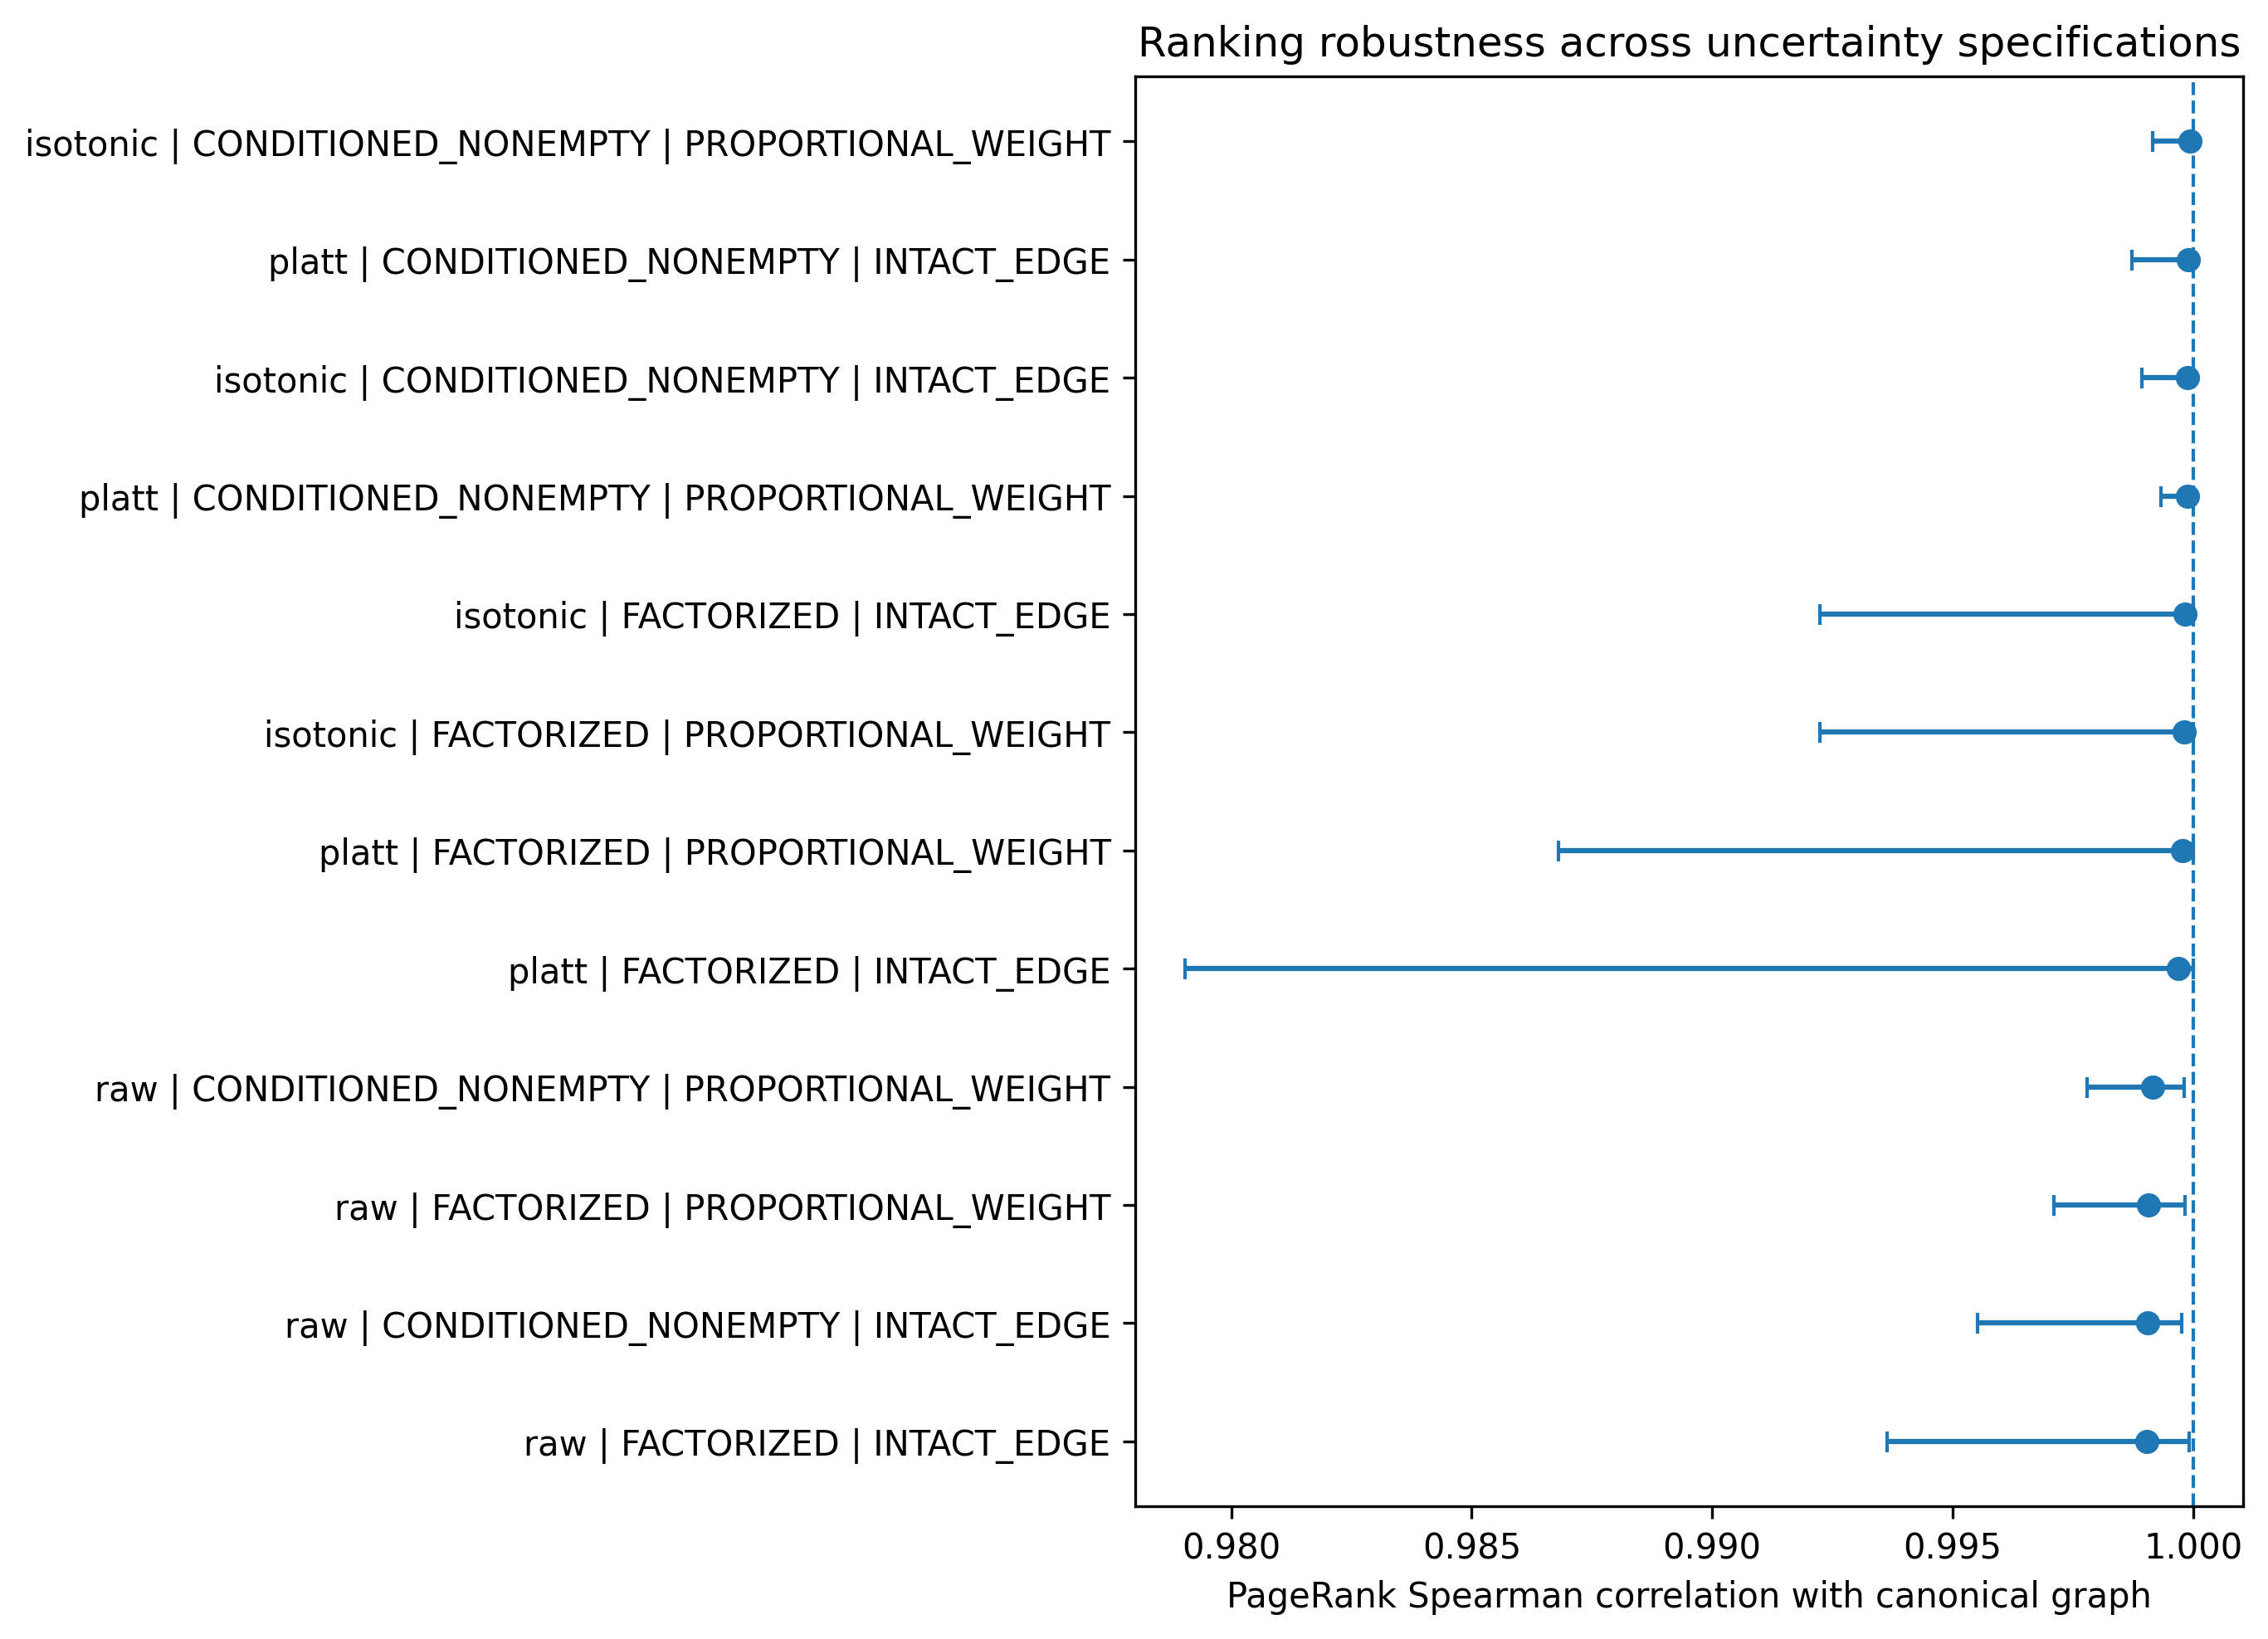


 Figure_J5_02_normalized_lambda2_robustness.png


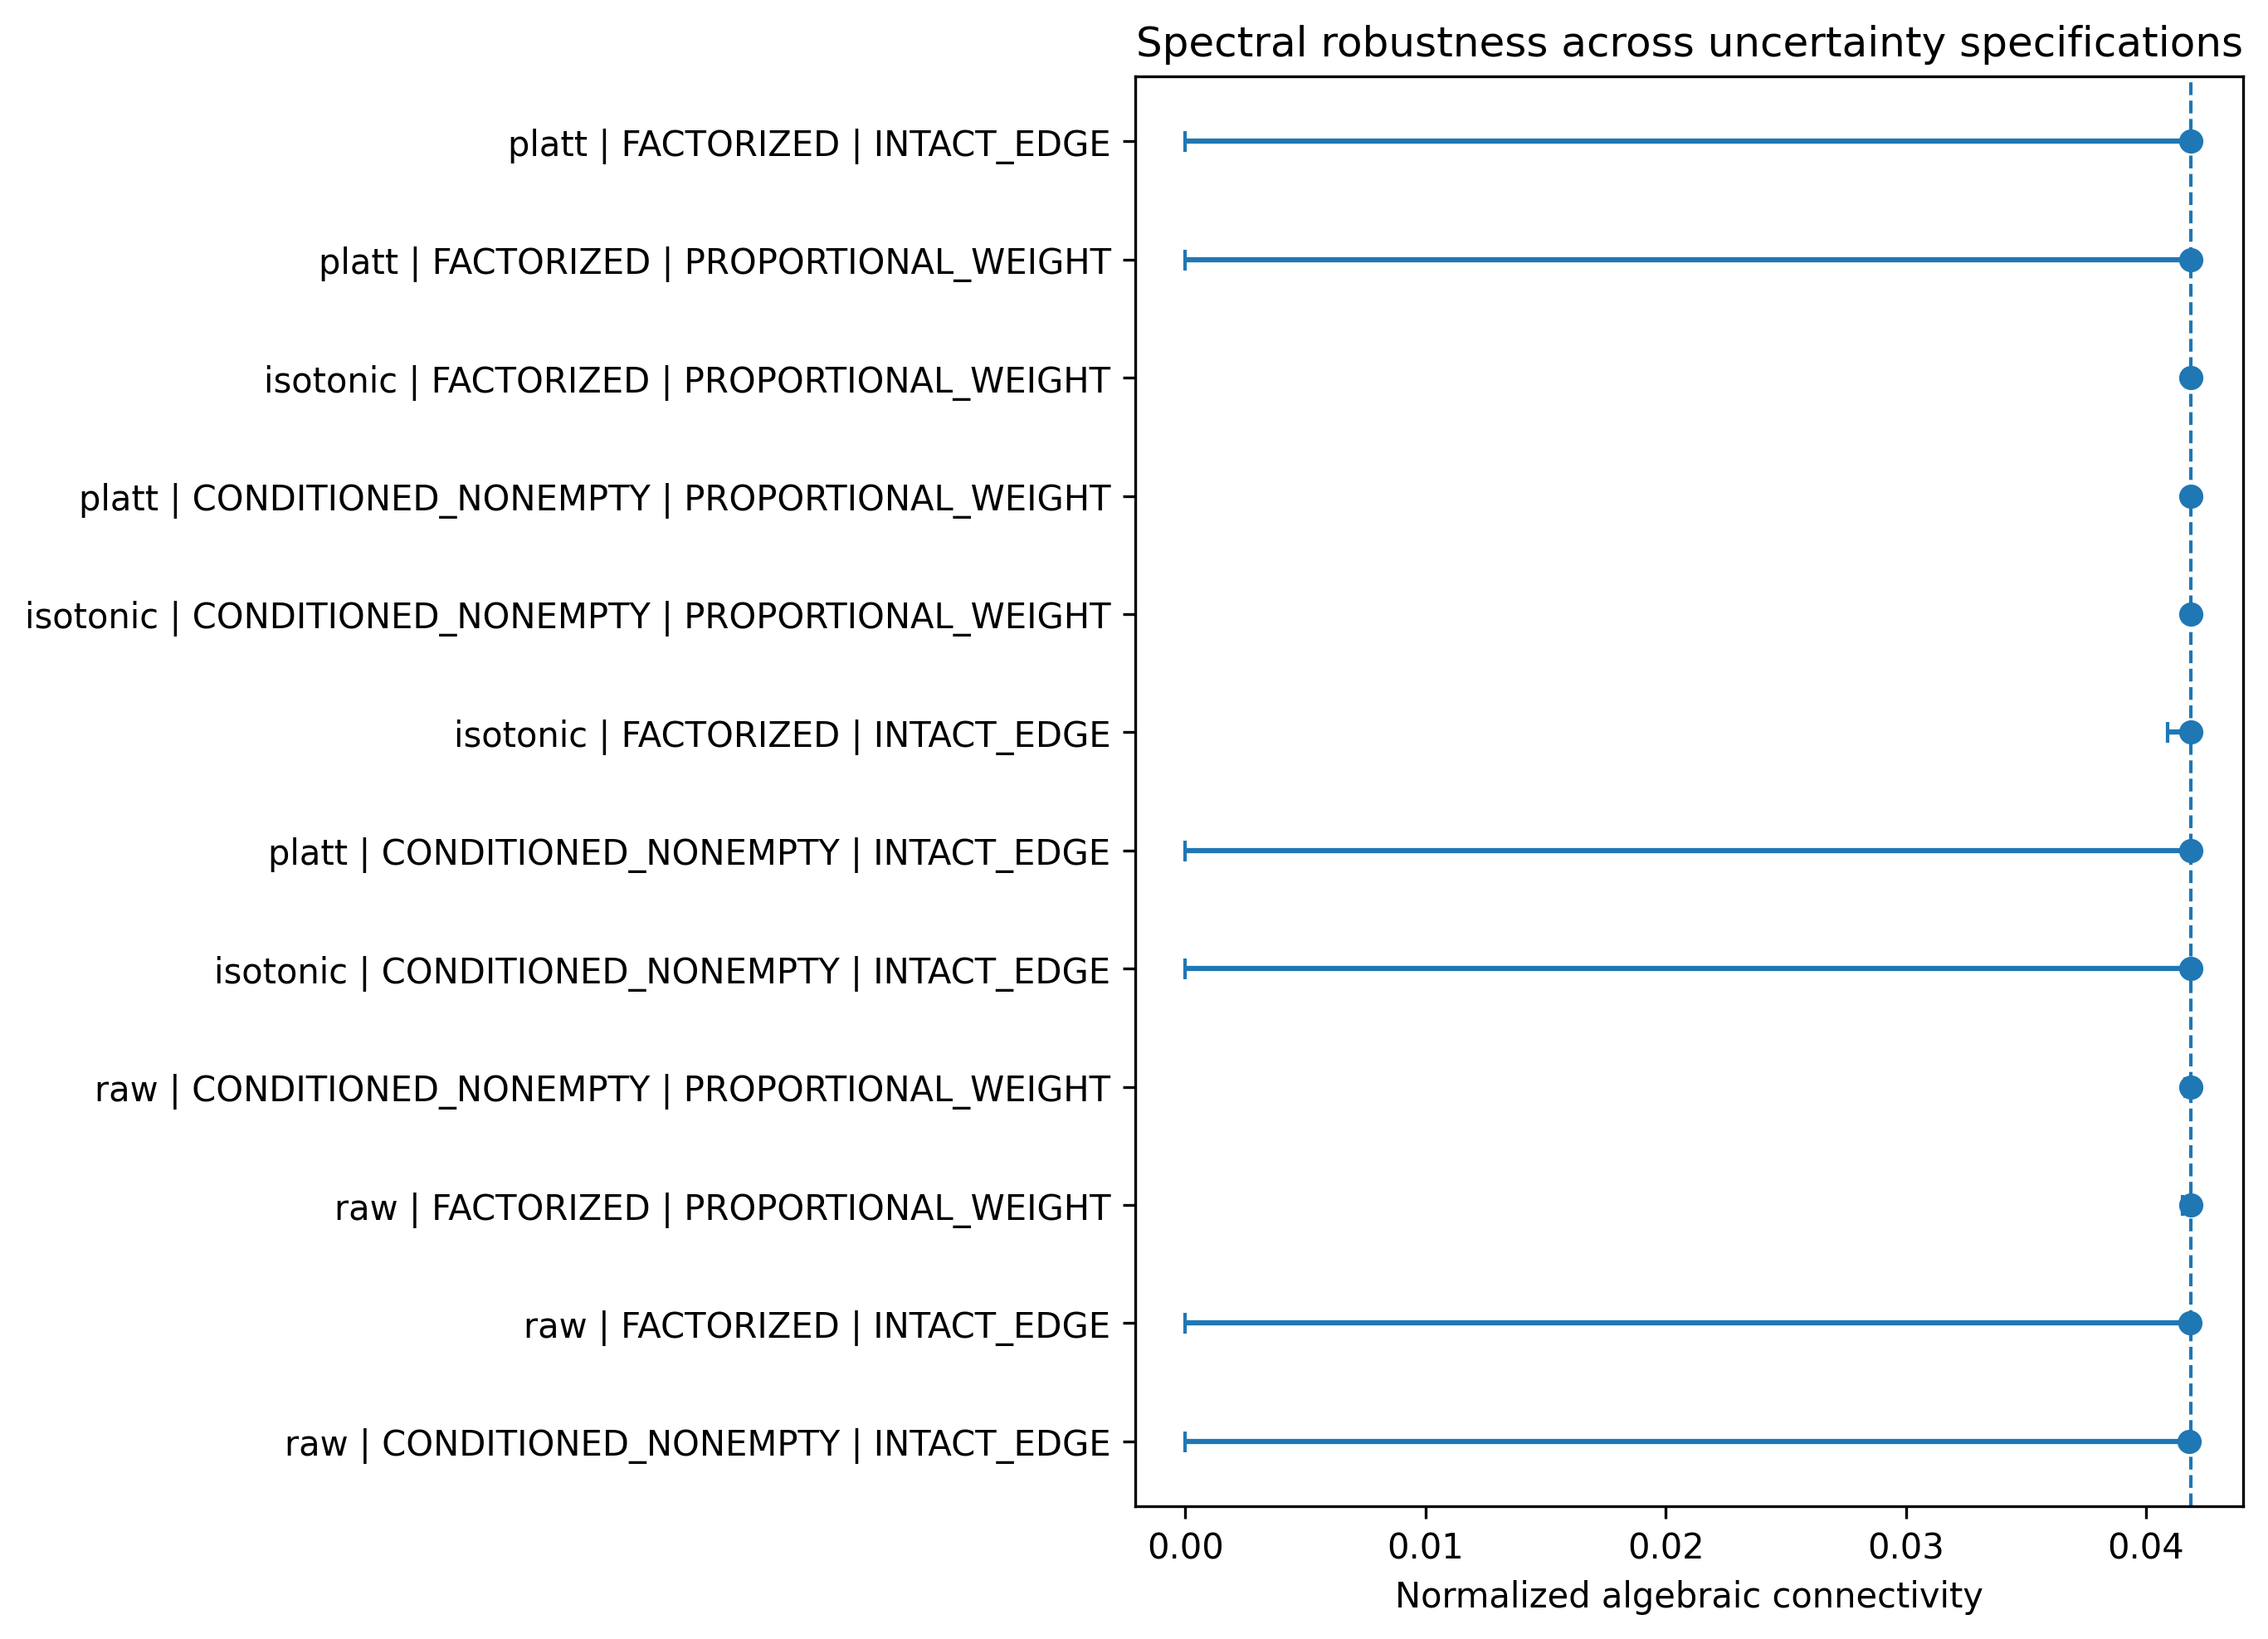

In [20]:
from pathlib import Path
from IPython.display import display, Image

FIGURES = Path(
    "/content/gdrive/MyDrive/tese_doutoral/runs/"
    "jasist_identity_uncertainty_20261005/"
    "05_robustness_uncertainty_propagation/figures"
)

files = [
    FIGURES / "Figure_J5_01_pagerank_robustness_across_scenarios.png",
    FIGURES / "Figure_J5_02_normalized_lambda2_robustness.png",
]

for f in files:
    print("\n", f.name)
    display(Image(filename=str(f)))

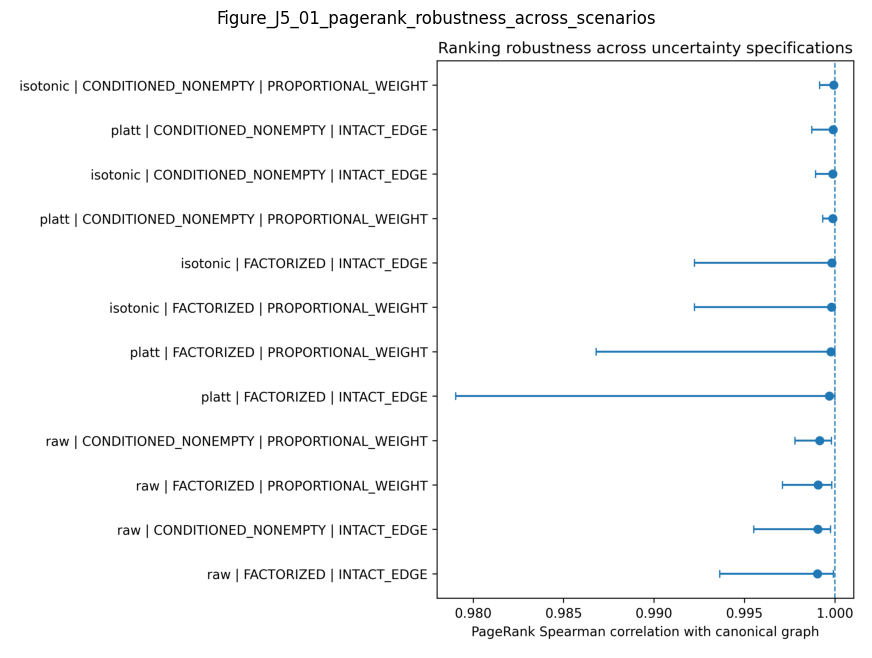

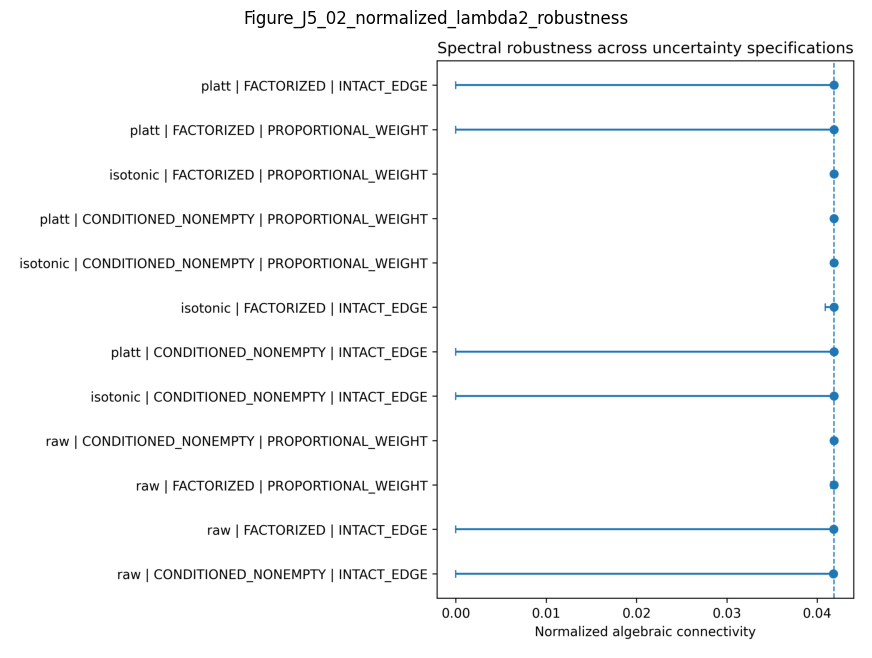

In [21]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

for f in files:
    img = PILImage.open(f)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f.stem)
    plt.show()

No valid Drive mount detected. Mounting Google Drive at: /content/google_drive_real
Mounted at /content/google_drive_real
Using mounted Google Drive root: /content/google_drive_real/MyDrive/tese_doutoral
JASIST — PART J6
REVIEWER-DRIVEN ROBUSTNESS AND METHODOLOGICAL STRESS TESTS
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/06_reviewer_driven_robustness

[1/9] Loading frozen inputs...
Resolved ROOT: /content/google_drive_real/MyDrive/tese_doutoral
Checking frozen feature frame: /content/google_drive_real/MyDrive/tese_doutoral/runs/joi_entity_resolution_20261003/06D_incumbent_aware_multievidence/tables/Table_06D_01_feature_frame.csv
Exists: True
Feature frame: (825, 54)
Test pairs: (135, 28)
J2 targets: (35, 30)
Mapped: 30
Graph: 404 nodes | 1600 edges
Baseline lambda2_norm: 0.04187754653371288
Baseline lambda2_comb: 0.3293457585731886

[2/9] Auditing mapped vs unmapped selection bias...

Mapped vs unmapped continuous audit:
         

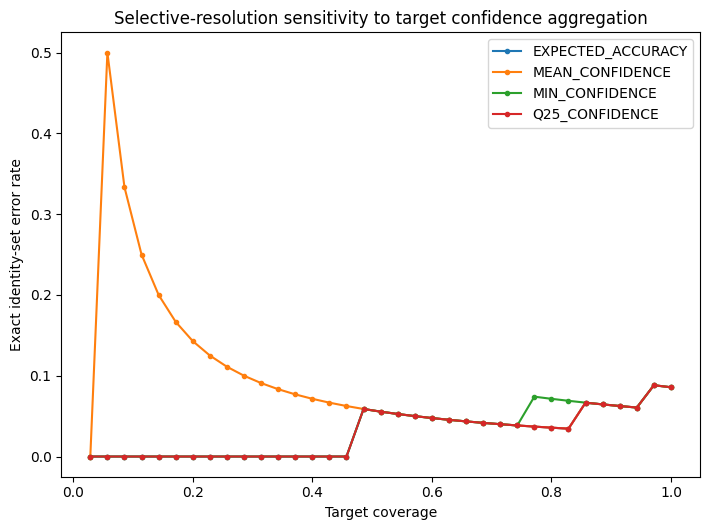


[4/9] Estimating train+validation cardinality prior and structured posterior...

Empirical q(K | ambiguity stratum), train+validation only:
   ambiguity_stratum  K  count  probability
EXACT_NAME_AMBIGUOUS  1     56     0.823529
EXACT_NAME_AMBIGUOUS  2     11     0.161765
EXACT_NAME_AMBIGUOUS  3      1     0.014706
     LOWER_AMBIGUITY  1     73     1.000000

Cardinality model bias summary:
                       model  mean_expected_K  mean_reference_K  mean_bias_K  MAE_expected_K
                  FACTORIZED         1.004835          1.085714    -0.080879        0.129835
        CONDITIONED_NONEMPTY         1.031801          1.085714    -0.053913        0.113944
STRUCTURED_CARDINALITY_PRIOR         1.105387          1.085714     0.019673        0.158328

[5/9] Propagating structured cardinality posterior to the network...

Structured posterior | INTACT_EDGE
  50/250
  100/250
  150/250
  200/250
  250/250

Structured posterior | PROPORTIONAL_WEIGHT
  50/250
  100/250
  150/250
  200/

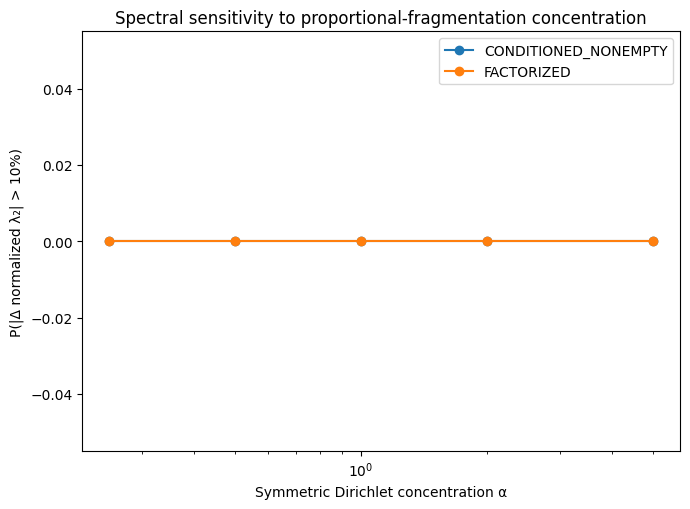


[7/9] Attempting conservative crosswalk extension with affiliation corroboration...
No candidate extension records could be generated.

[8/9] Creating reviewer-focused synthesis and didactic figures...


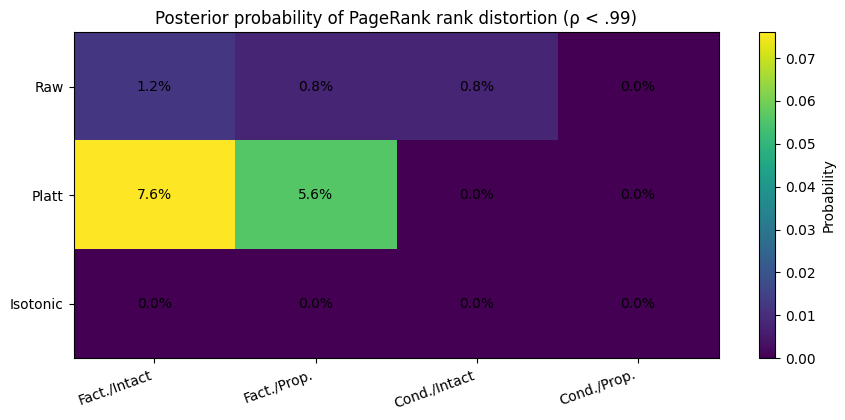

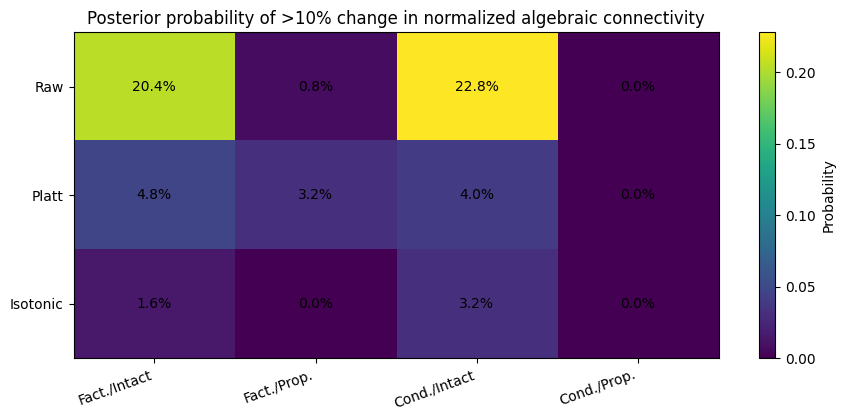

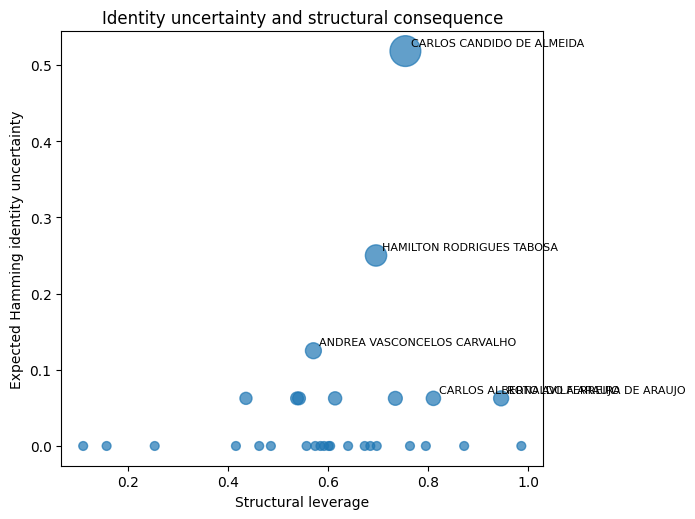


[9/9] Writing manifest...

PART J6 COMPLETE
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/06_reviewer_driven_robustness

RETURN TO CHAT:
1. Console output from [2/9] through PART J6 COMPLETE
2. Table_J6_02_crosswalk_selection_bias_continuous.csv
3. Table_J6_05_abstention_aggregator_AURC.csv
4. Table_J6_06_decision_theoretic_abstention.csv
5. Table_J6_09_cardinality_model_bias_summary.csv
6. Table_J6_11_structured_posterior_network_summary.csv
7. Table_J6_13_dirichlet_alpha_sensitivity_summary.csv
8. Table_J6_15_extended_crosswalk_accepted_sensitivity_only.csv (if created)
9. J6_manifest.json


In [2]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J6
Reviewer-driven robustness and methodological stress tests

Addresses the main methodological concerns raised in the pre-submission review:

A. Crosswalk selection-bias audit (mapped vs unmapped targets)
B. Alternative target-level abstention aggregators and decision-theoretic abstention
C. Structured cardinality posterior to relax factorized Bernoulli independence
D. Dirichlet concentration sensitivity for PROPORTIONAL_WEIGHT fragmentation
E. Conservative extended crosswalk attempt using name similarity + affiliation corroboration
F. Network propagation under the structured posterior

This script does NOT overwrite J1–J5 outputs.
All outputs are written to a new JASIST run subdirectory.

Primary scientific principles:
- no test-set retuning;
- no fabricated false-merge destinations;
- train+validation only for the empirical cardinality prior;
- exact primary crosswalk remains unchanged;
- any extended crosswalk is labeled sensitivity-only.
"""

from pathlib import Path
from collections import Counter, defaultdict
import json, pickle, re, unicodedata, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import (
    spearmanr, mannwhitneyu, fisher_exact
)
from scipy.sparse.linalg import eigsh
from difflib import SequenceMatcher

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
SEED = 20261006
RNG = np.random.default_rng(SEED)

BOOTSTRAP_REPS = 10000
PERMUTATIONS = 10000
DRAWS_CARDINALITY_NETWORK = 250
DRAWS_DIRICHLET_SCENARIO = 250
PROGRESS_EVERY = 50

DIRICHLET_ALPHAS = [0.25, 0.5, 1.0, 2.0, 5.0]
ABSTENTION_COSTS = [0.02, 0.05, 0.10, 0.15, 0.20]

# ------------------------------------------------------------
# ROBUST GOOGLE DRIVE ROOT RESOLUTION
# ------------------------------------------------------------
# Each article is run in an independent Colab runtime. Therefore the local
# mount used in a previous notebook may not exist in the current runtime.
# Detect an already mounted real Drive first; if none is found, mount Drive
# explicitly at a clean location.

def resolve_tese_root():
    candidates = [
        Path("/content/gdrive/MyDrive/tese_doutoral"),
        Path("/content/google_drive_real/MyDrive/tese_doutoral"),
        Path("/content/drive/MyDrive/tese_doutoral"),
    ]

    # Prefer roots that contain the frozen JOI run, preventing accidental use
    # of a fake local /content/drive tree.
    for c in candidates:
        if (
            c.exists()
            and (c / "runs/joi_entity_resolution_20261003").exists()
            and (c / "runs/jcn_pareto_sparsification_20261002").exists()
        ):
            print("Using mounted Google Drive root:", c)
            return c

    # No valid mounted Drive detected: mount at a new clean location.
    try:
        from google.colab import drive
    except Exception as e:
        raise RuntimeError(
            "Google Drive is not mounted and this runtime is not a Google Colab "
            f"environment. Original error: {e}"
        )

    mountpoint = Path("/content/google_drive_real")

    # If this location is contaminated, choose another clean mountpoint.
    if mountpoint.exists() and any(mountpoint.iterdir()):
        mountpoint = Path("/content/google_drive_jasist")

    mountpoint.mkdir(parents=True, exist_ok=True)
    print("No valid Drive mount detected. Mounting Google Drive at:", mountpoint)
    drive.mount(str(mountpoint))

    c = mountpoint / "MyDrive/tese_doutoral"

    if not (
        c.exists()
        and (c / "runs/joi_entity_resolution_20261003").exists()
        and (c / "runs/jcn_pareto_sparsification_20261002").exists()
    ):
        raise FileNotFoundError(
            "Google Drive mounted successfully, but the expected tese_doutoral "
            "runs were not found under: " + str(c)
        )

    print("Using mounted Google Drive root:", c)
    return c

ROOT = resolve_tese_root()
JOI_ROOT = ROOT / "runs/joi_entity_resolution_20261003"
JASIST_ROOT = ROOT / "runs/jasist_identity_uncertainty_20261005"

FEATURE_FRAME = (
    JOI_ROOT /
    "06D_incumbent_aware_multievidence/tables/"
    "Table_06D_01_feature_frame.csv"
)

AUTHOR_TABLE = (
    JOI_ROOT /
    "00_provenance/frozen_inputs/"
    "autores_final_CANONICAL.xlsx"
)

PAIR_FILE = (
    JASIST_ROOT /
    "01_identity_uncertainty_calibration/tables/"
    "Table_J1_08_test_pair_uncertainty.csv"
)

J2_PRIMARY = (
    JASIST_ROOT /
    "02_target_identity_set_uncertainty/tables/"
    "Table_J2_02_primary_target_identity_set_uncertainty.csv"
)

MAP_FILE = (
    JASIST_ROOT /
    "03B_order_invariant_structural_identity_risk/tables/"
    "Table_J3B_02_target_to_graph_mapping_audit.csv"
)

GRAPH_FILE = (
    ROOT /
    "runs/jcn_pareto_sparsification_20261002/"
    "00_canonical_baseline/graphs/empirical_graph_canonical.pkl"
)

OUT = JASIST_ROOT / "06_reviewer_driven_robustness"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"

for p in [TABLES, FIGURES, ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("JASIST — PART J6")
print("REVIEWER-DRIVEN ROBUSTNESS AND METHODOLOGICAL STRESS TESTS")
print("=" * 110)
print("Output:", OUT)

# ============================================================
# HELPERS
# ============================================================
def norm_text(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = unicodedata.normalize("NFKD", str(x))
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def token_signature(x):
    return " ".join(sorted(norm_text(x).split()))

def token_jaccard(a, b):
    A, B = set(norm_text(a).split()), set(norm_text(b).split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def token_overlap_min(a, b):
    A, B = set(norm_text(a).split()), set(norm_text(b).split())
    if not A or not B:
        return 0.0
    return len(A & B) / min(len(A), len(B))

def seqsim(a, b):
    return SequenceMatcher(None, token_signature(a), token_signature(b)).ratio()

def binary_entropy(p):
    p = np.clip(np.asarray(p, float), 1e-12, 1-1e-12)
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))

def set_metrics_for_target(g, pcol="p_isotonic"):
    p = np.clip(g[pcol].to_numpy(float), 1e-12, 1-1e-12)
    pred = p >= 0.5
    ref = g["y_ref"].to_numpy(int) == 1

    pred_ids = set(g.loc[pred, "candidate_openalex_id"].astype(str))
    ref_ids = set(g.loc[ref, "candidate_openalex_id"].astype(str))
    inter = len(pred_ids & ref_ids)
    union = len(pred_ids | ref_ids)

    jacc = inter/union if union else 1.0
    exact = int(pred_ids == ref_ids)

    pair_conf = 2*np.abs(p - 0.5)
    u_h = float(np.minimum(p, 1-p).sum())

    return {
        "n_candidates": len(g),
        "exact_set_recovery": exact,
        "set_jaccard": jacc,
        "expected_hamming_uncertainty": u_h,
        "set_entropy_bits": float(binary_entropy(p).sum()),
        "prob_MAP_identity_set": float(np.prod(np.maximum(p, 1-p))),
        "min_pair_confidence": float(pair_conf.min()),
        "q25_pair_confidence": float(np.quantile(pair_conf, 0.25)),
        "mean_pair_confidence": float(pair_conf.mean()),
        "expected_accuracy_confidence": float(1 - u_h/len(g)),
        "reference_K": int(ref.sum()),
        "exact_name_ambiguous": bool(
            pd.to_numeric(g["exact_name_count_target"], errors="coerce")
            .fillna(0).max() >= 2
        ),
    }

def bootstrap_mean_diff(a, b, reps=10000, seed=SEED):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    rng = np.random.default_rng(seed)
    obs = float(np.mean(a)-np.mean(b))
    vals = np.empty(reps, float)
    for i in range(reps):
        vals[i] = (
            rng.choice(a, len(a), replace=True).mean()
            - rng.choice(b, len(b), replace=True).mean()
        )
    lo, hi = np.quantile(vals, [0.025, 0.975])
    return obs, float(lo), float(hi)

def poisson_binomial_pmf(p):
    """Exact Poisson-binomial PMF via dynamic programming."""
    p = np.asarray(p, float)
    pmf = np.array([1.0])
    for q in p:
        nxt = np.zeros(len(pmf)+1)
        nxt[:-1] += pmf*(1-q)
        nxt[1:] += pmf*q
        pmf = nxt
    return pmf

def weighted_choice_without_replacement(items, weights, k, rng):
    items = list(items)
    weights = np.asarray(weights, float)
    if k <= 0:
        return []
    k = min(k, len(items))
    selected = []
    avail = np.arange(len(items))
    w = weights.copy()
    for _ in range(k):
        ww = np.clip(w[avail], 0, None)
        if ww.sum() <= 0:
            probs = np.ones(len(avail))/len(avail)
        else:
            probs = ww/ww.sum()
        idx_pos = rng.choice(np.arange(len(avail)), p=probs)
        idx = avail[idx_pos]
        selected.append(items[idx])
        avail = np.delete(avail, idx_pos)
    return selected

def sample_structured_memberships(g, pcol, qk_by_stratum, rng):
    """
    Structured posterior:
      1) draw K from empirical q(K | ambiguity stratum), estimated on train+validation labels;
      2) truncate to feasible K <= n_candidates;
      3) choose exactly K candidates without replacement using calibrated odds as weights.
    """
    n = len(g)
    stratum = "EXACT_NAME_AMBIGUOUS" if (
        pd.to_numeric(g["exact_name_count_target"], errors="coerce")
        .fillna(0).max() >= 2
    ) else "LOWER_AMBIGUITY"

    q = qk_by_stratum.get(stratum, {})
    feasible = {k:v for k,v in q.items() if 0 <= k <= n}

    if not feasible:
        feasible = {1:1.0}

    ks = np.array(sorted(feasible), dtype=int)
    probs = np.array([feasible[k] for k in ks], float)
    probs = probs/probs.sum()
    K = int(rng.choice(ks, p=probs))

    p = np.clip(g[pcol].to_numpy(float), 1e-6, 1-1e-6)
    odds = p/(1-p)
    ids = list(g["candidate_openalex_id"].astype(str))
    chosen = weighted_choice_without_replacement(ids, odds, K, rng)
    return K, set(chosen)

def lambda2_norm(G):
    if G.number_of_nodes() < 3:
        return np.nan
    if not nx.is_connected(G):
        return 0.0
    try:
        L = nx.normalized_laplacian_matrix(G, weight="weight").astype(float)
        vals = eigsh(L, k=2, which="SM", return_eigenvectors=False)
        vals = np.sort(np.real(vals))
        return float(max(0.0, vals[1]))
    except Exception:
        return np.nan

def lambda2_comb(G):
    if G.number_of_nodes() < 3:
        return np.nan
    if not nx.is_connected(G):
        return 0.0
    try:
        L = nx.laplacian_matrix(G, weight="weight").astype(float)
        vals = eigsh(L, k=2, which="SM", return_eigenvectors=False)
        vals = np.sort(np.real(vals))
        return float(max(0.0, vals[1]))
    except Exception:
        return np.nan

def build_fragmented_graph(G, target_k, operator, rng, dirichlet_alpha=1.0):
    fragments = {}
    origin = {}

    for n in G.nodes():
        if n not in target_k:
            fragments[n] = [n]
            origin[n] = n
            continue

        k = int(target_k[n])
        if k == 0:
            fragments[n] = []
        elif k == 1:
            fragments[n] = [n]
            origin[n] = n
        else:
            fs = [f"__FRAG__::{n}::{j+1}" for j in range(k)]
            fragments[n] = fs
            for f in fs:
                origin[f] = n

    H = nx.Graph()
    for fs in fragments.values():
        for f in fs:
            H.add_node(f)

    for u,v,d in G.edges(data=True):
        w = float(d.get("weight", 1.0))
        fu, fv = fragments[u], fragments[v]
        if len(fu)==0 or len(fv)==0:
            continue

        if operator == "INTACT_EDGE":
            uu = fu[rng.integers(0,len(fu))]
            vv = fv[rng.integers(0,len(fv))]
            if uu == vv:
                continue
            if H.has_edge(uu,vv):
                H[uu][vv]["weight"] += w
            else:
                H.add_edge(uu,vv,weight=w)

        elif operator == "PROPORTIONAL_WEIGHT":
            if len(fu)==1:
                pu = np.array([1.0])
            else:
                pu = rng.dirichlet(np.full(len(fu), dirichlet_alpha))
            if len(fv)==1:
                pv = np.array([1.0])
            else:
                pv = rng.dirichlet(np.full(len(fv), dirichlet_alpha))

            alloc = np.outer(pu,pv)
            alloc /= alloc.sum()

            for i,uu in enumerate(fu):
                for j,vv in enumerate(fv):
                    ww = w*float(alloc[i,j])
                    if ww <= 0 or uu == vv:
                        continue
                    if H.has_edge(uu,vv):
                        H[uu][vv]["weight"] += ww
                    else:
                        H.add_edge(uu,vv,weight=ww)
        else:
            raise ValueError(operator)

    return H, origin

def aggregate_pagerank(H, origin, original_nodes):
    pr = nx.pagerank(H, weight="weight")
    agg = {n:0.0 for n in original_nodes}
    for n,v in pr.items():
        agg[origin[n]] += float(v)
    return agg

def network_outcomes(H, origin, G, base_pr, base_top20, original_nodes):
    pr = aggregate_pagerank(H, origin, original_nodes)
    a = np.array([base_pr[n] for n in original_nodes])
    b = np.array([pr.get(n,0.0) for n in original_nodes])
    rho,_ = spearmanr(a,b)

    alt_top20 = set(
        np.array(original_nodes, dtype=object)[
            np.argsort(-b)[:20]
        ]
    )
    jac20 = len(base_top20 & alt_top20)/len(base_top20 | alt_top20)

    gcc = max(nx.connected_components(H), key=len) if H.number_of_nodes() else set()

    return {
        "nodes": H.number_of_nodes(),
        "edges": H.number_of_edges(),
        "gcc_fraction": len(gcc)/H.number_of_nodes() if H.number_of_nodes() else 0.0,
        "transitivity": nx.transitivity(H) if H.number_of_nodes() else np.nan,
        "avg_clustering": nx.average_clustering(H, weight="weight") if H.number_of_nodes() else np.nan,
        "lambda2_norm": lambda2_norm(H),
        "lambda2_comb": lambda2_comb(H),
        "pagerank_spearman": float(rho),
        "top20_jaccard": float(jac20)
    }

# ============================================================
# 1. LOAD ALL FROZEN INPUTS
# ============================================================
print("\n[1/9] Loading frozen inputs...")

print("Resolved ROOT:", ROOT)
print("Checking frozen feature frame:", FEATURE_FRAME)
print("Exists:", FEATURE_FRAME.exists())

if not FEATURE_FRAME.exists():
    raise FileNotFoundError(
        "Frozen JOI feature frame is not visible in the resolved Google Drive. "
        "Expected file: " + str(FEATURE_FRAME)
    )

feat = pd.read_csv(FEATURE_FRAME)
pairs = pd.read_csv(PAIR_FILE)
j2 = pd.read_csv(J2_PRIMARY)
mapping = pd.read_csv(MAP_FILE)

with open(GRAPH_FILE, "rb") as f:
    G = pickle.load(f)

original_nodes = list(G.nodes())
base_pr = nx.pagerank(G, weight="weight")
base_arr = np.array([base_pr[n] for n in original_nodes])
base_top20 = set(np.array(original_nodes, dtype=object)[np.argsort(-base_arr)[:20]])

baseline = {
    "lambda2_norm": lambda2_norm(G),
    "lambda2_comb": lambda2_comb(G)
}

print("Feature frame:", feat.shape)
print("Test pairs:", pairs.shape)
print("J2 targets:", j2.shape)
print("Mapped:", int(mapping["mapping_status"].eq("MAPPED_UNIQUE").sum()))
print("Graph:", G.number_of_nodes(), "nodes |", G.number_of_edges(), "edges")
print("Baseline lambda2_norm:", baseline["lambda2_norm"])
print("Baseline lambda2_comb:", baseline["lambda2_comb"])

# ============================================================
# 2. CROSSWALK SELECTION-BIAS AUDIT
# ============================================================
print("\n[2/9] Auditing mapped vs unmapped selection bias...")

audit = (
    j2.merge(
        mapping[["target_key","mapping_status","mapping_method","mapped_node"]],
        on="target_key", how="left"
    )
)

audit["mapped"] = audit["mapping_status"].eq("MAPPED_UNIQUE")

audit.to_csv(
    TABLES/"Table_J6_01_crosswalk_mapped_unmapped_target_audit.csv",
    index=False
)

continuous = [
    "n_candidates",
    "expected_hamming_uncertainty",
    "set_entropy_bits",
    "prob_MAP_identity_set",
    "set_jaccard"
]

bias_rows = []

for metric in continuous:
    a = audit.loc[audit["mapped"], metric].dropna().to_numpy(float)
    b = audit.loc[~audit["mapped"], metric].dropna().to_numpy(float)

    try:
        U,p = mannwhitneyu(a,b,alternative="two-sided")
    except Exception:
        U,p = np.nan,np.nan

    diff,lo,hi = bootstrap_mean_diff(a,b,BOOTSTRAP_REPS,SEED)

    bias_rows.append({
        "metric":metric,
        "mapped_n":len(a),
        "unmapped_n":len(b),
        "mapped_mean":float(np.mean(a)),
        "unmapped_mean":float(np.mean(b)),
        "mapped_median":float(np.median(a)),
        "unmapped_median":float(np.median(b)),
        "mean_difference_mapped_minus_unmapped":diff,
        "bootstrap_CI_low":lo,
        "bootstrap_CI_high":hi,
        "mann_whitney_U":U,
        "two_sided_p":p
    })

bias_cont = pd.DataFrame(bias_rows)

# exact-name ambiguity 2x2
tab = pd.crosstab(audit["mapped"], audit["exact_name_ambiguous"])
try:
    # ensure [[mapped false: no/yes], [mapped true: no/yes]]
    a00 = int(((~audit["mapped"]) & (~audit["exact_name_ambiguous"])).sum())
    a01 = int(((~audit["mapped"]) & ( audit["exact_name_ambiguous"])).sum())
    a10 = int((( audit["mapped"]) & (~audit["exact_name_ambiguous"])).sum())
    a11 = int((( audit["mapped"]) & ( audit["exact_name_ambiguous"])).sum())
    odds,pf = fisher_exact([[a10,a11],[a00,a01]])
except Exception:
    odds,pf = np.nan,np.nan

bias_binary = pd.DataFrame([{
    "measure":"exact_name_ambiguous",
    "mapped_ambiguous":int((audit["mapped"] & audit["exact_name_ambiguous"]).sum()),
    "mapped_total":int(audit["mapped"].sum()),
    "unmapped_ambiguous":int((~audit["mapped"] & audit["exact_name_ambiguous"]).sum()),
    "unmapped_total":int((~audit["mapped"]).sum()),
    "fisher_odds_ratio":odds,
    "fisher_two_sided_p":pf
}])

bias_cont.to_csv(TABLES/"Table_J6_02_crosswalk_selection_bias_continuous.csv",index=False)
bias_binary.to_csv(TABLES/"Table_J6_03_crosswalk_selection_bias_ambiguity.csv",index=False)

print("\nMapped vs unmapped continuous audit:")
print(bias_cont.to_string(index=False))
print("\nExact-name ambiguity audit:")
print(bias_binary.to_string(index=False))

# ============================================================
# 3. ABSTENTION AGGREGATOR SENSITIVITY
# ============================================================
print("\n[3/9] Comparing target-level abstention aggregators...")

target_rows = []
for tk,g in pairs.groupby("target_key"):
    s = set_metrics_for_target(g, "p_isotonic")
    s["target_key"] = tk
    s["target_name"] = g.iloc[0]["target_name"]
    target_rows.append(s)

target_df = pd.DataFrame(target_rows)

aggregators = {
    "MIN_CONFIDENCE":"min_pair_confidence",
    "Q25_CONFIDENCE":"q25_pair_confidence",
    "MEAN_CONFIDENCE":"mean_pair_confidence",
    "EXPECTED_ACCURACY":"expected_accuracy_confidence"
}

curve_rows = []

for agg,col in aggregators.items():
    ordered = target_df.sort_values(
        [col,"prob_MAP_identity_set"],
        ascending=[False,False]
    ).reset_index(drop=True)

    for k in range(1,len(ordered)+1):
        sub = ordered.iloc[:k]
        curve_rows.append({
            "aggregator":agg,
            "decided_targets":k,
            "target_coverage":k/len(ordered),
            "exact_set_error_rate":1-sub["exact_set_recovery"].mean(),
            "mean_set_jaccard":sub["set_jaccard"].mean(),
            "mean_expected_hamming_uncertainty":sub["expected_hamming_uncertainty"].mean()
        })

curve = pd.DataFrame(curve_rows)

# AURC over coverage grid
aurc_rows = []
for agg,g in curve.groupby("aggregator"):
    gg = g.sort_values("target_coverage")
    aurc = float(np.trapz(
        gg["exact_set_error_rate"].to_numpy(float),
        gg["target_coverage"].to_numpy(float)
    ))
    aurc_rows.append({
        "aggregator":agg,
        "AURC_exact_set_error":aurc,
        "full_coverage_error":float(gg.iloc[-1]["exact_set_error_rate"]),
        "min_observed_error":float(gg["exact_set_error_rate"].min())
    })

aurc_df = pd.DataFrame(aurc_rows).sort_values("AURC_exact_set_error")

curve.to_csv(TABLES/"Table_J6_04_abstention_aggregator_coverage_risk_curves.csv",index=False)
aurc_df.to_csv(TABLES/"Table_J6_05_abstention_aggregator_AURC.csv",index=False)

print("\nAbstention aggregator AURC:")
print(aurc_df.to_string(index=False))

# Decision-theoretic abstention:
# resolving incurs expected per-candidate Hamming loss U_H/n;
# abstaining incurs fixed cost c_A.
utility_rows = []
for cA in ABSTENTION_COSTS:
    loss = target_df["expected_hamming_uncertainty"]/target_df["n_candidates"]
    decided = target_df[loss <= cA].copy()

    utility_rows.append({
        "abstention_cost":cA,
        "decision_rule":"resolve if expected per-candidate Hamming loss <= abstention cost",
        "decided_targets":len(decided),
        "target_coverage":len(decided)/len(target_df),
        "exact_set_error_rate":
            1-decided["exact_set_recovery"].mean() if len(decided) else np.nan,
        "mean_set_jaccard":
            decided["set_jaccard"].mean() if len(decided) else np.nan,
        "mean_expected_loss":
            (decided["expected_hamming_uncertainty"]/decided["n_candidates"]).mean()
            if len(decided) else np.nan
    })

utility = pd.DataFrame(utility_rows)
utility.to_csv(TABLES/"Table_J6_06_decision_theoretic_abstention.csv",index=False)

print("\nDecision-theoretic abstention:")
print(utility.to_string(index=False))

# Figure: coverage-risk by aggregator
fig,ax = plt.subplots(figsize=(7.2,5.4))
for agg,g in curve.groupby("aggregator"):
    gg = g.sort_values("target_coverage")
    ax.plot(
        gg["target_coverage"],
        gg["exact_set_error_rate"],
        marker="o",
        markersize=3,
        label=agg
    )
ax.set_xlabel("Target coverage")
ax.set_ylabel("Exact identity-set error rate")
ax.set_title("Selective-resolution sensitivity to target confidence aggregation")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES/"Figure_J6_01_abstention_aggregator_coverage_risk.png",
            dpi=300,bbox_inches="tight")
fig.savefig(FIGURES/"Figure_J6_01_abstention_aggregator_coverage_risk.pdf",
            bbox_inches="tight")
plt.show()
plt.close(fig)

# ============================================================
# 4. STRUCTURED CARDINALITY POSTERIOR
# ============================================================
print("\n[4/9] Estimating train+validation cardinality prior and structured posterior...")

tv = feat[feat["split"].isin(["train","validation"])].copy()

target_k_train = (
    tv.groupby("target_key")
    .agg(
        K=("y_ref","sum"),
        exact_name_count_target=("exact_name_count_target","max")
    )
    .reset_index()
)

target_k_train["ambiguity_stratum"] = np.where(
    target_k_train["exact_name_count_target"] >= 2,
    "EXACT_NAME_AMBIGUOUS",
    "LOWER_AMBIGUITY"
)

qk_by_stratum = {}

prior_rows = []
for stratum,g in target_k_train.groupby("ambiguity_stratum"):
    counts = g["K"].astype(int).value_counts().sort_index()
    probs = counts/counts.sum()
    qk_by_stratum[stratum] = {
        int(k):float(v) for k,v in probs.items()
    }
    for k,v in probs.items():
        prior_rows.append({
            "ambiguity_stratum":stratum,
            "K":int(k),
            "count":int(counts.loc[k]),
            "probability":float(v)
        })

prior_df = pd.DataFrame(prior_rows)
prior_df.to_csv(TABLES/"Table_J6_07_empirical_cardinality_prior_train_validation.csv",index=False)

print("\nEmpirical q(K | ambiguity stratum), train+validation only:")
print(prior_df.to_string(index=False))

# Compare expected K distributions on held-out test
card_rows = []

for tk,g in pairs.groupby("target_key"):
    p = np.clip(g["p_isotonic"].to_numpy(float),1e-12,1-1e-12)
    refK = int(g["y_ref"].sum())
    pmf = poisson_binomial_pmf(p)

    # factorized expected K
    Ef = float(p.sum())
    P0 = float(pmf[0])

    # conditioned-nonempty expected K
    if P0 < 1:
        Ec = Ef/(1-P0)
    else:
        Ec = np.nan

    stratum = "EXACT_NAME_AMBIGUOUS" if (
        pd.to_numeric(g["exact_name_count_target"], errors="coerce")
        .fillna(0).max() >= 2
    ) else "LOWER_AMBIGUITY"

    q = qk_by_stratum.get(stratum,{1:1.0})
    feasible = {k:v for k,v in q.items() if k <= len(g)}
    z = sum(feasible.values())
    Es = sum(k*v for k,v in feasible.items())/z if z else 1.0

    card_rows.append({
        "target_key":tk,
        "target_name":g.iloc[0]["target_name"],
        "ambiguity_stratum":stratum,
        "reference_K":refK,
        "factorized_expected_K":Ef,
        "conditioned_nonempty_expected_K":Ec,
        "structured_prior_expected_K":Es,
        "factorized_minus_reference":Ef-refK,
        "conditioned_minus_reference":Ec-refK,
        "structured_minus_reference":Es-refK
    })

card = pd.DataFrame(card_rows)

card.to_csv(TABLES/"Table_J6_08_test_cardinality_model_comparison.csv",index=False)

card_summary = pd.DataFrame([
    {
        "model":"FACTORIZED",
        "mean_expected_K":card["factorized_expected_K"].mean(),
        "mean_reference_K":card["reference_K"].mean(),
        "mean_bias_K":card["factorized_minus_reference"].mean(),
        "MAE_expected_K":np.abs(card["factorized_minus_reference"]).mean()
    },
    {
        "model":"CONDITIONED_NONEMPTY",
        "mean_expected_K":card["conditioned_nonempty_expected_K"].mean(),
        "mean_reference_K":card["reference_K"].mean(),
        "mean_bias_K":card["conditioned_minus_reference"].mean(),
        "MAE_expected_K":np.abs(card["conditioned_minus_reference"]).mean()
    },
    {
        "model":"STRUCTURED_CARDINALITY_PRIOR",
        "mean_expected_K":card["structured_prior_expected_K"].mean(),
        "mean_reference_K":card["reference_K"].mean(),
        "mean_bias_K":card["structured_minus_reference"].mean(),
        "MAE_expected_K":np.abs(card["structured_minus_reference"]).mean()
    }
])

card_summary.to_csv(TABLES/"Table_J6_09_cardinality_model_bias_summary.csv",index=False)

print("\nCardinality model bias summary:")
print(card_summary.to_string(index=False))

# ============================================================
# 5. STRUCTURED POSTERIOR NETWORK PROPAGATION
# ============================================================
print("\n[5/9] Propagating structured cardinality posterior to the network...")

mapped = mapping[mapping["mapping_status"].eq("MAPPED_UNIQUE")][
    ["target_key","mapped_node"]
].copy()

mpairs = pairs.merge(mapped,on="target_key",how="inner")

structured_rows = []

for operator in ["INTACT_EDGE","PROPORTIONAL_WEIGHT"]:
    print(f"\nStructured posterior | {operator}")

    for draw in range(1,DRAWS_CARDINALITY_NETWORK+1):
        target_k = {}

        for tk,g in mpairs.groupby("target_key"):
            K,_ = sample_structured_memberships(
                g, "p_isotonic", qk_by_stratum, RNG
            )
            target_k[g.iloc[0]["mapped_node"]] = K

        H,origin = build_fragmented_graph(
            G,target_k,operator,RNG,dirichlet_alpha=1.0
        )
        out = network_outcomes(
            H,origin,G,base_pr,base_top20,original_nodes
        )

        structured_rows.append({
            "posterior":"STRUCTURED_CARDINALITY_PRIOR",
            "operator":operator,
            "draw":draw,
            "targets_K0":sum(k==0 for k in target_k.values()),
            "targets_K1":sum(k==1 for k in target_k.values()),
            "targets_Kgt1":sum(k>1 for k in target_k.values()),
            **out
        })

        if draw % PROGRESS_EVERY == 0 or draw == DRAWS_CARDINALITY_NETWORK:
            print(f"  {draw}/{DRAWS_CARDINALITY_NETWORK}")

structured_draws = pd.DataFrame(structured_rows)
structured_draws.to_csv(TABLES/"Table_J6_10_structured_posterior_network_draws.csv",index=False)

structured_summary_rows = []
for op,g in structured_draws.groupby("operator"):
    for metric in [
        "pagerank_spearman","top20_jaccard","gcc_fraction",
        "transitivity","avg_clustering","lambda2_norm","lambda2_comb"
    ]:
        x = g[metric].dropna().to_numpy(float)
        structured_summary_rows.append({
            "operator":op,
            "metric":metric,
            "mean":float(np.mean(x)),
            "q025":float(np.quantile(x,.025)),
            "median":float(np.quantile(x,.5)),
            "q975":float(np.quantile(x,.975)),
            "minimum":float(np.min(x)),
            "maximum":float(np.max(x)),
            "P_pagerank_lt_099":
                float((g["pagerank_spearman"]<.99).mean())
                if metric=="pagerank_spearman" else np.nan,
            "P_lambda2norm_change_gt10pct":
                float((
                    np.abs(g["lambda2_norm"]-baseline["lambda2_norm"])
                    / max(abs(baseline["lambda2_norm"]),1e-12) > .10
                ).mean()) if metric=="lambda2_norm" else np.nan
        })

structured_summary = pd.DataFrame(structured_summary_rows)
structured_summary.to_csv(TABLES/"Table_J6_11_structured_posterior_network_summary.csv",index=False)

print("\nStructured posterior network summary:")
print(
    structured_summary[
        structured_summary["metric"].isin(
            ["pagerank_spearman","top20_jaccard","lambda2_norm"]
        )
    ].to_string(index=False)
)

# ============================================================
# 6. DIRICHLET CONCENTRATION SENSITIVITY
# ============================================================
print("\n[6/9] Testing Dirichlet concentration sensitivity...")

dir_rows = []

# Use both posterior supports requested by reviewer concern.
for posterior_mode in ["FACTORIZED","CONDITIONED_NONEMPTY"]:
    for alpha in DIRICHLET_ALPHAS:
        label = f"{posterior_mode} | alpha={alpha:g}"
        print("\n",label)

        for draw in range(1,DRAWS_DIRICHLET_SCENARIO+1):
            target_k = {}

            for tk,g in mpairs.groupby("target_key"):
                p = np.clip(g["p_isotonic"].to_numpy(float),0,1)

                if posterior_mode=="FACTORIZED":
                    K = int((RNG.random(len(p)) < p).sum())
                else:
                    K = 0
                    for _ in range(10000):
                        K = int((RNG.random(len(p)) < p).sum())
                        if K >= 1:
                            break
                    if K == 0:
                        K = 1

                target_k[g.iloc[0]["mapped_node"]] = K

            H,origin = build_fragmented_graph(
                G,target_k,"PROPORTIONAL_WEIGHT",RNG,
                dirichlet_alpha=alpha
            )
            out = network_outcomes(
                H,origin,G,base_pr,base_top20,original_nodes
            )

            dir_rows.append({
                "posterior":posterior_mode,
                "dirichlet_alpha":alpha,
                "draw":draw,
                **out
            })

            if draw % PROGRESS_EVERY == 0 or draw==DRAWS_DIRICHLET_SCENARIO:
                print(f"  {draw}/{DRAWS_DIRICHLET_SCENARIO}")

dir_draws = pd.DataFrame(dir_rows)
dir_draws.to_csv(TABLES/"Table_J6_12_dirichlet_alpha_draws.csv",index=False)

dir_summary_rows = []
for (post,alpha),g in dir_draws.groupby(["posterior","dirichlet_alpha"]):
    dir_summary_rows.append({
        "posterior":post,
        "dirichlet_alpha":alpha,
        "pagerank_spearman_mean":g["pagerank_spearman"].mean(),
        "pagerank_spearman_q025":g["pagerank_spearman"].quantile(.025),
        "pagerank_spearman_q975":g["pagerank_spearman"].quantile(.975),
        "top20_jaccard_mean":g["top20_jaccard"].mean(),
        "avg_clustering_mean":g["avg_clustering"].mean(),
        "transitivity_mean":g["transitivity"].mean(),
        "lambda2_norm_mean":g["lambda2_norm"].mean(),
        "lambda2_norm_q025":g["lambda2_norm"].quantile(.025),
        "lambda2_norm_q975":g["lambda2_norm"].quantile(.975),
        "P_lambda2norm_change_gt10pct":float((
            np.abs(g["lambda2_norm"]-baseline["lambda2_norm"])
            / max(abs(baseline["lambda2_norm"]),1e-12) > .10
        ).mean())
    })

dir_summary = pd.DataFrame(dir_summary_rows)
dir_summary.to_csv(TABLES/"Table_J6_13_dirichlet_alpha_sensitivity_summary.csv",index=False)

print("\nDirichlet alpha sensitivity:")
print(dir_summary.to_string(index=False))

# Figure: spectral risk by alpha
fig,ax = plt.subplots(figsize=(7.0,5.2))
for post,g in dir_summary.groupby("posterior"):
    gg = g.sort_values("dirichlet_alpha")
    ax.plot(
        gg["dirichlet_alpha"],
        gg["P_lambda2norm_change_gt10pct"],
        marker="o",
        label=post
    )
ax.set_xscale("log")
ax.set_xlabel("Symmetric Dirichlet concentration α")
ax.set_ylabel("P(|Δ normalized λ₂| > 10%)")
ax.set_title("Spectral sensitivity to proportional-fragmentation concentration")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES/"Figure_J6_02_dirichlet_alpha_spectral_sensitivity.png",
            dpi=300,bbox_inches="tight")
fig.savefig(FIGURES/"Figure_J6_02_dirichlet_alpha_spectral_sensitivity.pdf",
            bbox_inches="tight")
plt.show()
plt.close(fig)

# ============================================================
# 7. CONSERVATIVE EXTENDED CROSSWALK ATTEMPT
# ============================================================
print("\n[7/9] Attempting conservative crosswalk extension with affiliation corroboration...")

unmapped = mapping[~mapping["mapping_status"].eq("MAPPED_UNIQUE")].copy()
author_df = pd.read_excel(AUTHOR_TABLE) if AUTHOR_TABLE.exists() else None

# Target source institutions from frozen feature frame
source_inst = (
    feat.groupby("target_key")["source_institutions"]
    .first().to_dict()
)

graph_nodes = list(G.nodes())

# Build graph-node -> candidate author-table rows through exact token signature
node_author_rows = defaultdict(list)

if author_df is not None:
    cols = list(author_df.columns)
    name_cols = [
        c for c in cols
        if any(tok in norm_text(c) for tok in ["nome","name","author"])
    ]
    inst_cols = [
        c for c in cols
        if any(tok in norm_text(c) for tok in ["instit","affil","univers"])
    ]

    sig_to_node = {token_signature(n):n for n in graph_nodes}

    for idx,row in author_df.iterrows():
        row_nodes = set()
        for c in name_cols:
            val = row.get(c,np.nan)
            if pd.notna(val):
                sig = token_signature(val)
                if sig in sig_to_node:
                    row_nodes.add(sig_to_node[sig])
        for n in row_nodes:
            node_author_rows[n].append(idx)
else:
    name_cols,inst_cols = [],[]

ext_rows = []

for _,r in unmapped.iterrows():
    tk = r["target_key"]
    tname = r["target_name"]
    tinst = source_inst.get(tk,"")

    cand_rows = []

    for node in graph_nodes:
        tj = token_jaccard(tname,node)
        ss = seqsim(tname,node)

        # affiliation support through any canonical author-table row linked to graph node
        aff = 0.0
        if author_df is not None and inst_cols and node in node_author_rows:
            for ridx in node_author_rows[node]:
                ar = author_df.loc[ridx]
                for ic in inst_cols:
                    val = ar.get(ic,np.nan)
                    if pd.notna(val):
                        aff = max(aff, token_overlap_min(tinst,val))

        # conservative candidate generation
        if tj >= 0.60 or ss >= 0.80:
            cand_rows.append({
                "target_key":tk,
                "target_name":tname,
                "source_institutions":tinst,
                "candidate_graph_node":node,
                "token_jaccard":tj,
                "sorted_sequence_similarity":ss,
                "affiliation_overlap":aff
            })

    cand_rows = sorted(
        cand_rows,
        key=lambda x:(x["affiliation_overlap"],
                      x["token_jaccard"],
                      x["sorted_sequence_similarity"]),
        reverse=True
    )

    # Strict sensitivity-only acceptance:
    # strong name + affiliation support and clear margin over runner-up.
    accepted = None
    if cand_rows:
        top = cand_rows[0]
        second = cand_rows[1] if len(cand_rows)>1 else None

        top_score = (
            0.45*top["token_jaccard"]
            +0.35*top["sorted_sequence_similarity"]
            +0.20*top["affiliation_overlap"]
        )
        second_score = (
            0.45*second["token_jaccard"]
            +0.35*second["sorted_sequence_similarity"]
            +0.20*second["affiliation_overlap"]
        ) if second else 0.0

        if (
            top["token_jaccard"] >= 0.75
            and top["sorted_sequence_similarity"] >= 0.85
            and top["affiliation_overlap"] >= 0.20
            and (top_score-second_score) >= 0.05
        ):
            accepted = top["candidate_graph_node"]

        for rank,cr in enumerate(cand_rows[:10],1):
            cr["rank"] = rank
            cr["combined_score"] = (
                0.45*cr["token_jaccard"]
                +0.35*cr["sorted_sequence_similarity"]
                +0.20*cr["affiliation_overlap"]
            )
            cr["accepted_extended_mapping"] = (
                accepted is not None
                and cr["candidate_graph_node"]==accepted
            )
            ext_rows.append(cr)

ext = pd.DataFrame(ext_rows)

if len(ext):
    ext.to_csv(TABLES/"Table_J6_14_extended_crosswalk_candidates.csv",index=False)

    accepted_ext = ext[ext["accepted_extended_mapping"]].copy()
    accepted_ext.to_csv(
        TABLES/"Table_J6_15_extended_crosswalk_accepted_sensitivity_only.csv",
        index=False
    )
    print("\nExtended crosswalk accepted:")
    if len(accepted_ext):
        print(accepted_ext.to_string(index=False))
    else:
        print("No additional target passed the conservative name + affiliation corroboration rule.")
else:
    accepted_ext = pd.DataFrame()
    print("No candidate extension records could be generated.")

# ============================================================
# 8. REVIEWER-FOCUSED SUMMARY TABLE + DIDACTIC HEATMAPS
# ============================================================
print("\n[8/9] Creating reviewer-focused synthesis and didactic figures...")

# Use J5 stability table if available for didactic heatmaps
J5_STAB = (
    JASIST_ROOT /
    "05_robustness_uncertainty_propagation/tables/"
    "Table_J5_04_stability_probabilities.csv"
)

if J5_STAB.exists():
    stab = pd.read_csv(J5_STAB)

    # Heatmap 1: P(PageRank rho < .99)
    sub = stab[stab["criterion"].eq("PageRank Spearman < 0.99")].copy()
    if len(sub):
        sub["scenario"] = sub["posterior"] + " | " + sub["operator"]
        mat = sub.pivot(
            index="calibration",
            columns="scenario",
            values="posterior_probability"
        )
        order_rows = [x for x in ["raw","platt","isotonic"] if x in mat.index]
        order_cols = [
            x for x in [
                "FACTORIZED | INTACT_EDGE",
                "FACTORIZED | PROPORTIONAL_WEIGHT",
                "CONDITIONED_NONEMPTY | INTACT_EDGE",
                "CONDITIONED_NONEMPTY | PROPORTIONAL_WEIGHT"
            ] if x in mat.columns
        ]
        mat = mat.loc[order_rows,order_cols]

        fig,ax = plt.subplots(figsize=(9.0,4.3))
        im = ax.imshow(mat.values, aspect="auto")
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_xticklabels(
            ["Fact./Intact","Fact./Prop.","Cond./Intact","Cond./Prop."],
            rotation=20, ha="right"
        )
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels([x.capitalize() for x in mat.index])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j,i,f"{100*mat.iloc[i,j]:.1f}%",
                        ha="center",va="center")
        ax.set_title("Posterior probability of PageRank rank distortion (ρ < .99)")
        fig.colorbar(im,ax=ax,label="Probability")
        fig.tight_layout()
        fig.savefig(
            FIGURES/"Figure_J6_03_pagerank_distortion_heatmap.png",
            dpi=300,bbox_inches="tight"
        )
        fig.savefig(
            FIGURES/"Figure_J6_03_pagerank_distortion_heatmap.pdf",
            bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)

    # Heatmap 2: normalized lambda2 >10%
    sub = stab[stab["criterion"].eq("normalized lambda2 change > 10%")].copy()
    if len(sub):
        sub["scenario"] = sub["posterior"] + " | " + sub["operator"]
        mat = sub.pivot(
            index="calibration",
            columns="scenario",
            values="posterior_probability"
        )
        order_rows = [x for x in ["raw","platt","isotonic"] if x in mat.index]
        order_cols = [
            x for x in [
                "FACTORIZED | INTACT_EDGE",
                "FACTORIZED | PROPORTIONAL_WEIGHT",
                "CONDITIONED_NONEMPTY | INTACT_EDGE",
                "CONDITIONED_NONEMPTY | PROPORTIONAL_WEIGHT"
            ] if x in mat.columns
        ]
        mat = mat.loc[order_rows,order_cols]

        fig,ax = plt.subplots(figsize=(9.0,4.3))
        im = ax.imshow(mat.values, aspect="auto")
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_xticklabels(
            ["Fact./Intact","Fact./Prop.","Cond./Intact","Cond./Prop."],
            rotation=20, ha="right"
        )
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_yticklabels([x.capitalize() for x in mat.index])
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j,i,f"{100*mat.iloc[i,j]:.1f}%",
                        ha="center",va="center")
        ax.set_title("Posterior probability of >10% change in normalized algebraic connectivity")
        fig.colorbar(im,ax=ax,label="Probability")
        fig.tight_layout()
        fig.savefig(
            FIGURES/"Figure_J6_04_spectral_risk_heatmap.png",
            dpi=300,bbox_inches="tight"
        )
        fig.savefig(
            FIGURES/"Figure_J6_04_spectral_risk_heatmap.pdf",
            bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)

# Structural risk scatter from J3B
J3B_RISK = (
    JASIST_ROOT /
    "03B_order_invariant_structural_identity_risk/tables/"
    "Table_J3B_04_structural_identity_risk_ranked.csv"
)

if J3B_RISK.exists():
    rr = pd.read_csv(J3B_RISK)
    fig,ax = plt.subplots(figsize=(7.0,5.3))
    sizes = 40 + 450*(
        rr["risk_composite"]/
        max(rr["risk_composite"].max(),1e-12)
    )
    ax.scatter(
        rr["structural_leverage"],
        rr["expected_hamming_uncertainty"],
        s=sizes,
        alpha=.7
    )
    top = rr.nsmallest(5,"risk_rank")
    for _,r in top.iterrows():
        ax.annotate(
            r["target_name"],
            (r["structural_leverage"],r["expected_hamming_uncertainty"]),
            xytext=(4,4), textcoords="offset points", fontsize=8
        )
    ax.set_xlabel("Structural leverage")
    ax.set_ylabel("Expected Hamming identity uncertainty")
    ax.set_title("Identity uncertainty and structural consequence")
    fig.tight_layout()
    fig.savefig(
        FIGURES/"Figure_J6_05_uncertainty_structural_leverage.png",
        dpi=300,bbox_inches="tight"
    )
    fig.savefig(
        FIGURES/"Figure_J6_05_uncertainty_structural_leverage.pdf",
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

# ============================================================
# 9. MANIFEST
# ============================================================
print("\n[9/9] Writing manifest...")

manifest = {
    "study":"JASIST identity uncertainty",
    "part":"J6",
    "purpose":"Reviewer-driven robustness before submission",
    "seed":SEED,
    "tests":{
        "crosswalk_selection_bias":True,
        "abstention_aggregators":[
            "minimum pair confidence",
            "25th percentile pair confidence",
            "mean pair confidence",
            "expected accuracy = 1 - expected Hamming/n"
        ],
        "decision_theoretic_abstention_costs":ABSTENTION_COSTS,
        "structured_posterior":
            "empirical q(K|name-ambiguity stratum) estimated on train+validation only; "
            "exact-K subset sampled without replacement using calibrated odds",
        "dirichlet_alphas":DIRICHLET_ALPHAS,
        "extended_crosswalk":
            "sensitivity-only exact/fuzzy token evidence with affiliation corroboration when canonical table supports it"
    },
    "network_draws":{
        "structured_posterior_per_operator":DRAWS_CARDINALITY_NETWORK,
        "dirichlet_per_alpha_posterior":DRAWS_DIRICHLET_SCENARIO
    },
    "important_boundaries":[
        "No test-set retuning.",
        "No false-merge destination is fabricated.",
        "Primary exact token-multiset crosswalk remains the primary analysis.",
        "Extended crosswalk, if any, is sensitivity-only.",
        "WhoIsWho external validation is a separate next-stage analysis."
    ],
    "outputs":{
        "tables":[p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures":[p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(ARTIFACTS/"J6_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*110)
print("PART J6 COMPLETE")
print("="*110)
print("Output:",OUT)
print("\nRETURN TO CHAT:")
print("1. Console output from [2/9] through PART J6 COMPLETE")
print("2. Table_J6_02_crosswalk_selection_bias_continuous.csv")
print("3. Table_J6_05_abstention_aggregator_AURC.csv")
print("4. Table_J6_06_decision_theoretic_abstention.csv")
print("5. Table_J6_09_cardinality_model_bias_summary.csv")
print("6. Table_J6_11_structured_posterior_network_summary.csv")
print("7. Table_J6_13_dirichlet_alpha_sensitivity_summary.csv")
print("8. Table_J6_15_extended_crosswalk_accepted_sensitivity_only.csv (if created)")
print("9. J6_manifest.json")
print("="*110)


Using Google Drive root: /content/google_drive_real/MyDrive/tese_doutoral
JASIST — PART J7A
MONDRIAN SPLIT CONFORMAL UNCERTAINTY SETS
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets

[1/6] Loading frozen validation and held-out test probabilities...

No saved validation-pair probabilities were found.
This J7A script will create a small deterministic recovery by re-running
the frozen J1 model specification in-place using exactly the saved train/
validation/test split and seed. No hyperparameter selection is performed.
Recovered frozen probabilities exported: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets/tables/Table_J7A_00_recovered_all_pair_probabilities.csv
Validation: 35 targets | 102 pairs
Test: 35 targets | 135 pairs

[2/6] Computing class-conditional conformity distributions...
raw: calibration n0=64, n1=38
platt: calibration

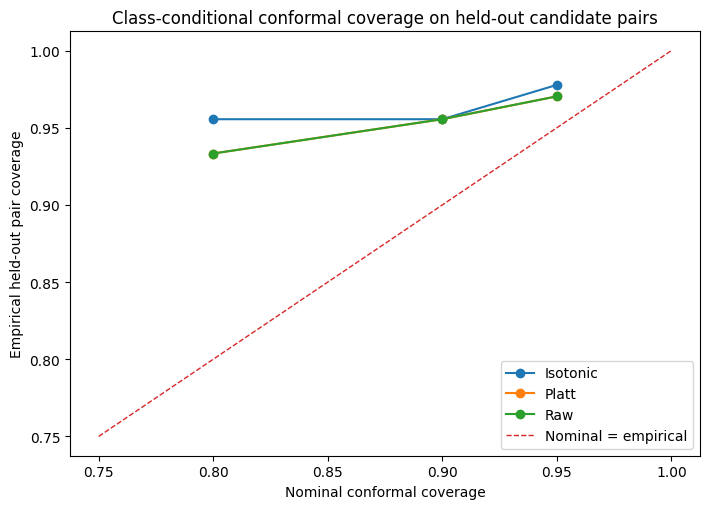


[6/6] Writing manifest...

PART J7A COMPLETE
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets

RETURN TO CHAT:
1. Console output from [2/6] through PART J7A COMPLETE
2. Table_J7A_02_conformal_pair_summary.csv
3. Table_J7A_04_conformal_target_level_summary.csv
4. Table_J7A_05_conformal_vs_probabilistic_uncertainty.csv (if created)
5. J7A_manifest.json


In [3]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J7A
Conformal Prediction and Calibration-Robust Uncertainty Sets

Purpose
-------
Address the pre-submission reviewer's request to connect the framework to
conformal set prediction and to test whether set-valued identity decisions with
coverage guarantees are feasible in the current frozen target-disjoint design.

Design
------
- Base scores: frozen MLP probabilities already exported in J1.
- Calibration set: frozen validation targets only.
- Test set: frozen held-out test targets only.
- Method: class-conditional (Mondrian) split conformal classification.
- Nonconformity score:
      a(x,y=1) = 1 - p(x)
      a(x,y=0) = p(x)
- Prediction set contains label y when its conformal p-value exceeds alpha.
- Target-level summaries:
      all candidate pairs singleton -> target fully resolved
      at least one {0,1} pair -> target has conformal ambiguity
      empty pair set -> diagnostic failure (should be rare/none)

This is a supplementary sensitivity analysis, not a replacement for the
probabilistic random-set framework.

No test-set tuning.
"""

from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 20261006
ALPHAS = [0.20, 0.10, 0.05]

# ------------------------------------------------------------
# Resolve Google Drive root robustly
# ------------------------------------------------------------
def resolve_root():
    candidates = [
        Path("/content/gdrive/MyDrive/tese_doutoral"),
        Path("/content/google_drive_real/MyDrive/tese_doutoral"),
        Path("/content/google_drive_jasist/MyDrive/tese_doutoral"),
        Path("/content/drive/MyDrive/tese_doutoral"),
    ]
    for c in candidates:
        if (
            c.exists()
            and (c/"runs/joi_entity_resolution_20261003").exists()
            and (c/"runs/jasist_identity_uncertainty_20261005").exists()
        ):
            print("Using Google Drive root:", c)
            return c

    from google.colab import drive
    mountpoint = Path("/content/google_drive_real")
    if mountpoint.exists() and any(mountpoint.iterdir()):
        mountpoint = Path("/content/google_drive_jasist")
    mountpoint.mkdir(parents=True, exist_ok=True)
    print("Mounting Google Drive at:", mountpoint)
    drive.mount(str(mountpoint))
    c = mountpoint/"MyDrive/tese_doutoral"
    if not c.exists():
        raise FileNotFoundError(c)
    return c

ROOT = resolve_root()
JOI = ROOT/"runs/joi_entity_resolution_20261003"
JASIST = ROOT/"runs/jasist_identity_uncertainty_20261005"

FEATURE_FRAME = (
    JOI/"06D_incumbent_aware_multievidence/tables/"
    "Table_06D_01_feature_frame.csv"
)
J1_TEST = (
    JASIST/"01_identity_uncertainty_calibration/tables/"
    "Table_J1_08_test_pair_uncertainty.csv"
)

OUT = JASIST/"07A_conformal_uncertainty_sets"
TABLES = OUT/"tables"
FIGURES = OUT/"figures"
ARTIFACTS = OUT/"artifacts"
for p in [TABLES,FIGURES,ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("="*100)
print("JASIST — PART J7A")
print("MONDRIAN SPLIT CONFORMAL UNCERTAINTY SETS")
print("="*100)
print("Output:", OUT)

# ------------------------------------------------------------
# Load frozen validation/test
# ------------------------------------------------------------
print("\n[1/6] Loading frozen validation and held-out test probabilities...")

feat = pd.read_csv(FEATURE_FRAME)
test = pd.read_csv(J1_TEST)

# J1 test table contains p_raw/p_platt/p_isotonic.
# Validation probabilities are not exported there, so obtain them from the
# J1 stage if present; otherwise fail loudly rather than re-fit a model here.
J1_PAIR_ALL_CANDIDATES = [
    JASIST/"01_identity_uncertainty_calibration/tables/Table_J1_09_all_pair_probabilities.csv",
    JASIST/"01_identity_uncertainty_calibration/tables/Table_J1_all_pair_probabilities.csv",
]

allprob = None
for p in J1_PAIR_ALL_CANDIDATES:
    if p.exists():
        allprob = pd.read_csv(p)
        print("Found all-pair probability export:", p)
        break

# If no all-pair export exists, recover validation probabilities from a saved
# J1 output only if probability columns are present in an existing table.
if allprob is None:
    candidates = list(
        (JASIST/"01_identity_uncertainty_calibration/tables").glob("*.csv")
    )
    for p in candidates:
        try:
            d = pd.read_csv(p)
        except Exception:
            continue
        needed = {"target_key","candidate_openalex_id","p_raw","p_platt","p_isotonic"}
        if needed.issubset(d.columns) and "split" in d.columns and d["split"].eq("validation").any():
            allprob = d
            print("Recovered validation probabilities from:", p)
            break

if allprob is None:
    print("\nNo saved validation-pair probabilities were found.")
    print("This J7A script will create a small deterministic recovery by re-running")
    print("the frozen J1 model specification in-place using exactly the saved train/")
    print("validation/test split and seed. No hyperparameter selection is performed.")

    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.neural_network import MLPClassifier

    FEATURES = [
        "f_exact_any","f_aini","f_name_sim","f_aff",
        "f_external_work_count","f_coauthor_id_overlap",
        "f_coauthor_name_overlap","f_coauthor_id_recall",
        "f_coauthor_name_recall","is_incumbent","exact_name_count_target",
        "is_unique_top_f_coauthor_id_overlap",
        "is_unique_top_f_aff","is_unique_top_f_name_sim",
    ]

    df = feat.copy()
    df = df[df["y_ref"].isin([0,1])].copy()
    df["split"] = df["split"].astype(str).str.lower()

    for f in FEATURES:
        df[f] = pd.to_numeric(df[f], errors="coerce").fillna(0.0)

    train = df[df["split"].eq("train")].copy()

    rng = np.random.default_rng(20261005)
    pos = train[train["y_ref"].eq(1)]
    neg = train[train["y_ref"].eq(0)]

    if len(pos) < len(neg):
        sampled = rng.choice(pos.index.to_numpy(), size=len(neg)-len(pos), replace=True)
        fit_train = pd.concat([train, train.loc[sampled]], ignore_index=True)
    elif len(neg) < len(pos):
        sampled = rng.choice(neg.index.to_numpy(), size=len(pos)-len(neg), replace=True)
        fit_train = pd.concat([train, train.loc[sampled]], ignore_index=True)
    else:
        fit_train = train.copy()

    mlp = Pipeline([
        ("scale", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(16,),
            alpha=0.0001,
            random_state=20261005,
            max_iter=5000,
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
        ))
    ])
    mlp.fit(fit_train[FEATURES], fit_train["y_ref"])

    allprob = df[[
        "target_key","candidate_openalex_id","target_name",
        "candidate_display_name","y_ref","split"
    ]].copy()
    allprob["p_raw"] = mlp.predict_proba(df[FEATURES])[:,1]

    # Reconstruct validation-fitted calibrators exactly as J1
    from sklearn.linear_model import LogisticRegression
    from sklearn.isotonic import IsotonicRegression

    valmask = df["split"].eq("validation")
    pval = np.clip(allprob.loc[valmask,"p_raw"].to_numpy(float),1e-6,1-1e-6)
    yval = df.loc[valmask,"y_ref"].to_numpy(int)

    Xlogit = np.log(pval/(1-pval)).reshape(-1,1)
    platt = LogisticRegression(C=1e6,solver="lbfgs",max_iter=5000,random_state=20261005)
    platt.fit(Xlogit,yval)

    pall = np.clip(allprob["p_raw"].to_numpy(float),1e-6,1-1e-6)
    allprob["p_platt"] = platt.predict_proba(
        np.log(pall/(1-pall)).reshape(-1,1)
    )[:,1]

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(pval,yval)
    allprob["p_isotonic"] = iso.predict(allprob["p_raw"].to_numpy(float))

    export = TABLES/"Table_J7A_00_recovered_all_pair_probabilities.csv"
    allprob.to_csv(export,index=False)
    print("Recovered frozen probabilities exported:", export)

val = allprob[allprob["split"].astype(str).str.lower().eq("validation")].copy()
tst = allprob[allprob["split"].astype(str).str.lower().eq("test")].copy()

print("Validation:", val["target_key"].nunique(), "targets |", len(val), "pairs")
print("Test:", tst["target_key"].nunique(), "targets |", len(tst), "pairs")

# ------------------------------------------------------------
# Mondrian split conformal
# ------------------------------------------------------------
print("\n[2/6] Computing class-conditional conformity distributions...")

def nc_score(p, y):
    p = np.asarray(p,float)
    y = np.asarray(y,int)
    return np.where(y==1,1-p,p)

def conformal_pvalue(score, cal_scores):
    cal_scores = np.asarray(cal_scores,float)
    return (1 + np.sum(cal_scores >= score)) / (len(cal_scores)+1)

calibration_names = ["raw","platt","isotonic"]
pcols = {"raw":"p_raw","platt":"p_platt","isotonic":"p_isotonic"}

result_rows = []
summary_rows = []
target_rows = []

for cal in calibration_names:
    pcol = pcols[cal]
    val_scores = nc_score(val[pcol], val["y_ref"])

    cal0 = val_scores[val["y_ref"].to_numpy(int)==0]
    cal1 = val_scores[val["y_ref"].to_numpy(int)==1]

    print(f"{cal}: calibration n0={len(cal0)}, n1={len(cal1)}")

    for alpha in ALPHAS:
        local = []

        for idx,r in tst.iterrows():
            p = float(r[pcol])
            s0 = p
            s1 = 1-p

            pv0 = conformal_pvalue(s0,cal0)
            pv1 = conformal_pvalue(s1,cal1)

            labels = []
            if pv0 > alpha:
                labels.append(0)
            if pv1 > alpha:
                labels.append(1)

            true_y = int(r["y_ref"])
            covered = int(true_y in labels)

            local.append({
                "calibration":cal,
                "alpha":alpha,
                "target_key":r["target_key"],
                "candidate_openalex_id":r["candidate_openalex_id"],
                "y_ref":true_y,
                "p_match":p,
                "pvalue_label0":pv0,
                "pvalue_label1":pv1,
                "prediction_set":"{" + ",".join(map(str,labels)) + "}",
                "set_size":len(labels),
                "covered":covered,
            })

        ld = pd.DataFrame(local)
        result_rows.append(ld)

        summary_rows.append({
            "calibration":cal,
            "alpha":alpha,
            "nominal_coverage":1-alpha,
            "empirical_pair_coverage":ld["covered"].mean(),
            "mean_prediction_set_size":ld["set_size"].mean(),
            "singleton_rate":(ld["set_size"]==1).mean(),
            "ambiguous_rate":(ld["set_size"]==2).mean(),
            "empty_rate":(ld["set_size"]==0).mean(),
        })

        # target-level operational summary
        tmp = ld.merge(
            tst[["target_key","candidate_openalex_id","target_name"]],
            on=["target_key","candidate_openalex_id"],how="left"
        )

        for tk,g in tmp.groupby("target_key"):
            pair_sets = list(g["prediction_set"])
            all_singleton = bool((g["set_size"]==1).all())
            any_ambiguous = bool((g["set_size"]==2).any())
            any_empty = bool((g["set_size"]==0).any())
            target_all_pairs_covered = bool((g["covered"]==1).all())

            # identity set implied by singleton-positive decisions only
            positive_ids = set(
                g.loc[g["prediction_set"].eq("{1}"),"candidate_openalex_id"].astype(str)
            )
            ref_ids = set(
                g.loc[g["y_ref"].eq(1),"candidate_openalex_id"].astype(str)
            )

            target_rows.append({
                "calibration":cal,
                "alpha":alpha,
                "target_key":tk,
                "target_name":g.iloc[0]["target_name"],
                "all_pairs_singleton":all_singleton,
                "any_ambiguous_pair":any_ambiguous,
                "any_empty_pair":any_empty,
                "target_all_pairs_covered":target_all_pairs_covered,
                "singleton_positive_exact_identity_set":int(positive_ids==ref_ids),
                "n_singleton_positive":len(positive_ids),
                "reference_set_size":len(ref_ids),
            })

results = pd.concat(result_rows,ignore_index=True)
summary = pd.DataFrame(summary_rows)
targets = pd.DataFrame(target_rows)

results.to_csv(TABLES/"Table_J7A_01_conformal_pair_sets.csv",index=False)
summary.to_csv(TABLES/"Table_J7A_02_conformal_pair_summary.csv",index=False)
targets.to_csv(TABLES/"Table_J7A_03_conformal_target_summary.csv",index=False)

print("\nPair-level conformal summary:")
print(summary.to_string(index=False))

# ------------------------------------------------------------
# Target-level conformal summaries
# ------------------------------------------------------------
print("\n[3/6] Summarizing target-level set-valued resolution...")

target_summary = (
    targets.groupby(["calibration","alpha"])
    .agg(
        targets=("target_key","count"),
        all_pairs_singleton_rate=("all_pairs_singleton","mean"),
        any_ambiguous_pair_rate=("any_ambiguous_pair","mean"),
        any_empty_pair_rate=("any_empty_pair","mean"),
        target_joint_coverage=("target_all_pairs_covered","mean"),
        singleton_positive_exact_set_rate=(
            "singleton_positive_exact_identity_set","mean"
        )
    )
    .reset_index()
)

target_summary.to_csv(
    TABLES/"Table_J7A_04_conformal_target_level_summary.csv",index=False
)

print(target_summary.to_string(index=False))

# ------------------------------------------------------------
# Compare with existing selective abstention concept
# ------------------------------------------------------------
print("\n[4/6] Comparing conformal ambiguity with probabilistic abstention...")

# Use J6 target uncertainty table if available
J6_AUDIT = (
    JASIST/"06_reviewer_driven_robustness/tables/"
    "Table_J6_01_crosswalk_mapped_unmapped_target_audit.csv"
)

compare_rows = []
if J6_AUDIT.exists():
    j6 = pd.read_csv(J6_AUDIT)
    iso10 = targets[
        targets["calibration"].eq("isotonic")
        & targets["alpha"].eq(0.10)
    ].merge(
        j6[[
            "target_key","expected_hamming_uncertainty",
            "set_entropy_bits","prob_MAP_identity_set"
        ]],
        on="target_key",how="left"
    )

    groups = [
        ("CONFORMAL_AMBIGUOUS",iso10["any_ambiguous_pair"]),
        ("CONFORMAL_SINGLETON",~iso10["any_ambiguous_pair"]),
    ]

    for label,mask in groups:
        g = iso10[mask]
        compare_rows.append({
            "group":label,
            "targets":len(g),
            "mean_expected_hamming_uncertainty":
                g["expected_hamming_uncertainty"].mean(),
            "mean_set_entropy_bits":
                g["set_entropy_bits"].mean(),
            "mean_prob_MAP_identity_set":
                g["prob_MAP_identity_set"].mean(),
        })

compare = pd.DataFrame(compare_rows)
if len(compare):
    compare.to_csv(
        TABLES/"Table_J7A_05_conformal_vs_probabilistic_uncertainty.csv",
        index=False
    )
    print(compare.to_string(index=False))
else:
    print("J6 audit not found; comparison skipped.")

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
print("\n[5/6] Generating conformal coverage-efficiency figure...")

fig,ax = plt.subplots(figsize=(7.2,5.2))
for cal,g in summary.groupby("calibration"):
    gg = g.sort_values("nominal_coverage")
    ax.plot(
        gg["nominal_coverage"],
        gg["empirical_pair_coverage"],
        marker="o",
        label=cal.capitalize()
    )
ax.plot([0.75,1.0],[0.75,1.0],"--",linewidth=1,label="Nominal = empirical")
ax.set_xlabel("Nominal conformal coverage")
ax.set_ylabel("Empirical held-out pair coverage")
ax.set_title("Class-conditional conformal coverage on held-out candidate pairs")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES/"Figure_J7A_01_conformal_coverage.png",
    dpi=300,bbox_inches="tight"
)
fig.savefig(
    FIGURES/"Figure_J7A_01_conformal_coverage.pdf",
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# Manifest
# ------------------------------------------------------------
print("\n[6/6] Writing manifest...")

manifest = {
    "study":"JASIST identity uncertainty",
    "part":"J7A",
    "method":"class-conditional Mondrian split conformal classification",
    "calibration_unit":"candidate pairs from frozen validation targets",
    "test_unit":"candidate pairs from frozen held-out test targets",
    "alphas":ALPHAS,
    "calibrations":calibration_names,
    "nonconformity":{
        "label_1":"1-p(match)",
        "label_0":"p(match)"
    },
    "scope_note":
        "Supplementary feasibility/sensitivity analysis. Pair-level conformal coverage "
        "does not imply simultaneous target-level coverage because candidate pairs within "
        "a target are dependent.",
    "no_test_tuning":True,
    "outputs":{
        "tables":[p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures":[p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(ARTIFACTS/"J7A_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*100)
print("PART J7A COMPLETE")
print("="*100)
print("Output:",OUT)
print("\nRETURN TO CHAT:")
print("1. Console output from [2/6] through PART J7A COMPLETE")
print("2. Table_J7A_02_conformal_pair_summary.csv")
print("3. Table_J7A_04_conformal_target_level_summary.csv")
print("4. Table_J7A_05_conformal_vs_probabilistic_uncertainty.csv (if created)")
print("5. J7A_manifest.json")
print("="*100)


Searching for the J7A outputs in mounted Drive roots...
 - /content/google_drive_real/MyDrive/tese_doutoral | exists: True | J7A file: True
Using Google Drive root containing J7A outputs: /content/google_drive_real/MyDrive/tese_doutoral
JASIST — PART J7A-R
CONFORMAL AMBIGUITY DIAGNOSTICS AT ALPHA=.05
PAIRSETS: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets/tables/Table_J7A_01_conformal_pair_sets.csv
PAIRSETS exists: True
TARGET_SUMMARY: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets/tables/Table_J7A_03_conformal_target_summary.csv
TARGET_SUMMARY exists: True
J6_AUDIT: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/06_reviewer_driven_robustness/tables/Table_J6_01_crosswalk_mapped_unmapped_target_audit.csv
J6_AUDIT exists: True

Conformal ambiguity vs probabilistic uncertainty:
                   

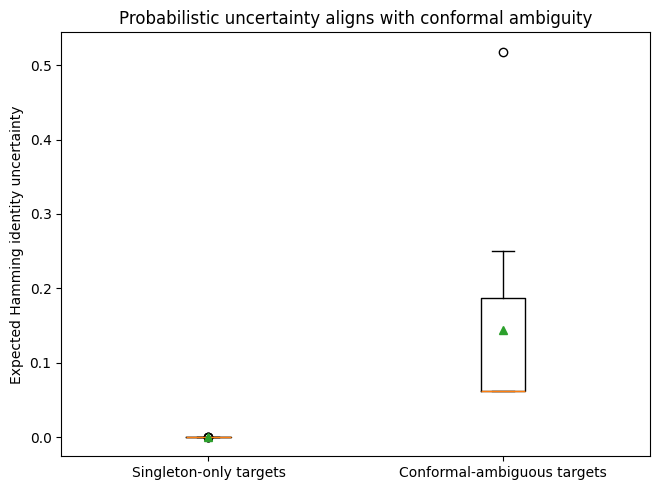


PART J7A-R COMPLETE
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07A_conformal_uncertainty_sets/recovery_alpha05
RETURN TO CHAT:
1. Console output
2. Table_J7AR_01_conformal_ambiguity_vs_probabilistic_uncertainty.csv
3. Table_J7AR_02_conformal_name_ambiguity_overlap.csv


In [5]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J7A-R
Conformal sensitivity recovery: use alpha=.05 for ambiguity diagnostics

Why this recovery?
------------------
The original J7A comparison used isotonic alpha=.10. At alpha=.10 there were
no ambiguous {0,1} conformal pair sets; uncertainty appeared instead through
empty sets. That made the "conformal ambiguous vs probabilistic uncertainty"
comparison uninformative.

At alpha=.05:
- empirical pair coverage is high,
- empty-set rate is zero,
- ambiguous sets are present,
so alpha=.05 is the appropriate operating point for examining whether
conformal ambiguity aligns with the probabilistic uncertainty measures.

This script reuses saved J7A outputs. It does NOT refit any model.
"""

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Resolve the SAME Google Drive mount that contains J7A outputs
# ------------------------------------------------------------
def resolve_root():
    candidates = [
        Path("/content/google_drive_real/MyDrive/tese_doutoral"),
        Path("/content/google_drive_jasist/MyDrive/tese_doutoral"),
        Path("/content/gdrive/MyDrive/tese_doutoral"),
        Path("/content/drive/MyDrive/tese_doutoral"),
    ]

    required_rel = (
        Path("runs/jasist_identity_uncertainty_20261005/")
        / "07A_conformal_uncertainty_sets/tables/"
        / "Table_J7A_01_conformal_pair_sets.csv"
    )

    print("Searching for the J7A outputs in mounted Drive roots...")

    for c in candidates:
        target = c / required_rel
        print(" -", c, "| exists:", c.exists(), "| J7A file:", target.exists())
        if c.exists() and target.exists():
            print("Using Google Drive root containing J7A outputs:", c)
            return c

    # If no predefined mount works, search /content for mounted MyDrive trees.
    print("Predefined mountpoints did not contain the J7A file. Searching /content...")
    for mydrive in Path("/content").glob("*/MyDrive"):
        c = mydrive / "tese_doutoral"
        target = c / required_rel
        print(" - discovered:", c, "| J7A file:", target.exists())
        if target.exists():
            print("Using discovered Google Drive root:", c)
            return c

    raise FileNotFoundError(
        "The saved J7A outputs were not found in any mounted Google Drive root. "
        "The J7A analysis previously wrote to /content/google_drive_real/MyDrive/"
        "tese_doutoral, so mount the same Drive in this runtime or rerun J7A only "
        "after confirming the real mount. No statistical analysis has been rerun."
    )

ROOT = resolve_root()
JASIST = ROOT/"runs/jasist_identity_uncertainty_20261005"

J7A = JASIST/"07A_conformal_uncertainty_sets"
J6 = JASIST/"06_reviewer_driven_robustness"

PAIRSETS = J7A/"tables/Table_J7A_01_conformal_pair_sets.csv"
TARGET_SUMMARY = J7A/"tables/Table_J7A_03_conformal_target_summary.csv"
J6_AUDIT = J6/"tables/Table_J6_01_crosswalk_mapped_unmapped_target_audit.csv"

OUT = J7A/"recovery_alpha05"
TABLES = OUT/"tables"
FIGURES = OUT/"figures"
ARTIFACTS = OUT/"artifacts"
for p in [TABLES,FIGURES,ARTIFACTS]:
    p.mkdir(parents=True,exist_ok=True)

print("="*96)
print("JASIST — PART J7A-R")
print("CONFORMAL AMBIGUITY DIAGNOSTICS AT ALPHA=.05")
print("="*96)
print("PAIRSETS:", PAIRSETS)
print("PAIRSETS exists:", PAIRSETS.exists())
print("TARGET_SUMMARY:", TARGET_SUMMARY)
print("TARGET_SUMMARY exists:", TARGET_SUMMARY.exists())
print("J6_AUDIT:", J6_AUDIT)
print("J6_AUDIT exists:", J6_AUDIT.exists())

pairsets = pd.read_csv(PAIRSETS)
targets = pd.read_csv(TARGET_SUMMARY)
j6 = pd.read_csv(J6_AUDIT)

# Isotonic alpha .05
pa = pairsets[
    pairsets["calibration"].eq("isotonic")
    & np.isclose(pairsets["alpha"],0.05)
].copy()

ta = targets[
    targets["calibration"].eq("isotonic")
    & np.isclose(targets["alpha"],0.05)
].copy()

if len(pa)==0 or len(ta)==0:
    raise RuntimeError("Saved isotonic alpha=.05 conformal outputs not found.")

# Merge probabilistic uncertainty
cols = [
    "target_key","expected_hamming_uncertainty","set_entropy_bits",
    "prob_MAP_identity_set","exact_name_ambiguous","n_candidates",
    "exact_set_recovery","set_jaccard"
]
m = ta.merge(j6[cols],on="target_key",how="left")

m["conformal_ambiguous_target"] = m["any_ambiguous_pair"].astype(bool)

# Summaries
rows = []
for label,mask in [
    ("CONFORMAL_AMBIGUOUS",m["conformal_ambiguous_target"]),
    ("CONFORMAL_SINGLETON_ONLY",~m["conformal_ambiguous_target"])
]:
    g = m[mask]
    rows.append({
        "group":label,
        "targets":len(g),
        "mean_expected_hamming_uncertainty":
            g["expected_hamming_uncertainty"].mean(),
        "median_expected_hamming_uncertainty":
            g["expected_hamming_uncertainty"].median(),
        "mean_set_entropy_bits":g["set_entropy_bits"].mean(),
        "mean_prob_MAP_identity_set":g["prob_MAP_identity_set"].mean(),
        "exact_name_ambiguous_rate":g["exact_name_ambiguous"].mean(),
        "mean_candidates":g["n_candidates"].mean(),
        "exact_set_recovery_rate":g["exact_set_recovery"].mean(),
        "mean_set_jaccard":g["set_jaccard"].mean(),
    })

summary = pd.DataFrame(rows)
summary.to_csv(
    TABLES/"Table_J7AR_01_conformal_ambiguity_vs_probabilistic_uncertainty.csv",
    index=False
)

# Target-level overlap diagnostics
amb_targets = set(
    m.loc[m["conformal_ambiguous_target"],"target_key"].astype(str)
)
name_amb_targets = set(
    m.loc[m["exact_name_ambiguous"].astype(bool),"target_key"].astype(str)
)

intersection = len(amb_targets & name_amb_targets)
union = len(amb_targets | name_amb_targets)

overlap = pd.DataFrame([{
    "conformal_ambiguous_targets":len(amb_targets),
    "exact_name_ambiguous_targets":len(name_amb_targets),
    "intersection":intersection,
    "jaccard_overlap":intersection/union if union else 1.0,
    "conformal_ambiguity_precision_for_exact_name_ambiguity":
        intersection/len(amb_targets) if amb_targets else np.nan,
    "conformal_ambiguity_recall_for_exact_name_ambiguity":
        intersection/len(name_amb_targets) if name_amb_targets else np.nan,
}])

overlap.to_csv(
    TABLES/"Table_J7AR_02_conformal_name_ambiguity_overlap.csv",
    index=False
)

# Pair-level uncertainty set structure
pair_summary = pd.DataFrame([{
    "pairs":len(pa),
    "empirical_pair_coverage":pa["covered"].mean(),
    "singleton_rate":(pa["set_size"]==1).mean(),
    "ambiguous_rate":(pa["set_size"]==2).mean(),
    "empty_rate":(pa["set_size"]==0).mean(),
    "mean_prediction_set_size":pa["set_size"].mean(),
}])

pair_summary.to_csv(
    TABLES/"Table_J7AR_03_isotonic_alpha05_pair_summary.csv",
    index=False
)

print("\nConformal ambiguity vs probabilistic uncertainty:")
print(summary.to_string(index=False))
print("\nOverlap with exact-name ambiguity:")
print(overlap.to_string(index=False))
print("\nPair-level operating point:")
print(pair_summary.to_string(index=False))

# Figure: probabilistic uncertainty by conformal ambiguity
fig,ax = plt.subplots(figsize=(6.7,5.0))
groups = [
    m.loc[~m["conformal_ambiguous_target"],"expected_hamming_uncertainty"].to_numpy(),
    m.loc[m["conformal_ambiguous_target"],"expected_hamming_uncertainty"].to_numpy(),
]
ax.boxplot(
    groups,
    labels=["Singleton-only targets","Conformal-ambiguous targets"],
    showmeans=True
)
ax.set_ylabel("Expected Hamming identity uncertainty")
ax.set_title("Probabilistic uncertainty aligns with conformal ambiguity")
fig.tight_layout()
fig.savefig(
    FIGURES/"Figure_J7AR_01_conformal_vs_hamming_uncertainty.png",
    dpi=300,bbox_inches="tight"
)
fig.savefig(
    FIGURES/"Figure_J7AR_01_conformal_vs_hamming_uncertainty.pdf",
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

manifest = {
    "part":"J7A-R",
    "purpose":"Correct conformal ambiguity comparison to alpha=.05",
    "calibration":"isotonic",
    "alpha":0.05,
    "reason":
        "alpha=.05 has no empty pair sets and yields nonzero ambiguous prediction sets; "
        "alpha=.10 had no ambiguous sets and was therefore uninformative for this comparison.",
    "no_model_refit":True,
    "outputs":{
        "tables":[p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures":[p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(ARTIFACTS/"J7AR_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest,f,indent=2,ensure_ascii=False)

print("\n"+"="*96)
print("PART J7A-R COMPLETE")
print("="*96)
print("Output:",OUT)
print("RETURN TO CHAT:")
print("1. Console output")
print("2. Table_J7AR_01_conformal_ambiguity_vs_probabilistic_uncertainty.csv")
print("3. Table_J7AR_02_conformal_name_ambiguity_overlap.csv")
print("="*96)


Using Google Drive root: /content/google_drive_real/MyDrive/tese_doutoral
JASIST — PART J7B
EXTERNAL VALIDATION ON S2AND-QIAN
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07B_external_validation_S2AND_qian

[1/10] Checking Python dependencies...
Installing boto3

[2/10] Locating and downloading the official QIAN Arrow benchmark subset...
Objects available under qian prefix: 12
Downloading: s2and-release-arrow/qian/manifest.json
Manifest keys: ['cluster_count', 'conversion_kind', 'dataset', 'name_counts_index', 'name_tuples', 'paper_count', 'paths', 'physical_layout', 'raw_planner_batch_indexes', 'schema', 'signature_count', 'source_dir', 'specter', 'timings_seconds', 'validation']
Downloading: s2and-release-arrow/qian/signatures.arrow
Downloading: s2and-release-arrow/qian/papers.arrow
Downloading: s2and-release-arrow/qian/paper_authors.arrow
Downloading: s2and-release-arrow/qian/qian_clusters.json
Downloaded/resolved files:
 - signa

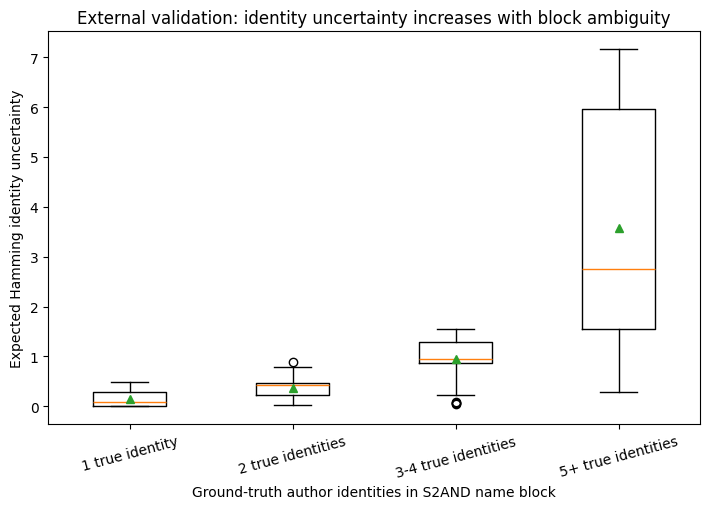


[10/10] Writing manifest...

PART J7B COMPLETE
Output: /content/google_drive_real/MyDrive/tese_doutoral/runs/jasist_identity_uncertainty_20261005/07B_external_validation_S2AND_qian

RETURN TO CHAT:
1. Console output from [3/10] through PART J7B COMPLETE
2. Table_J7B_03_external_pair_model_test_metrics.csv
3. Table_J7B_06_external_uncertainty_by_block_ambiguity.csv
4. Table_J7B_07_external_ambiguity_uncertainty_association.csv
5. J7B_manifest.json


In [6]:

# -*- coding: utf-8 -*-
"""
JASIST — PART J7B
External benchmark validation on the public S2AND-QIAN benchmark

Goal
----
Address the pre-submission reviewer's request for broader external validation
using a modern curated author-name-disambiguation benchmark.

This analysis is intentionally framework-oriented rather than a reproduction
of the main Brazilian/OpenAlex resolver. It asks whether the central empirical
pattern generalizes in an independent benchmark:

    harder / more ambiguous author blocks -> higher identity uncertainty
    and lower exact identity-set recovery.

Data source
-----------
Official public S2AND Arrow release, dataset: qian.
Only the qian files required for metadata and labels are downloaded.
SPECTER embeddings are NOT downloaded.

External-validation design
--------------------------
1) download qian manifest, signatures, papers, paper_authors, and eval clusters;
2) create block-disjoint train/validation/test partitions;
3) build a lightweight metadata-only pairwise same-author model from:
   name, affiliation, coauthor, and temporal evidence;
4) fit calibration on validation only;
5) construct one external "target" per true author cluster in the held-out blocks;
6) treat true clusters in the same block as candidate identities;
7) aggregate pairwise probabilities to candidate-cluster membership scores;
8) evaluate exact-set recovery and uncertainty as a function of block ambiguity.

This is an EXTERNAL REPLICATION of the uncertainty framework, not a claim that
the lightweight external classifier is a state-of-the-art S2AND resolver.

No main-study model is re-tuned.
"""

from pathlib import Path
from collections import defaultdict
import json, re, unicodedata, math, warnings, os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 20261006
RNG = np.random.default_rng(SEED)

MAX_PAIRS_PER_CLASS_PER_BLOCK = 200
MAX_TRAIN_PAIRS = 80000
MAX_VAL_PAIRS = 20000
MAX_TEST_PAIRS = 30000
MIN_BLOCK_SIZE = 2

# ------------------------------------------------------------
# Resolve Drive root
# ------------------------------------------------------------
def resolve_root():
    candidates = [
        Path("/content/google_drive_real/MyDrive/tese_doutoral"),
        Path("/content/google_drive_jasist/MyDrive/tese_doutoral"),
        Path("/content/gdrive/MyDrive/tese_doutoral"),
        Path("/content/drive/MyDrive/tese_doutoral"),
    ]
    for c in candidates:
        if c.exists() and (c/"runs/jasist_identity_uncertainty_20261005").exists():
            print("Using Google Drive root:", c)
            return c

    try:
        from google.colab import drive
    except Exception as e:
        raise RuntimeError(f"Google Drive unavailable: {e}")

    mp = Path("/content/google_drive_external")
    if mp.exists() and any(mp.iterdir()):
        mp = Path("/content/google_drive_external2")
    mp.mkdir(parents=True, exist_ok=True)
    drive.mount(str(mp))
    c = mp/"MyDrive/tese_doutoral"
    if not c.exists():
        raise FileNotFoundError(c)
    return c

ROOT = resolve_root()
JASIST = ROOT/"runs/jasist_identity_uncertainty_20261005"
OUT = JASIST/"07B_external_validation_S2AND_qian"
DATA = OUT/"data_qian"
TABLES = OUT/"tables"
FIGURES = OUT/"figures"
ARTIFACTS = OUT/"artifacts"
for p in [DATA,TABLES,FIGURES,ARTIFACTS]:
    p.mkdir(parents=True, exist_ok=True)

print("="*110)
print("JASIST — PART J7B")
print("EXTERNAL VALIDATION ON S2AND-QIAN")
print("="*110)
print("Output:", OUT)

# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------
print("\n[1/10] Checking Python dependencies...")

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except Exception:
        pkg = pip_name or import_name
        print("Installing", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return __import__(import_name)

boto3 = ensure_package("boto3")
pa = ensure_package("pyarrow")
sklearn = ensure_package("sklearn", "scikit-learn")

from botocore import UNSIGNED
from botocore.config import Config
import pyarrow as pa
import pyarrow.ipc as ipc
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    log_loss, precision_score, recall_score, f1_score,
    matthews_corrcoef
)

# ------------------------------------------------------------
# Download only required QIAN files
# ------------------------------------------------------------
print("\n[2/10] Locating and downloading the official QIAN Arrow benchmark subset...")

BUCKET = "ai2-s2-research-public"
PREFIX = "s2and-release-arrow/qian/"
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

# list qian objects
objects = []
token = None
while True:
    kwargs = {"Bucket":BUCKET, "Prefix":PREFIX, "MaxKeys":1000}
    if token:
        kwargs["ContinuationToken"] = token
    resp = s3.list_objects_v2(**kwargs)
    objects.extend(resp.get("Contents",[]))
    if not resp.get("IsTruncated"):
        break
    token = resp["NextContinuationToken"]

if not objects:
    raise RuntimeError(
        "No objects found under the official S2AND qian Arrow prefix. "
        "Check internet access or the public release prefix."
    )

keys = [o["Key"] for o in objects]
print("Objects available under qian prefix:", len(keys))

# Download manifest first
manifest_key = next((k for k in keys if k.endswith("/manifest.json")), None)
if manifest_key is None:
    raise RuntimeError("QIAN manifest.json not found in S2AND public prefix.")

def download_key(key, local_path):
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if not local_path.exists():
        print("Downloading:", key)
        s3.download_file(BUCKET, key, str(local_path))
    return local_path

manifest_local = download_key(manifest_key, DATA/"manifest.json")
manifest = json.loads(manifest_local.read_text())

print("Manifest keys:", list(manifest.keys()))

# Resolve paths declared in manifest; download only required metadata/labels.
paths = manifest.get("paths", manifest)

wanted_manifest_keys = [
    "signatures","papers","paper_authors","clusters"
]

resolved = {}

for wk in wanted_manifest_keys:
    val = paths.get(wk)
    if val is None:
        # fallback search by filename keyword
        cand = [k for k in keys if wk in Path(k).name.lower()]
        if wk=="clusters":
            cand = [k for k in keys if "cluster" in Path(k).name.lower() and k.endswith((".json",".jsonl"))]
        if cand:
            key = sorted(cand, key=len)[0]
        else:
            print("WARNING: could not locate", wk)
            continue
    else:
        rel = str(val).replace("\\","/")
        # manifest may store relative qian-local path
        key = PREFIX + rel.lstrip("/")
        if key not in keys:
            # some manifest paths already include qian/ or release root
            alternatives = [
                k for k in keys
                if Path(k).name == Path(rel).name
            ]
            if alternatives:
                key = alternatives[0]
            else:
                print("WARNING: manifest path not found on S3:", wk, rel)
                continue

    local = DATA/Path(key).name
    resolved[wk] = download_key(key, local)

print("Downloaded/resolved files:")
for k,v in resolved.items():
    print(" -",k,":",v)

for req in ["signatures","clusters"]:
    if req not in resolved:
        raise RuntimeError(f"Required QIAN artifact missing: {req}")

# ------------------------------------------------------------
# Arrow / JSON readers
# ------------------------------------------------------------
print("\n[3/10] Reading QIAN signatures and ground-truth clusters...")

def read_arrow(path):
    with pa.memory_map(str(path),"r") as source:
        return ipc.open_file(source).read_all()

sig_table = read_arrow(resolved["signatures"])
sig_rows = sig_table.to_pylist()
print("Signature rows:", len(sig_rows))
print("Signature columns:", sig_table.column_names)

papers_rows = []
if "papers" in resolved:
    pt = read_arrow(resolved["papers"])
    papers_rows = pt.to_pylist()
    print("Paper rows:", len(papers_rows))
    print("Paper columns:", pt.column_names)

paper_auth_rows = []
if "paper_authors" in resolved:
    pat = read_arrow(resolved["paper_authors"])
    paper_auth_rows = pat.to_pylist()
    print("Paper-author rows:", len(paper_auth_rows))
    print("Paper-author columns:", pat.column_names)

# flexible cluster JSON loader
cluster_obj = json.loads(Path(resolved["clusters"]).read_text())

cluster_to_sigs = {}

def ingest_cluster(cid, val):
    sigs = None
    if isinstance(val, list):
        sigs = val
    elif isinstance(val, dict):
        for key in ["signature_ids","signatures","signature_id","sigs"]:
            if key in val:
                sigs = val[key]
                break
    if sigs is None:
        return
    if not isinstance(sigs, list):
        sigs = [sigs]
    cluster_to_sigs[str(cid)] = [str(x) for x in sigs]

if isinstance(cluster_obj, dict):
    for cid,val in cluster_obj.items():
        ingest_cluster(cid,val)
elif isinstance(cluster_obj, list):
    for i,val in enumerate(cluster_obj):
        if isinstance(val, dict):
            cid = val.get("cluster_id", val.get("id", i))
            ingest_cluster(cid,val)

if not cluster_to_sigs:
    raise RuntimeError(
        "Could not parse S2AND cluster JSON. "
        f"Top-level type={type(cluster_obj)}"
    )

sig_to_cluster = {}
for cid,sigs in cluster_to_sigs.items():
    for sid in sigs:
        sig_to_cluster[str(sid)] = str(cid)

print("Ground-truth clusters:", len(cluster_to_sigs))
print("Labeled signatures:", len(sig_to_cluster))

# ------------------------------------------------------------
# Normalize schema
# ------------------------------------------------------------
print("\n[4/10] Normalizing signature metadata and author blocks...")

def norm(x):
    if x is None:
        return ""
    s = unicodedata.normalize("NFKD",str(x))
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+"," ",s)
    return re.sub(r"\s+"," ",s).strip()

def flatten_strings(x):
    if x is None:
        return []
    if isinstance(x,str):
        return [x]
    if isinstance(x,(int,float)):
        return [str(x)]
    if isinstance(x,list):
        out=[]
        for y in x:
            out.extend(flatten_strings(y))
        return out
    if isinstance(x,dict):
        out=[]
        for y in x.values():
            out.extend(flatten_strings(y))
        return out
    return [str(x)]

def get_nested(d, keys, default=None):
    cur=d
    for k in keys:
        if not isinstance(cur,dict) or k not in cur:
            return default
        cur=cur[k]
    return cur

# Paper lookup
paper_by_id = {}
for r in papers_rows:
    pid = r.get("paper_id", r.get("id"))
    if pid is not None:
        paper_by_id[str(pid)] = r

# Coauthor lookup from paper_authors; flexible name fields
coauthors_by_paper = defaultdict(list)
for r in paper_auth_rows:
    pid = r.get("paper_id", r.get("id"))
    if pid is None:
        continue
    name = (
        r.get("author_name")
        or r.get("name")
        or r.get("display_name")
        or get_nested(r,["author","name"])
    )
    if name:
        coauthors_by_paper[str(pid)].append(norm(name))

norm_rows=[]

for r in sig_rows:
    sid = r.get("signature_id", r.get("id"))
    if sid is None:
        continue
    sid=str(sid)
    if sid not in sig_to_cluster:
        continue

    info = r.get("author_info",{})
    if not isinstance(info,dict):
        info={}

    pid = r.get("paper_id", info.get("paper_id"))
    pid = str(pid) if pid is not None else ""

    block = (
        r.get("author_block")
        or r.get("block")
        or info.get("block")
        or ""
    )

    first = r.get("first", info.get("first",""))
    middle = r.get("middle", info.get("middle",""))
    last = r.get("last", info.get("last",""))
    suffix = r.get("suffix", info.get("suffix",""))
    name = " ".join(
        [str(x) for x in [first,middle,last,suffix] if x not in [None,""]]
    ).strip()

    if not name:
        name = (
            r.get("author_name")
            or r.get("display_name")
            or info.get("author_name")
            or info.get("name")
            or ""
        )

    aff = (
        r.get("affiliations")
        or info.get("affiliations")
        or []
    )
    aff_text = " ".join(flatten_strings(aff))

    paper = paper_by_id.get(pid,{})
    year = paper.get("year", np.nan)
    title = paper.get("title","") or ""

    coauthors = [
        x for x in coauthors_by_paper.get(pid,[])
        if x and x != norm(name)
    ]

    norm_rows.append({
        "signature_id":sid,
        "cluster_id":sig_to_cluster[sid],
        "block":str(block),
        "name":norm(name),
        "affiliation":norm(aff_text),
        "paper_id":pid,
        "year":pd.to_numeric(year,errors="coerce"),
        "title":norm(title),
        "coauthors":coauthors,
    })

sig = pd.DataFrame(norm_rows)

if sig.empty:
    raise RuntimeError("No labeled QIAN signatures could be normalized.")

# If block missing, derive from normalized last + first initial
if (sig["block"].astype(str).str.len()==0).all():
    def derive_block(name):
        toks=name.split()
        return (toks[-1] + " " + toks[0][:1]) if toks else ""
    sig["block"]=sig["name"].map(derive_block)

sig.to_pickle(ARTIFACTS/"qian_normalized_signatures.pkl")

print("Normalized labeled signatures:",len(sig))
print("Blocks:",sig["block"].nunique())
print("True clusters:",sig["cluster_id"].nunique())

# ------------------------------------------------------------
# Block-disjoint split
# ------------------------------------------------------------
print("\n[5/10] Creating block-disjoint external train/validation/test split...")

block_sizes = sig.groupby("block").size()
blocks = block_sizes[block_sizes>=MIN_BLOCK_SIZE].index.to_numpy()
RNG.shuffle(blocks)

n=len(blocks)
n_train=int(round(.60*n))
n_val=int(round(.20*n))

train_blocks=set(blocks[:n_train])
val_blocks=set(blocks[n_train:n_train+n_val])
test_blocks=set(blocks[n_train+n_val:])

split_map={}
for b in train_blocks: split_map[b]="train"
for b in val_blocks: split_map[b]="validation"
for b in test_blocks: split_map[b]="test"

sig["split"]=sig["block"].map(split_map)
sig=sig[sig["split"].notna()].copy()

print(
    sig.groupby("split")
    .agg(signatures=("signature_id","count"),
         blocks=("block","nunique"),
         clusters=("cluster_id","nunique"))
    .to_string()
)

# ------------------------------------------------------------
# Pair features
# ------------------------------------------------------------
print("\n[6/10] Building block-local labeled pairs...")

def tokens(s):
    return set(str(s).split())

def jaccard(a,b):
    A,B=tokens(a),tokens(b)
    if not A or not B:
        return 0.0
    return len(A&B)/len(A|B)

def overlap_min(a,b):
    A,B=tokens(a),tokens(b)
    if not A or not B:
        return 0.0
    return len(A&B)/min(len(A),len(B))

def first_initial(name):
    t=str(name).split()
    return t[0][0] if t and t[0] else ""

def last_token(name):
    t=str(name).split()
    return t[-1] if t else ""

def pair_features(a,b):
    ya=a["year"]; yb=b["year"]
    year_gap = abs(float(ya)-float(yb)) if pd.notna(ya) and pd.notna(yb) else 20.0
    coA=set(a["coauthors"]); coB=set(b["coauthors"])
    co_j = len(coA&coB)/len(coA|coB) if coA and coB else 0.0

    return [
        jaccard(a["name"],b["name"]),
        overlap_min(a["name"],b["name"]),
        float(first_initial(a["name"])==first_initial(b["name"]) and first_initial(a["name"])!=""),
        float(last_token(a["name"])==last_token(b["name"]) and last_token(a["name"])!=""),
        jaccard(a["affiliation"],b["affiliation"]),
        overlap_min(a["affiliation"],b["affiliation"]),
        co_j,
        float(len(coA&coB)),
        math.exp(-min(year_gap,50.0)/10.0),
        jaccard(a["title"],b["title"]),
    ]

FEATURE_NAMES=[
    "name_jaccard","name_overlap_min","first_initial_equal","last_equal",
    "affiliation_jaccard","affiliation_overlap_min","coauthor_jaccard",
    "shared_coauthor_count","year_proximity","title_jaccard"
]

pair_rows=[]

for split,blocks_set in [
    ("train",train_blocks),("validation",val_blocks),("test",test_blocks)
]:
    split_rows=[]
    for block in blocks_set:
        g=sig[sig["block"].eq(block)].reset_index(drop=True)
        if len(g)<2:
            continue

        pos=[]
        neg=[]
        for i in range(len(g)):
            for j in range(i+1,len(g)):
                rec=(i,j)
                if g.iloc[i]["cluster_id"]==g.iloc[j]["cluster_id"]:
                    pos.append(rec)
                else:
                    neg.append(rec)

        # block-local bounded sample
        if len(pos)>MAX_PAIRS_PER_CLASS_PER_BLOCK:
            pos=list(RNG.choice(
                np.array(pos,dtype=object),
                size=MAX_PAIRS_PER_CLASS_PER_BLOCK,
                replace=False
            ))
        if len(neg)>MAX_PAIRS_PER_CLASS_PER_BLOCK:
            neg=list(RNG.choice(
                np.array(neg,dtype=object),
                size=MAX_PAIRS_PER_CLASS_PER_BLOCK,
                replace=False
            ))

        for label,arr in [(1,pos),(0,neg)]:
            for ij in arr:
                i,j=map(int,ij)
                a=g.iloc[i]; b=g.iloc[j]
                f=pair_features(a,b)
                split_rows.append({
                    "split":split,
                    "block":block,
                    "sid_a":a["signature_id"],
                    "sid_b":b["signature_id"],
                    "y":label,
                    **{FEATURE_NAMES[k]:f[k] for k in range(len(FEATURE_NAMES))}
                })

    d=pd.DataFrame(split_rows)
    cap={"train":MAX_TRAIN_PAIRS,"validation":MAX_VAL_PAIRS,"test":MAX_TEST_PAIRS}[split]
    if len(d)>cap:
        # preserve classes approximately
        d=d.groupby("y",group_keys=False).apply(
            lambda x: x.sample(
                n=min(len(x),cap//2),
                random_state=SEED
            )
        ).reset_index(drop=True)
    pair_rows.append(d)

pairs=pd.concat(pair_rows,ignore_index=True)
pairs.to_csv(TABLES/"Table_J7B_01_external_pair_dataset.csv",index=False)

print(
    pairs.groupby("split")
    .agg(pairs=("y","size"),positives=("y","sum"),blocks=("block","nunique"))
    .to_string()
)

if pairs[pairs["split"].eq("train")]["y"].nunique()<2:
    raise RuntimeError("External training pairs lack both classes.")

# ------------------------------------------------------------
# Train / calibrate / evaluate metadata-only external model
# ------------------------------------------------------------
print("\n[7/10] Training metadata-only external pair model and calibrating on validation...")

train=pairs[pairs["split"].eq("train")]
val=pairs[pairs["split"].eq("validation")]
testp=pairs[pairs["split"].eq("test")]

clf=HistGradientBoostingClassifier(
    max_depth=4,
    learning_rate=.08,
    max_iter=200,
    l2_regularization=.1,
    random_state=SEED
)
clf.fit(train[FEATURE_NAMES],train["y"])

for d in [train,val,testp]:
    d.loc[:,"p_raw"]=clf.predict_proba(d[FEATURE_NAMES])[:,1]

# Platt
pv=np.clip(val["p_raw"].to_numpy(float),1e-6,1-1e-6)
yv=val["y"].to_numpy(int)
Xlog=np.log(pv/(1-pv)).reshape(-1,1)
platt=LogisticRegression(C=1e6,solver="lbfgs",max_iter=5000,random_state=SEED)
platt.fit(Xlog,yv)

# isotonic
iso=IsotonicRegression(out_of_bounds="clip")
iso.fit(pv,yv)

for d in [val,testp]:
    pr=np.clip(d["p_raw"].to_numpy(float),1e-6,1-1e-6)
    d.loc[:,"p_platt"]=platt.predict_proba(
        np.log(pr/(1-pr)).reshape(-1,1)
    )[:,1]
    d.loc[:,"p_isotonic"]=iso.predict(pr)

# validation-only choose by Brier
sel=[]
for c in ["p_raw","p_platt","p_isotonic"]:
    sel.append({
        "probability":c,
        "validation_brier":brier_score_loss(val["y"],val[c]),
        "validation_log_loss":log_loss(
            val["y"],np.clip(val[c],1e-8,1-1e-8),labels=[0,1]
        )
    })
selection=pd.DataFrame(sel).sort_values(
    ["validation_brier","validation_log_loss"]
)
selected=selection.iloc[0]["probability"]

selection.to_csv(TABLES/"Table_J7B_02_external_calibration_selection.csv",index=False)

metrics=[]
for c in ["p_raw","p_platt","p_isotonic"]:
    p=np.clip(testp[c].to_numpy(float),1e-8,1-1e-8)
    y=testp["y"].to_numpy(int)
    pred=(p>=.5).astype(int)
    metrics.append({
        "probability":c,
        "selected_on_validation":c==selected,
        "test_brier":brier_score_loss(y,p),
        "test_log_loss":log_loss(y,p,labels=[0,1]),
        "ROC_AUC":roc_auc_score(y,p),
        "average_precision":average_precision_score(y,p),
        "precision":precision_score(y,pred,zero_division=0),
        "recall":recall_score(y,pred,zero_division=0),
        "F1":f1_score(y,pred,zero_division=0),
        "MCC":matthews_corrcoef(y,pred)
    })

metrics=pd.DataFrame(metrics)
metrics.to_csv(TABLES/"Table_J7B_03_external_pair_model_test_metrics.csv",index=False)

print("\nValidation calibration selection:")
print(selection.to_string(index=False))
print("\nExternal held-out pair metrics:")
print(metrics.to_string(index=False))
print("Selected external probability:",selected)

# Create pair probability lookup on all test signatures within test blocks.
# We need predictions for arbitrary query->candidate-member pairs, not only sampled test pairs.
# Model is already frozen; compute on demand below.

# ------------------------------------------------------------
# Construct target -> true candidate cluster frame
# ------------------------------------------------------------
print("\n[8/10] Constructing external target-candidate identity sets...")

external_rows=[]

test_sig=sig[sig["split"].eq("test")].copy()

for block,bg in test_sig.groupby("block"):
    clusters=sorted(bg["cluster_id"].unique())
    if len(clusters)<1:
        continue

    # one deterministic target representative per true cluster:
    # choose the smallest signature_id lexical order
    for true_cluster,cg in bg.groupby("cluster_id"):
        query=cg.sort_values("signature_id").iloc[0]

        for cand_cluster in clusters:
            members=bg[bg["cluster_id"].eq(cand_cluster)]

            probs=[]
            # compare query with each candidate member; exclude self
            for _,member in members.iterrows():
                if member["signature_id"]==query["signature_id"]:
                    continue
                f=pair_features(query,member)
                X=pd.DataFrame([f],columns=FEATURE_NAMES)
                pr=float(clf.predict_proba(X)[0,1])

                if selected=="p_platt":
                    prc=np.clip(pr,1e-6,1-1e-6)
                    pr=float(platt.predict_proba(
                        [[math.log(prc/(1-prc))]]
                    )[0,1])
                elif selected=="p_isotonic":
                    pr=float(iso.predict([pr])[0])

                probs.append(pr)

            # singleton own cluster: no non-self evidence.
            # Use conservative self-evidence fallback = 1 only for the true candidate,
            # because the cluster identity is defined by the query itself.
            # This affects only candidate clusters of size 1.
            if not probs:
                score=1.0 if cand_cluster==true_cluster else 0.0
            else:
                score=float(np.mean(probs))

            external_rows.append({
                "block":block,
                "target_signature_id":query["signature_id"],
                "target_true_cluster":str(true_cluster),
                "candidate_cluster":str(cand_cluster),
                "y_ref":int(str(cand_cluster)==str(true_cluster)),
                "p_membership":score,
                "block_true_cluster_count":len(clusters),
                "block_signature_count":len(bg),
                "candidate_cluster_size":len(members)
            })

ext=pd.DataFrame(external_rows)

if ext.empty:
    raise RuntimeError("No external target-candidate identity frame was generated.")

# target-level uncertainty
target_rows=[]
for tid,g in ext.groupby("target_signature_id"):
    p=np.clip(g["p_membership"].to_numpy(float),1e-12,1-1e-12)
    pred_ids=set(g.loc[g["p_membership"]>=.5,"candidate_cluster"].astype(str))
    ref_ids=set(g.loc[g["y_ref"].eq(1),"candidate_cluster"].astype(str))
    inter=len(pred_ids&ref_ids); union=len(pred_ids|ref_ids)

    target_rows.append({
        "target_signature_id":tid,
        "block":g.iloc[0]["block"],
        "block_true_cluster_count":int(g.iloc[0]["block_true_cluster_count"]),
        "block_signature_count":int(g.iloc[0]["block_signature_count"]),
        "n_candidate_clusters":len(g),
        "expected_identity_set_size":float(p.sum()),
        "expected_hamming_uncertainty":float(np.minimum(p,1-p).sum()),
        "set_entropy_bits":float(
            np.sum(-(p*np.log2(p)+(1-p)*np.log2(1-p)))
        ),
        "prob_MAP_identity_set":float(np.prod(np.maximum(p,1-p))),
        "exact_set_recovery":int(pred_ids==ref_ids),
        "set_jaccard":inter/union if union else 1.0
    })

ext_targets=pd.DataFrame(target_rows)

ext.to_csv(TABLES/"Table_J7B_04_external_target_candidate_frame.csv",index=False)
ext_targets.to_csv(TABLES/"Table_J7B_05_external_target_uncertainty.csv",index=False)

# Ambiguity strata by true number of identities in block.
ext_targets["ambiguity_stratum"]=pd.cut(
    ext_targets["block_true_cluster_count"],
    bins=[0,1,2,4,np.inf],
    labels=["1 true identity","2 true identities","3-4 true identities","5+ true identities"]
)

summary=(
    ext_targets.groupby("ambiguity_stratum",observed=True)
    .agg(
        targets=("target_signature_id","count"),
        mean_candidate_clusters=("n_candidate_clusters","mean"),
        exact_set_recovery=("exact_set_recovery","mean"),
        mean_set_jaccard=("set_jaccard","mean"),
        mean_hamming_uncertainty=("expected_hamming_uncertainty","mean"),
        median_hamming_uncertainty=("expected_hamming_uncertainty","median"),
        mean_set_entropy_bits=("set_entropy_bits","mean"),
        mean_MAP_set_probability=("prob_MAP_identity_set","mean")
    )
    .reset_index()
)

summary.to_csv(TABLES/"Table_J7B_06_external_uncertainty_by_block_ambiguity.csv",index=False)

# Spearman ambiguity vs uncertainty
rho_h,p_h=spearmanr(
    ext_targets["block_true_cluster_count"],
    ext_targets["expected_hamming_uncertainty"]
)
rho_e,p_e=spearmanr(
    ext_targets["block_true_cluster_count"],
    ext_targets["set_entropy_bits"]
)
rho_m,p_m=spearmanr(
    ext_targets["block_true_cluster_count"],
    1-ext_targets["prob_MAP_identity_set"]
)

assoc=pd.DataFrame([
    {"outcome":"expected_hamming_uncertainty","spearman_rho":rho_h,"p_value":p_h},
    {"outcome":"set_entropy_bits","spearman_rho":rho_e,"p_value":p_e},
    {"outcome":"MAP_set_error_probability","spearman_rho":rho_m,"p_value":p_m},
])
assoc.to_csv(TABLES/"Table_J7B_07_external_ambiguity_uncertainty_association.csv",index=False)

print("\nExternal uncertainty by block ambiguity:")
print(summary.to_string(index=False))
print("\nExternal ambiguity-uncertainty associations:")
print(assoc.to_string(index=False))

# ------------------------------------------------------------
# Figure + manifest
# ------------------------------------------------------------
print("\n[9/10] Generating external-validation figure...")

fig,ax=plt.subplots(figsize=(7.2,5.2))
order=[
    "1 true identity","2 true identities",
    "3-4 true identities","5+ true identities"
]
groups=[]
labels=[]
for label in order:
    vals=ext_targets.loc[
        ext_targets["ambiguity_stratum"].astype(str).eq(label),
        "expected_hamming_uncertainty"
    ].to_numpy()
    if len(vals):
        groups.append(vals); labels.append(label)

ax.boxplot(groups,labels=labels,showmeans=True)
ax.set_ylabel("Expected Hamming identity uncertainty")
ax.set_xlabel("Ground-truth author identities in S2AND name block")
ax.set_title("External validation: identity uncertainty increases with block ambiguity")
ax.tick_params(axis="x",rotation=15)
fig.tight_layout()
fig.savefig(
    FIGURES/"Figure_J7B_01_external_uncertainty_by_ambiguity.png",
    dpi=300,bbox_inches="tight"
)
fig.savefig(
    FIGURES/"Figure_J7B_01_external_uncertainty_by_ambiguity.pdf",
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

print("\n[10/10] Writing manifest...")

manifest_out={
    "study":"JASIST identity uncertainty",
    "part":"J7B",
    "external_benchmark":"S2AND qian",
    "source_bucket":"s3://ai2-s2-research-public/s2and-release-arrow/qian/",
    "design":"block-disjoint metadata-only external replication",
    "important_scope_note":
        "This analysis validates the uncertainty framework on an independent curated benchmark. "
        "It does not claim state-of-the-art S2AND disambiguation accuracy and does not reuse "
        "the Brazilian/OpenAlex model.",
    "seed":SEED,
    "external_probability_selected":selected,
    "signatures":int(len(sig)),
    "blocks":int(sig["block"].nunique()),
    "clusters":int(sig["cluster_id"].nunique()),
    "external_targets":int(len(ext_targets)),
    "outputs":{
        "tables":[p.name for p in sorted(TABLES.glob("*.csv"))],
        "figures":[p.name for p in sorted(FIGURES.glob("*"))]
    }
}

with open(ARTIFACTS/"J7B_manifest.json","w",encoding="utf-8") as f:
    json.dump(manifest_out,f,indent=2,ensure_ascii=False)

print("\n"+"="*110)
print("PART J7B COMPLETE")
print("="*110)
print("Output:",OUT)
print("\nRETURN TO CHAT:")
print("1. Console output from [3/10] through PART J7B COMPLETE")
print("2. Table_J7B_03_external_pair_model_test_metrics.csv")
print("3. Table_J7B_06_external_uncertainty_by_block_ambiguity.csv")
print("4. Table_J7B_07_external_ambiguity_uncertainty_association.csv")
print("5. J7B_manifest.json")
print("="*110)
